### **WP3.4 - gradient boosting models**

This notebook trains and compares XGBoost, CatBoost, and LightGBM models for 30-day psychiatric readmission prediction using the selected WP3.1 matrix.


##### **Notebook Outline**

- **matrix and helper setup:** load the selected matrix, labels, identifiers, class weights, and shared evaluation helpers.
- **first-stage screening:** screen XGBoost, CatBoost, and LightGBM hyperparameter spaces using validation PR-AUC.
- **targeted screening:** build targeted parameter spaces from the best first-stage configurations and test class-weighted variants.
- **final outputs:** save models, predictions, thresholds, training diagnostics, and comparison workbooks.


In [2]:
#import core libraries used for gradient boosting modelling, evaluation, saving outputs, and plotting
import sys
from pathlib import Path
import warnings
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#load sparse matrix and sklearn evaluation tools
from scipy import sparse
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import ParameterSampler, StratifiedShuffleSplit
from lightgbm import LGBMClassifier, log_evaluation
from collections import Counter
import re
warnings.filterwarnings("ignore")
print(sys.executable)

/scratch/DissProject/my_env/bin/python


**Import model libraries**

XGBoost requires the OpenMP runtime on macOS. If XGBoost cannot be imported, the notebook records the dependency issue and continues with the remaining available gradient boosting libraries.




In [3]:
#import gradient boosting model libraries where available
try: #check xgboost availability without stopping the notebook
    from xgboost import XGBClassifier
    xgboost_available = True
    xgboost_import_error = None
except Exception as error:
    XGBClassifier = None
    xgboost_available = False
    xgboost_import_error = error

try: #check catboost availability without stopping the notebook
    from catboost import CatBoostClassifier
    catboost_available = True
    catboost_import_error = None
except Exception as error:
    CatBoostClassifier = None
    catboost_available = False
    catboost_import_error = error

try: #check lightgbm availability without stopping the notebook
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
    lightgbm_available = True
    lightgbm_import_error = None
except Exception as error:
    LGBMClassifier = None
    early_stopping = None
    lightgbm_available = False
    lightgbm_import_error = error

print("XGBoost available:", xgboost_available)
if not xgboost_available:
    print("XGBoost import issue:", type(xgboost_import_error).__name__, str(xgboost_import_error).splitlines()[0])
    print("On macOS this usually means libomp is missing. The usual local fix is: brew install libomp")

print("CatBoost available:", catboost_available)
if not catboost_available:
    print("CatBoost import issue:", type(catboost_import_error).__name__, catboost_import_error)

print("LightGBM available:", lightgbm_available)
if not lightgbm_available:
    print("LightGBM import issue:", type(lightgbm_import_error).__name__, lightgbm_import_error)
    print("If needed, install inside the project environment with: pip install lightgbm")

XGBoost available: True
CatBoost available: True
LightGBM available: True


**Define paths**

The notebook reads the processed WP3.1 train/test matrices and saves outputs into a dedicated WP3.4 folder, with separate model folders for XGBoost, CatBoost, and LightGBM.




In [4]:
#define project paths and create dedicated output folders for wp3.4
current_path = Path.cwd().resolve()
project_path = None
for candidate_path in [current_path] + list(current_path.parents):
    if (candidate_path / "code").exists():
        project_path = candidate_path
        break
if project_path is None:
    project_path = Path("/Users/ahthini/Desktop/DissProject")
#choose processed matrix variant used for this modelling notebook
wp3_input_variant = "shap_guided_reduced_feature_set"
wp3_1_output_path = project_path / "outputs" / "WP3_1"
wp3_4_output_path = project_path / "outputs" / "WP3_4"
xgboost_output_path = wp3_4_output_path / "xgboost"
catboost_output_path = wp3_4_output_path / "catboost"
lightgbm_output_path = wp3_4_output_path / "lightgbm"
calibrated_targeted_xgboost_output_path = wp3_4_output_path / "calibrated_targeted_xgboost"
calibrated_targeted_lightgbm_output_path = wp3_4_output_path / "calibrated_targeted_lightgbm"
calibrated_targeted_catboost_output_path = wp3_4_output_path / "calibrated_targeted_catboost"

wp3_4_output_path.mkdir(parents=True, exist_ok=True)
xgboost_output_path.mkdir(parents=True, exist_ok=True)
catboost_output_path.mkdir(parents=True, exist_ok=True)
lightgbm_output_path.mkdir(parents=True, exist_ok=True)
calibrated_targeted_xgboost_output_path.mkdir(parents=True, exist_ok=True)
calibrated_targeted_lightgbm_output_path.mkdir(parents=True, exist_ok=True)
calibrated_targeted_catboost_output_path.mkdir(parents=True, exist_ok=True)

#use shap-guided reduced wp3.1 processed matrices and validation-selected configs
run_hyperparameter_screening = True

print("WP3 input variant:", wp3_input_variant)
print("WP3.1 input folder:", wp3_1_output_path)
print("WP3.4 output folder:", wp3_4_output_path)
print("XGBoost output folder:", xgboost_output_path)
print("CatBoost output folder:", catboost_output_path)
print("LightGBM output folder:", lightgbm_output_path)

WP3 input variant: shap_guided_reduced_feature_set
WP3.1 input folder: /scratch/DissProject/outputs/WP3_1
WP3.4 output folder: /scratch/DissProject/outputs/WP3_4
XGBoost output folder: /scratch/DissProject/outputs/WP3_4/xgboost
CatBoost output folder: /scratch/DissProject/outputs/WP3_4/catboost
LightGBM output folder: /scratch/DissProject/outputs/WP3_4/lightgbm


**Load WP3.1 modelling matrices**

The same patient-level train/test split and processed design matrices are reused so model comparisons remain fair. The matrix variant is selected at the top of the notebook, so the same code can run the full matrix, cleaned audit matrix, runtime-trimmed matrix, or primary SHAP-guided reduced feature set.


In [5]:
#load processed matrices from wp3.1, wp3_input_variant controls processed feature matrix used as the primary modelling input
#resolve matrix filenames based on  selected wp3.1 variant
if wp3_input_variant in ["full", "original", "complete"]:
    X_train_file = wp3_1_output_path / "t3_1_X_train_processed.npz"
    X_test_file = wp3_1_output_path / "t3_1_X_test_processed.npz"
    feature_names_file = wp3_1_output_path / "t3_1_processed_feature_names.csv"
else:
    matrix_suffix = f"_{wp3_input_variant}"
    X_train_file = wp3_1_output_path / f"t3_1_X_train_processed{matrix_suffix}.npz"
    X_test_file = wp3_1_output_path / f"t3_1_X_test_processed{matrix_suffix}.npz"
    feature_names_file = wp3_1_output_path / f"t3_1_processed_feature_names{matrix_suffix}.csv"

#backward-compatible fallback for reduced matrices created by the embedded wp3.1 feature-audit extension
if not X_train_file.exists() or not X_test_file.exists() or not feature_names_file.exists():
    wp3_feature_audit_output_path = project_path / "outputs" / "WP3_feature_audit"
    if wp3_input_variant not in ["full", "original", "complete"]:
        X_train_file = wp3_feature_audit_output_path / f"t3_1_X_train_processed{matrix_suffix}.npz"
        X_test_file = wp3_feature_audit_output_path / f"t3_1_X_test_processed{matrix_suffix}.npz"
        feature_names_file = wp3_feature_audit_output_path / f"t3_1_processed_feature_names{matrix_suffix}.csv"

#stop early if required processed matrices are missing
missing_input_files = [path for path in [X_train_file, X_test_file, feature_names_file] if not path.exists()]
if missing_input_files:
    raise FileNotFoundError("Missing WP3 input files: " + ", ".join(str(path) for path in missing_input_files))

#load sparse matrices, labels, identifiers, and feature names
X_train = sparse.load_npz(X_train_file)
X_test = sparse.load_npz(X_test_file)
y_train = pd.read_csv(wp3_1_output_path / "t3_1_y_train.csv")["readmitted_30d"].astype(int)
y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
train_ids = pd.read_csv(wp3_1_output_path / "t3_1_train_ids.csv")
test_ids = pd.read_csv(wp3_1_output_path / "t3_1_test_ids.csv")
feature_names = pd.read_csv(feature_names_file)["processed_feature_name"].tolist()

negative_class_count = int((y_train == 0).sum())
positive_class_count = int((y_train == 1).sum())
scale_pos_weight = negative_class_count / positive_class_count

#print an input audit so the active matrix is clear
print("WP3 input variant:", wp3_input_variant)
print("Training matrix file:", X_train_file)
print("Test matrix file:", X_test_file)
print("Feature names file:", feature_names_file)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of processed feature names:", len(feature_names))
print("Training outcome distribution:")
print(y_train.value_counts())
print()
print("Test outcome distribution:")
print(y_test.value_counts())
print()
print("Scale positive weight:", round(scale_pos_weight, 4))

WP3 input variant: shap_guided_reduced_feature_set
Training matrix file: /scratch/DissProject/outputs/WP3_1/t3_1_X_train_processed_shap_guided_reduced_feature_set.npz
Test matrix file: /scratch/DissProject/outputs/WP3_1/t3_1_X_test_processed_shap_guided_reduced_feature_set.npz
Feature names file: /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names_shap_guided_reduced_feature_set.csv
X_train shape: (191320, 973)
X_test shape: (47171, 973)
Number of processed feature names: 973
Training outcome distribution:
readmitted_30d
0    153281
1     38039
Name: count, dtype: int64

Test outcome distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64

Scale positive weight: 4.0296


**Define reusable evaluation functions**

These functions keep metric calculation consistent with WP3.2 and WP3.3. They calculate threshold-independent metrics such as ROC-AUC and PR-AUC, threshold-dependent metrics such as precision, recall, specificity, and F1, and the threshold summaries used for reporting.


In [6]:
#define helper functions for consistent model evaluation and saving outputs
#calculate threshold-dependent classification metrics
def evaluate_binary_predictions(model_name, y_true, y_probability, threshold=0.5):
    #convert predicted probabilities into binary predictions at a selected threshold
    y_pred = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {"model": model_name, "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc_average_precision": average_precision_score(y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
        "true_negatives": tn, "false_positives": fp,
        "false_negatives": fn, "true_positives": tp}

#sweep thresholds using training or validation predictions only
def find_best_threshold(y_true, y_probability):
    #select thresholds on training predictions only to avoid directly tuning the main threshold on the test set
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    for threshold in thresholds:
        y_pred = (y_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rows.append({"threshold": threshold, "precision": precision, "recall_sensitivity": sensitivity,
            "precision_recall_gap": abs(precision - sensitivity), "f1_score": f1,
            "youden_index": sensitivity + specificity - 1, "sensitivity": sensitivity, "specificity": specificity})
    threshold_df = pd.DataFrame(rows)
    best_f1_threshold = threshold_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]
    best_youden_threshold = threshold_df.sort_values("youden_index", ascending=False).iloc[0]["threshold"]
    return threshold_df, float(best_f1_threshold), float(best_youden_threshold)

#choose a balanced threshold while avoiding zero-positive cutoffs
def select_balanced_precision_recall_threshold(threshold_df, min_recall=0.10):
    #avoid degenerate thresholds where precision and recall look balanced only because the model predicts no positives.
    usable_df = threshold_df.loc[(threshold_df["recall_sensitivity"] >= min_recall)
        & (threshold_df["f1_score"] > 0)].copy()
    if usable_df.empty:
        #fallback keeps the notebook running, but still avoids zero-f1 rows where possible.
        usable_df = threshold_df.loc[threshold_df["f1_score"] > 0].copy()
    if usable_df.empty:
        usable_df = threshold_df.copy()
    selected_threshold = usable_df.sort_values(["precision_recall_gap", "f1_score"], ascending=[True, False]).iloc[0]["threshold"]
    return float(selected_threshold)

#attach runtime columns to each performance row
def add_timing_metrics(metrics, training_time_seconds, train_inference_time_seconds, test_inference_time_seconds, number_of_test_admissions):
    #attach runtime values to the performance dictionary for later model comparison
    metrics = metrics.copy()
    metrics["training_time_seconds"] = training_time_seconds
    metrics["train_inference_time_seconds"] = train_inference_time_seconds
    metrics["test_inference_time_seconds"] = test_inference_time_seconds
    metrics["test_inference_time_per_admission_ms"] = (test_inference_time_seconds / number_of_test_admissions) * 1000
    return metrics

#save test-set probabilities with the chosen operating threshold
def save_prediction_file(output_folder, file_name, ids, y_probability, threshold):
    #save test-set predicted probabilities and binary predictions with admission identifiers
    pred_df = ids.copy()
    pred_df["predicted_probability"] = y_probability
    pred_df["predicted_class"] = (y_probability >= threshold).astype(int)
    pred_df.to_csv(output_folder / file_name, index=False)
    return pred_df

#summarise held-out performance across reported thresholds
def make_test_threshold_comparison(y_true, y_probability, threshold_values):
    #summarise test-set classification trade-offs across clinically relevant probability thresholds
    rows = []
    for threshold in sorted(set([round(float(value), 2) for value in threshold_values])):
        y_pred = (y_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        rows.append({"threshold": threshold, "true_negatives": tn, "false_positives": fp, "false_negatives": fn,
            "true_positives": tp, "precision": precision_score(y_true, y_pred, zero_division=0), "recall_sensitivity": sensitivity,
            "specificity": specificity, "f1_score": f1_score(y_true, y_pred, zero_division=0), "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)})
    return pd.DataFrame(rows).sort_values("threshold")

#save roc, precision-recall, and calibration plots
def plot_model_curves(model_label, y_true, y_probability, output_folder, file_prefix):
    fpr, tpr, _ = roc_curve(y_true, y_probability)
    roc_auc = roc_auc_score(y_true, y_probability)
    precision, recall, _ = precision_recall_curve(y_true, y_probability)
    pr_auc = average_precision_score(y_true, y_probability)
    base_rate = y_true.mean()

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"{model_label} (ROC-AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {model_label}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(output_folder / f"{file_prefix}_roc_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, label=f"{model_label} (PR-AUC = {pr_auc:.3f})")
    plt.axhline(base_rate, linestyle="--", color="grey", label=f"Outcome prevalence = {base_rate:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve for {model_label}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(output_folder / f"{file_prefix}_precision_recall_curve.png", dpi=300)
    plt.show()

    prob_true, prob_pred = calibration_curve(y_true, y_probability, n_bins=10, strategy="quantile")
    calibration_df = pd.DataFrame({"mean_predicted_probability": prob_pred,
        "observed_readmission_rate": prob_true}).round(4)
    calibration_df.to_csv(output_folder / f"{file_prefix}_calibration_table.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.plot(prob_pred, prob_true, marker="o", label=model_label)
    plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Readmission Rate")
    plt.title(f"Calibration Curve for {model_label}")
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(output_folder / f"{file_prefix}_calibration_curve.png", dpi=300)
    plt.show()
    return calibration_df

In [7]:
#define helper for calibrated targeted boosting outputs, wrap repeated calibrated-model saving and reporting
def save_calibrated_boosting_outputs(model_label, file_prefix, output_folder, calibrated_model,
    validation_probability, train_probability, test_probability, training_time_seconds,
    train_inference_time_seconds, test_inference_time_seconds, feature_importance_values=None):
    #select calibrated-model operating thresholds on the validation split used for calibration
    #select calibrated thresholds on  validation split only
    threshold_table, best_f1_threshold, best_youden_threshold = find_best_threshold(y_screen_val, validation_probability)
    best_balanced_pr_threshold = select_balanced_precision_recall_threshold(threshold_table, min_recall=0.10)
    threshold_table.to_csv(output_folder / f"{file_prefix}_threshold_search_validation.csv", index=False)

    official_threshold = best_balanced_pr_threshold
    test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        best_youden_threshold, best_balanced_pr_threshold, best_f1_threshold, 0.50, 0.55, 0.60]
    test_threshold_comparison_df = make_test_threshold_comparison(y_test, test_probability, test_threshold_values)
    test_threshold_comparison_df.to_csv(output_folder / f"{file_prefix}_test_threshold_comparison.csv", index=False)
    heldout_f1_threshold = test_threshold_comparison_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]

    #record how each threshold was chosen
    threshold_summary_df = pd.DataFrame([{"model": model_label, "threshold_role": "default", "threshold": 0.50,
            "selection_data": "standard probability cut-off", "used_for_saved_predictions": False},
        {"model": model_label, "threshold_role": "official", "threshold": official_threshold,
            "selection_data": "validation F1 threshold after sigmoid calibration", "used_for_saved_predictions": True},
        {"model": model_label, "threshold_role": "recall sensitivity", "threshold": best_youden_threshold,
            "selection_data": "validation Youden index after sigmoid calibration", "used_for_saved_predictions": False},
        {"model": model_label, "threshold_role": "balanced precision-recall", "threshold": best_balanced_pr_threshold,
            "selection_data": "validation threshold balancing precision and recall", "used_for_saved_predictions": True},
        {"model": model_label, "threshold_role": "exploratory", "threshold": heldout_f1_threshold,
            "selection_data": "held-out F1 sweep", "used_for_saved_predictions": False}]).round(4)
    threshold_summary_df.to_csv(output_folder / f"{file_prefix}_threshold_summary.csv", index=False)

    timing_kwargs = {"training_time_seconds": training_time_seconds,
        "train_inference_time_seconds": train_inference_time_seconds,
        "test_inference_time_seconds": test_inference_time_seconds,
        "number_of_test_admissions": len(y_test)}
    #evaluate calibrated predictions on the held-out test set
    performance_rows = [
        add_timing_metrics(evaluate_binary_predictions(f"{model_label} default threshold", y_test, test_probability, 0.50), **timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions(f"{model_label} official balanced precision-recall threshold", y_test, test_probability, official_threshold), **timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions(f"{model_label} validation Youden threshold", y_test, test_probability, best_youden_threshold), **timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions(f"{model_label} balanced precision-recall threshold", y_test, test_probability, best_balanced_pr_threshold), **timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions(f"{model_label} exploratory held-out F1 threshold", y_test, test_probability, heldout_f1_threshold), **timing_kwargs)]
    performance_df = pd.DataFrame(performance_rows)
    performance_df.insert(1, "threshold_role", ["default", "official", "recall sensitivity", "balanced precision-recall", "exploratory"])
    performance_df = performance_df.round(4)
    performance_df.to_csv(output_folder / f"{file_prefix}_performance.csv", index=False)

    #save predictions using the official validation-selected threshold
    prediction_df = save_prediction_file(output_folder, f"{file_prefix}_test_predictions.csv", test_ids,
        test_probability, official_threshold)
    joblib.dump(calibrated_model, output_folder / f"{file_prefix}_model.joblib")

    #save confusion matrices for the main threshold roles
    confusion_rows = []
    for threshold_name, threshold, threshold_role in [(f"{model_label} default threshold", 0.50, "default"),
        (f"{model_label} official validation F1 threshold", official_threshold, "official"),
        (f"{model_label} validation Youden threshold", best_youden_threshold, "recall sensitivity"),
        (f"{model_label} exploratory held-out F1 threshold", heldout_f1_threshold, "exploratory")]:
        y_pred = (test_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        confusion_rows.append({"model": threshold_name, "threshold_role": threshold_role, "threshold": threshold,
            "true_negatives": tn, "false_positives": fp, "false_negatives": fn, "true_positives": tp})
    confusion_df = pd.DataFrame(confusion_rows).round(4)
    confusion_df.to_csv(output_folder / f"{file_prefix}_confusion_matrices.csv", index=False)
    calibration_df = plot_model_curves(model_label, y_test, test_probability, output_folder, file_prefix)

    if feature_importance_values is not None:
        importance_df = pd.DataFrame({"processed_feature_name": feature_names,
            "feature_importance": feature_importance_values}).sort_values("feature_importance", ascending=False)
    else:
        importance_df = pd.DataFrame({"processed_feature_name": feature_names,
            "feature_importance": np.nan})
    importance_df.to_csv(output_folder / f"{file_prefix}_feature_importance.csv", index=False)

    with pd.ExcelWriter(output_folder / f"{file_prefix}_tables.xlsx") as writer:
        performance_df.to_excel(writer, sheet_name="performance", index=False)
        confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
        threshold_summary_df.to_excel(writer, sheet_name="threshold_summary", index=False)
        test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
        threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
        calibration_df.to_excel(writer, sheet_name="calibration", index=False)
        importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    print(model_label, "official threshold:", round(official_threshold, 2), "( validation balanced precision-recall threshold after calibration )")
    print(model_label, "performance:")
    print(performance_df)
    return performance_df, threshold_summary_df, test_threshold_comparison_df, calibration_df, importance_df, prediction_df

**Create gradient boosting tuning subset**

A stratified subset is used for hyperparameter screening to reduce runtime before the selected configuration is refitted on the full training set. The validation part of this subset is used to select configurations and thresholds without using the held-out test set.


In [8]:
#create a stratified tuning subset for gradient boosting hyperparameter screening
screening_sample_size = min(90000, X_train.shape[0])
validation_fraction = 0.25

#sample a balanced-size training subset while preserving outcome ratio
screen_split = StratifiedShuffleSplit(n_splits=1, train_size=screening_sample_size, random_state=42)
screen_indices, _ = next(screen_split.split(np.zeros(len(y_train)), y_train))
X_screen = X_train[screen_indices]
y_screen = y_train.iloc[screen_indices].reset_index(drop=True)

#split screening subset into train and validation partitions
validation_split = StratifiedShuffleSplit(n_splits=1, test_size=validation_fraction, random_state=42)
screen_train_indices, screen_val_indices = next(validation_split.split(np.zeros(len(y_screen)), y_screen))

#slice matrices and labels used by all first-stage boosting searches
X_screen_train = X_screen[screen_train_indices]
X_screen_val = X_screen[screen_val_indices]
y_screen_train = y_screen.iloc[screen_train_indices].reset_index(drop=True)
y_screen_val = y_screen.iloc[screen_val_indices].reset_index(drop=True)

#print screening sizes and validation outcome balance for a quick run audit
print("Screening subset shape:", X_screen.shape)
print("Screening train shape:", X_screen_train.shape)
print("Screening validation shape:", X_screen_val.shape)
print("Screening validation outcome distribution:")
print(y_screen_val.value_counts())

Screening subset shape: (90000, 973)
Screening train shape: (67500, 973)
Screening validation shape: (22500, 973)
Screening validation outcome distribution:
readmitted_30d
0    18027
1     4473
Name: count, dtype: int64


In [9]:
#set up learning-curve capture for final gradient boosting fits
#these eval sets are used only for diagnostics. no early stopping is applied in final refits
wp3_4_training_curve_sources = {}
wp3_4_training_curve_model_summaries = []
#prepare a small validation slice for learning-curve capture
training_curve_eval_set_available = all(name in globals() for name in [
    "X_screen_train", "X_screen_val", "y_screen_train", "y_screen_val"])

if training_curve_eval_set_available:
    xgboost_curve_eval_set = [(X_screen_train, y_screen_train), (X_screen_val, y_screen_val)]
    lightgbm_curve_eval_set = [(X_screen_train, y_screen_train), (X_screen_val, y_screen_val)]
    catboost_curve_eval_set = (X_screen_val, y_screen_val)
else:
    xgboost_curve_eval_set = None
    lightgbm_curve_eval_set = None
    catboost_curve_eval_set = None

#extract model-specific evaluation histories into one format
def store_training_curve_result(model_family, model_object, config=None):
    evals_result = None
    if hasattr(model_object, "evals_result"):
        try:
            evals_result = model_object.evals_result()
        except Exception:
            evals_result = None
    if evals_result is None and hasattr(model_object, "evals_result_"):
        evals_result = model_object.evals_result_
    if evals_result is None and hasattr(model_object, "get_evals_result"):
        try:
            evals_result = model_object.get_evals_result()
        except Exception:
            evals_result = None
    if evals_result:
        wp3_4_training_curve_sources[model_family] = evals_result
        summary_row = {"model_family": model_family}
        if config is not None:
            summary_row.update(config.copy())
        wp3_4_training_curve_model_summaries.append(summary_row)

**XGBoost hyperparameter screening**

This section runs only if XGBoost imports successfully. Candidate configurations are ranked by validation PR-AUC. The train-validation PR-AUC gap is still calculated for audit, and the optional gap filter can be switched on or off in the selection helper cell.


In [10]:
#select model configs using validation pr-auc with an optional train-validation gap guard
use_pr_auc_gap_filter = False
max_allowed_pr_auc_gap = 0.13

#choose a config using validation pr-auc, optionally rejecting large train-validation pr-auc gaps
def select_best_config_with_pr_auc_gap_filter(screening_df, candidate_configs, model_name, output_folder,
        audit_file_name, max_allowed_pr_auc_gap=0.13, use_gap_filter=True):
    #rank by validation pr-auc first because the outcome is imbalanced
    selection_df = screening_df.copy().sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    required_columns = {"training_pr_auc_average_precision", "validation_pr_auc_average_precision", "config_number"}

    #calculate the overfit gap when train and validation pr-auc are available
    if required_columns.issubset(selection_df.columns):
        selection_df["pr_auc_gap"] = (selection_df["training_pr_auc_average_precision"]
            - selection_df["validation_pr_auc_average_precision"])
        selection_df["passes_pr_auc_gap_filter"] = selection_df["pr_auc_gap"].le(max_allowed_pr_auc_gap)
    else:
        selection_df["pr_auc_gap"] = np.nan
        selection_df["passes_pr_auc_gap_filter"] = True

    #choose either pure validation pr-auc or the best candidate passing the gap rule
    if not use_gap_filter:
        selected_row = selection_df.iloc[0].copy()
        selected_row["selection_rule"] = "best_validation_pr_auc_no_gap_filter"
    else:
        eligible_df = selection_df.loc[selection_df["passes_pr_auc_gap_filter"]].copy()
        if eligible_df.empty:
            top_validation_df = selection_df.head(min(10, len(selection_df))).copy()
            selected_row = top_validation_df.sort_values(
                ["pr_auc_gap", "validation_pr_auc_average_precision"], ascending=[True, False]).iloc[0].copy()
            selected_row["selection_rule"] = "fallback_lowest_gap_among_top10_validation_pr_auc"
        else:
            selected_row = eligible_df.sort_values(
                ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).iloc[0].copy()
            selected_row["selection_rule"] = "best_validation_pr_auc_with_gap_filter"

    #map the selected row back to the original candidate dictionary
    selected_config_number = int(selected_row["config_number"])
    selected_config = candidate_configs[selected_config_number - 1].copy()
    audit_df = selection_df.copy()
    audit_df["selected_config"] = audit_df["config_number"].eq(selected_config_number)
    audit_df["max_allowed_pr_auc_gap"] = max_allowed_pr_auc_gap
    audit_df["gap_filter_used_for_selection"] = use_gap_filter
    audit_df.to_csv(output_folder / audit_file_name, index=False)

    #print the selection decision so the notebook output explains the chosen config
    if use_gap_filter:
        print(f"Selected {model_name} configuration after PR-AUC gap filter:")
        print("Max allowed PR-AUC gap:", max_allowed_pr_auc_gap)
    else:
        print(f"Selected {model_name} configuration by validation PR-AUC without gap filter:")
        print("PR-AUC gap calculated for audit only.")
    display_columns = ["config_number", "training_pr_auc_average_precision",
        "validation_pr_auc_average_precision", "pr_auc_gap", "validation_roc_auc", "selection_rule"]
    print(selected_row[[col for col in display_columns if col in selected_row.index]])
    print(selected_config)
    return selected_config_number, selected_config, audit_df

print("PR-AUC gap filter used for config selection:", use_pr_auc_gap_filter)
print("Max allowed PR-AUC gap when enabled:", max_allowed_pr_auc_gap)

PR-AUC gap filter used for config selection: False
Max allowed PR-AUC gap when enabled: 0.13


In [11]:
#screen xgboost hyperparameters if the library is available
#initialise xgboost screening outputs
xgboost_screening_df = pd.DataFrame()
xgboost_model = None
xgboost_train_probability = None
xgboost_test_probability = None
best_xgboost_config = {"subsample": 0.9, "reg_lambda": 5, "reg_alpha": 1,
    "n_estimators": 700, "min_child_weight": 5, "max_depth": 6,
    "learning_rate": 0.04, "gamma": 0, "colsample_bytree": 0.6}

#allow the notebook to use a fallback config if screening is disabled
if not run_hyperparameter_screening:
    print("XGBoost screening skipped; using fallback configuration.")
    print(best_xgboost_config)
    pd.DataFrame([best_xgboost_config]).to_csv(
        xgboost_output_path / "t3_4_xgboost_fallback_config.csv", index=False)
elif xgboost_available:
    #broaden the first-stage space so deeper regularised xgboost regions are not missed
    xgboost_parameter_space = {"n_estimators": [300, 360, 500, 700, 900],
        "max_depth": [4, 5, 6, 7, 8],
        "learning_rate": [0.025, 0.03, 0.04, 0.05, 0.065],
        "subsample": [0.75, 0.85, 0.9],
        "colsample_bytree": [0.6, 0.75, 0.8],
        "min_child_weight": [1, 5, 10, 15],
        "reg_lambda": [5, 10, 20, 35, 50],
        "reg_alpha": [0, 0.5, 1, 1.5],
        "gamma": [0, 0.05, 0.1]}

    #force in known useful regions before sampling the wider grid
    xgboost_anchor_configs = [best_xgboost_config.copy(),
        {"subsample": 0.75, "reg_lambda": 35, "reg_alpha": 0.5,
            "n_estimators": 360, "min_child_weight": 1, "max_depth": 8,
            "learning_rate": 0.05, "gamma": 0, "colsample_bytree": 0.75},
        {"subsample": 0.9, "reg_lambda": 10, "reg_alpha": 1.5,
            "n_estimators": 800, "min_child_weight": 10, "max_depth": 6,
            "learning_rate": 0.03, "gamma": 0, "colsample_bytree": 0.6}]

    #sample more configs than before because the first-stage space is intentionally wider
    sampled_xgboost_configs = list(ParameterSampler(xgboost_parameter_space, n_iter=75, random_state=42))
    xgboost_candidate_configs = []
    seen_xgboost_configs = set()
    for config in xgboost_anchor_configs + sampled_xgboost_configs:
        config_key = tuple(sorted(config.items()))
        if config_key not in seen_xgboost_configs:
            xgboost_candidate_configs.append(config.copy())
            seen_xgboost_configs.add(config_key)

    #sample a broad first-stage space before targeted screening narrows around the selected region
    xgboost_rows = []
    #time the whole screening loop in seconds
    search_start = time.perf_counter()

    #fit and score each sampled candidate
    for config_number, config in enumerate(xgboost_candidate_configs, start=1):
        print("Training XGBoost tuning configuration", config_number, "of", len(xgboost_candidate_configs))
        print(config)
        config_start = time.perf_counter()
        screening_model = XGBClassifier(**config, objective="binary:logistic", eval_metric="aucpr",
            scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, tree_method="hist")

        screening_model.fit(X_screen_train, y_screen_train)
        #score validation without using the final held-out test set
        train_probability = screening_model.predict_proba(X_screen_train)[:, 1]
        val_probability = screening_model.predict_proba(X_screen_val)[:, 1]
        elapsed_seconds = time.perf_counter() - config_start
        xgboost_rows.append({"config_number": config_number, **config,
            "training_roc_auc": roc_auc_score(y_screen_train, train_probability),
            "validation_roc_auc": roc_auc_score(y_screen_val, val_probability),
            "training_pr_auc_average_precision": average_precision_score(y_screen_train, train_probability),
            "validation_pr_auc_average_precision": average_precision_score(y_screen_val, val_probability),
            "validation_brier_score": brier_score_loss(y_screen_val, val_probability),
            "elapsed_seconds": elapsed_seconds})
        print("Validation ROC-AUC:", round(xgboost_rows[-1]["validation_roc_auc"], 4))
        print("Validation PR-AUC:", round(xgboost_rows[-1]["validation_pr_auc_average_precision"], 4))
        print("Elapsed seconds:", round(elapsed_seconds, 2))
        print()

    xgboost_screening_df = pd.DataFrame(xgboost_rows).sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    #save the full first-stage screen so the selected config can be audited later
    xgboost_screening_df.to_csv(xgboost_output_path / "t3_4_xgboost_hyperparameter_screening.csv", index=False)
    #select the best eligible config after the optional gap rule
    best_xgboost_config_number, best_xgboost_config, xgboost_selection_audit_df = select_best_config_with_pr_auc_gap_filter(
        xgboost_screening_df, xgboost_candidate_configs, "XGBoost", xgboost_output_path,
        "t3_4_xgboost_gap_filtered_selection_audit.csv", max_allowed_pr_auc_gap=max_allowed_pr_auc_gap, use_gap_filter=use_pr_auc_gap_filter)

    print("Total XGBoost tuning time in seconds:", round(time.perf_counter() - search_start, 2))
    print()
    print("Top XGBoost tuning results:")
    print(xgboost_screening_df.head(10).round(4))
    print()
    print("Best XGBoost configuration:")
    print(best_xgboost_config)
else:
    xgboost_dependency_df = pd.DataFrame({"check": ["XGBoost available", "XGBoost issue"],
        "value": [xgboost_available, str(xgboost_import_error)]})
    xgboost_dependency_df.to_csv(xgboost_output_path / "t3_4_xgboost_dependency_check.csv", index=False)
    print("XGBoost was skipped because it could not be imported in this environment.")
    print("Usual macOS fix: brew install libomp")

Training XGBoost tuning configuration 1 of 78
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.04, 'gamma': 0, 'colsample_bytree': 0.6}
Validation ROC-AUC: 0.7913
Validation PR-AUC: 0.5902
Elapsed seconds: 20.59

Training XGBoost tuning configuration 2 of 78
{'subsample': 0.75, 'reg_lambda': 35, 'reg_alpha': 0.5, 'n_estimators': 360, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.75}
Validation ROC-AUC: 0.7902
Validation PR-AUC: 0.5891
Elapsed seconds: 23.01

Training XGBoost tuning configuration 3 of 78
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 1.5, 'n_estimators': 800, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}
Validation ROC-AUC: 0.7925
Validation PR-AUC: 0.59
Elapsed seconds: 22.88

Training XGBoost tuning configuration 4 of 78
{'subsample': 0.9, 'reg_lambda': 20, 'reg_alpha': 1, 'n_estima

**Train final XGBoost model**

The selected XGBoost configuration is refitted on the full training set. The fit also records learning-curve information where available, so the later diagnostics can show whether training and validation behaviour separate over boosting rounds.


In [12]:
#fit final xgboost model on the full training set using the selected tuned configuration
if xgboost_available:
    #copy the selected xgboost config for the final full-training fit
    final_xgboost_config = best_xgboost_config.copy()

    xgboost_model = XGBClassifier(**final_xgboost_config, objective="binary:logistic",
        eval_metric=["logloss", "aucpr", "auc"], scale_pos_weight=scale_pos_weight,
        random_state=42, n_jobs=-1, tree_method="hist")

    print("Training final tuned XGBoost model on full training data...")
    print("Using XGBoost configuration:")
    print(final_xgboost_config)

    #time the final model training step
    xgboost_training_start = time.perf_counter()
    if training_curve_eval_set_available:
        xgboost_model.fit(X_train, y_train, eval_set=xgboost_curve_eval_set, verbose=False)
    else:
        xgboost_model.fit(X_train, y_train)
    xgboost_training_time_seconds = time.perf_counter() - xgboost_training_start
    store_training_curve_result("XGBoost", xgboost_model, final_xgboost_config)
    print("XGBoost training complete.")

    #measure training-set inference time and probabilities
    xgboost_train_prediction_start = time.perf_counter()
    xgboost_train_probability = xgboost_model.predict_proba(X_train)[:, 1]
    xgboost_train_inference_time_seconds = time.perf_counter() - xgboost_train_prediction_start

    #measure held-out test inference time and probabilities
    xgboost_test_prediction_start = time.perf_counter()
    xgboost_test_probability = xgboost_model.predict_proba(X_test)[:, 1]
    xgboost_test_inference_time_seconds = time.perf_counter() - xgboost_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, xgboost_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, xgboost_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, xgboost_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, xgboost_test_probability), 4))
    print("Training time in seconds:", round(xgboost_training_time_seconds, 2))
else:
    print("Final XGBoost model was skipped because XGBoost is unavailable.")

Training final tuned XGBoost model on full training data...
Using XGBoost configuration:
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.025, 'gamma': 0.1, 'colsample_bytree': 0.6}
XGBoost training complete.
Training ROC-AUC: 0.8574
Test ROC-AUC: 0.7982
Training PR-AUC: 0.6732
Test PR-AUC: 0.5912
Training time in seconds: 287.94


**Evaluate and save XGBoost outputs**

This section scores the full training and held-out test matrices, searches reporting thresholds on validation data, and saves metrics, predictions, curves, feature importance, and model artefacts.


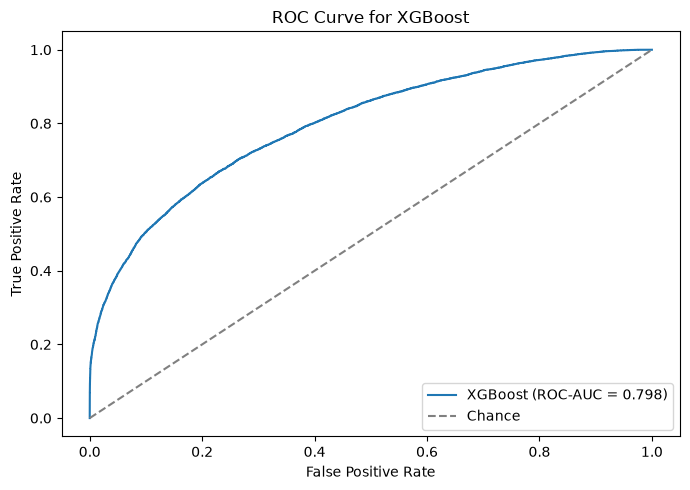

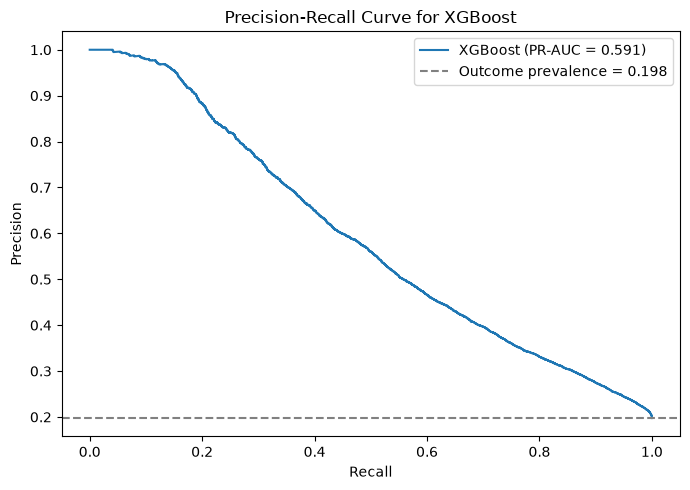

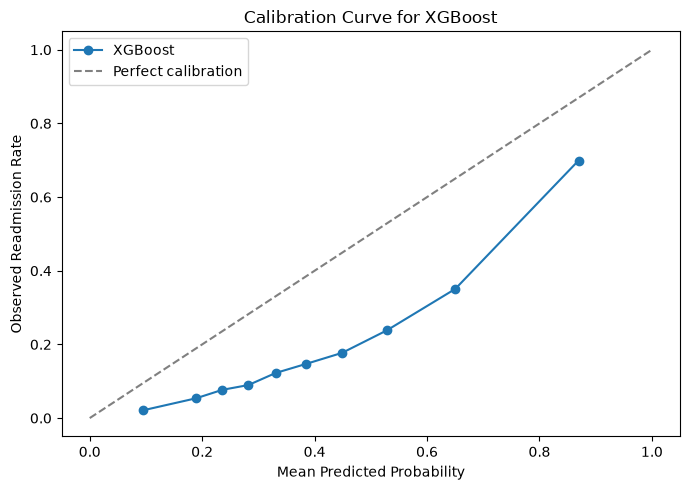

XGBoost performance:
                                               model  \
0                          XGBoost default threshold   
1  XGBoost official balanced precision-recall thr...   
2                  XGBoost training Youden threshold   
3        XGBoost balanced precision-recall threshold   
4          XGBoost exploratory held-out F1 threshold   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.7711             0.7186   
1                   official       0.59    0.8166             0.7049   
2         recall sensitivity       0.47    0.7483             0.7193   
3  balanced precision-recall       0.59    0.8166             0.7049   
4                exploratory       0.59    0.8166             0.7049   

   precision  recall_sensitivity  specificity  f1_score  roc_auc  \
0     0.4443              0.6318       0.8054    0.5217   0.7982   
1     0.5370              0.5202       0.8896    0.5285   0.7982   
2    

In [13]:
#evaluate xgboost and save model outputs if available, only evaluate xgboost if training produced test probabilities
if xgboost_available and xgboost_test_probability is not None:
#select operating thresholds from training predictions
    xgboost_threshold_table, xgboost_best_f1_threshold, xgboost_best_youden_threshold = find_best_threshold(
        y_train, xgboost_train_probability)
    xgboost_balanced_pr_threshold = select_balanced_precision_recall_threshold(xgboost_threshold_table, min_recall=0.10)
    xgboost_threshold_table.to_csv(xgboost_output_path / "t3_4_xgboost_threshold_search_training.csv", index=False)

#prepare reported threshold sensitivity points
    xgboost_test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        xgboost_best_youden_threshold, xgboost_balanced_pr_threshold, xgboost_best_f1_threshold, 0.50]
    xgboost_test_threshold_comparison_df = make_test_threshold_comparison(
        y_test, xgboost_test_probability, xgboost_test_threshold_values)
    xgboost_test_threshold_comparison_df.to_csv(xgboost_output_path / "t3_4_xgboost_test_threshold_comparison.csv", index=False)
    xgboost_heldout_f1_threshold = xgboost_test_threshold_comparison_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]

    xgboost_official_threshold = xgboost_balanced_pr_threshold
    xgboost_official_threshold_name = "training balanced precision-recall threshold"

    xgboost_timing_kwargs = {"training_time_seconds": xgboost_training_time_seconds,
        "train_inference_time_seconds": xgboost_train_inference_time_seconds,
        "test_inference_time_seconds": xgboost_test_inference_time_seconds,
        "number_of_test_admissions": len(y_test)}

#evaluate held-out test performance at each threshold
    xgboost_performance_rows = [add_timing_metrics(evaluate_binary_predictions("XGBoost default threshold", y_test, xgboost_test_probability, 0.50), **xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("XGBoost official balanced precision-recall threshold", y_test, xgboost_test_probability, xgboost_official_threshold), **xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("XGBoost training Youden threshold", y_test, xgboost_test_probability, xgboost_best_youden_threshold), **xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("XGBoost balanced precision-recall threshold", y_test, xgboost_test_probability, xgboost_balanced_pr_threshold), **xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("XGBoost exploratory held-out F1 threshold", y_test, xgboost_test_probability, xgboost_heldout_f1_threshold), **xgboost_timing_kwargs)]

    xgboost_performance_df = pd.DataFrame(xgboost_performance_rows)
    xgboost_performance_df.insert(1, "threshold_role", ["default", "official", "recall sensitivity", "balanced precision-recall", "exploratory"])
    xgboost_performance_df = xgboost_performance_df.round(4)
    xgboost_performance_df.to_csv(xgboost_output_path / "t3_4_xgboost_performance.csv", index=False)

#save probabilities and binary predictions for later notebooks
    xgboost_predictions = save_prediction_file(xgboost_output_path, "t3_4_xgboost_test_predictions.csv",
        test_ids, xgboost_test_probability, xgboost_official_threshold)
    joblib.dump(xgboost_model, xgboost_output_path / "t3_4_xgboost_model.joblib")

#save confusion matrices for threshold comparison
    xgboost_confusion_rows = []
    for threshold_name, threshold, threshold_role in [("XGBoost default threshold", 0.50, "default"),
        ("XGBoost official balanced precision-recall threshold", xgboost_official_threshold, "official"),
        ("XGBoost training Youden threshold", xgboost_best_youden_threshold, "recall sensitivity"),
        ("XGBoost balanced precision-recall threshold", xgboost_balanced_pr_threshold, "balanced precision-recall"),
        ("XGBoost exploratory held-out F1 threshold", xgboost_heldout_f1_threshold, "exploratory")]:
        y_pred = (xgboost_test_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        xgboost_confusion_rows.append({"model": threshold_name, "threshold_role": threshold_role, "threshold": threshold,
            "true_negatives": tn, "false_positives": fp,
            "false_negatives": fn, "true_positives": tp})
    xgboost_confusion_df = pd.DataFrame(xgboost_confusion_rows)
    xgboost_confusion_df.to_csv(xgboost_output_path / "t3_4_xgboost_confusion_matrices.csv", index=False)

#save roc, pr, and calibration plots
    xgboost_calibration_df = plot_model_curves("XGBoost", y_test, xgboost_test_probability,
        xgboost_output_path, "t3_4_xgboost")

    xgboost_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
        "feature_importance": xgboost_model.feature_importances_}).sort_values("feature_importance", ascending=False)
    xgboost_importance_df.to_csv(xgboost_output_path / "t3_4_xgboost_feature_importance.csv", index=False)

    xgboost_workbook = xgboost_output_path / "t3_4_xgboost_tables.xlsx"
    with pd.ExcelWriter(xgboost_workbook) as writer:
        xgboost_performance_df.to_excel(writer, sheet_name="performance", index=False)
        xgboost_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
        xgboost_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
        xgboost_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
        xgboost_screening_df.to_excel(writer, sheet_name="hyperparameter_screen", index=False)
        xgboost_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
        xgboost_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    print("XGBoost performance:")
    print(xgboost_performance_df)
    print("\nTop 30 XGBoost features:")
    print(xgboost_importance_df.head(30))
else:
    print("XGBoost evaluation outputs were skipped because no XGBoost model was trained.")

**CatBoost hyperparameter screening**

CatBoost is trained as an additional gradient boosting comparator. Candidate configurations are ranked by validation PR-AUC, with the train-validation PR-AUC gap retained as an audit field so overfitting can still be reviewed.


In [ ]:
#screen catboost hyperparameters if the library is available
#initialise catboost screening outputs
catboost_screening_df = pd.DataFrame()
catboost_model = None
catboost_train_probability = None
catboost_test_probability = None
best_catboost_config = {"subsample": 0.9, "rsm": 0.6, "learning_rate": 0.045,
    "l2_leaf_reg": 20, "iterations": 850, "depth": 7}

#allow notebook to use a fallback config if screening is disabled
if not run_hyperparameter_screening:
    print("CatBoost screening skipped; using fallback configuration.")
    print(best_catboost_config)
    pd.DataFrame([best_catboost_config]).to_csv(
        catboost_output_path / "t3_4_catboost_fallback_config.csv", index=False)
elif catboost_available:
    #broaden catboost around the deeper regularised settings that have looked promising
    catboost_parameter_space = {"iterations": [350, 500, 700, 850, 1000],
        "depth": [4, 5, 6, 7, 8],
        "learning_rate": [0.025, 0.035, 0.045, 0.05, 0.065],
        "l2_leaf_reg": [6, 10, 20, 30, 45],
        "subsample": [0.75, 0.85, 0.9, 0.95],
        "rsm": [0.6, 0.75, 0.9, 1.0]}

    #force in known useful catboost regions before random sampling
    catboost_anchor_configs = [best_catboost_config.copy(),
        {"subsample": 0.9, "rsm": 1.0, "learning_rate": 0.05,
            "l2_leaf_reg": 6, "iterations": 700, "depth": 6},
        {"subsample": 0.85, "rsm": 0.75, "learning_rate": 0.035,
            "l2_leaf_reg": 30, "iterations": 850, "depth": 7}]

    #sample a larger first-stage set while keeping anchor configs fixed
    sampled_catboost_configs = list(ParameterSampler(catboost_parameter_space, n_iter=75, random_state=42))
    catboost_candidate_configs = []
    seen_catboost_configs = set()
    for config in catboost_anchor_configs + sampled_catboost_configs:
        config_key = tuple(sorted(config.items()))
        if config_key not in seen_catboost_configs:
            catboost_candidate_configs.append(config.copy())
            seen_catboost_configs.add(config_key)

    #sample catboost settings broadly, then use validation pr-auc and the gap rule to select the source config
    catboost_rows = []
    #time the whole screening loop in seconds
    search_start = time.perf_counter()

    #fit and score each sampled candidate
    for config_number, config in enumerate(catboost_candidate_configs, start=1):
        print("Training CatBoost tuning configuration", config_number, "of", len(catboost_candidate_configs))
        print(config)
        config_start = time.perf_counter()
        screening_model = CatBoostClassifier(**config, loss_function="Logloss", eval_metric="PRAUC",
            bootstrap_type="Bernoulli", auto_class_weights="Balanced", random_seed=42,
            verbose=False, allow_writing_files=False, thread_count=-1)

        screening_model.fit(X_screen_train, y_screen_train)
        #use the screening validation split for model selection rather than the final test set
        train_probability = screening_model.predict_proba(X_screen_train)[:, 1]
        val_probability = screening_model.predict_proba(X_screen_val)[:, 1]
        elapsed_seconds = time.perf_counter() - config_start
        catboost_rows.append({"config_number": config_number, **config,
            "training_roc_auc": roc_auc_score(y_screen_train, train_probability),
            "validation_roc_auc": roc_auc_score(y_screen_val, val_probability),
            "training_pr_auc_average_precision": average_precision_score(y_screen_train, train_probability),
            "validation_pr_auc_average_precision": average_precision_score(y_screen_val, val_probability),
            "validation_brier_score": brier_score_loss(y_screen_val, val_probability),
            "elapsed_seconds": elapsed_seconds})
        print("Validation ROC-AUC:", round(catboost_rows[-1]["validation_roc_auc"], 4))
        print("Validation PR-AUC:", round(catboost_rows[-1]["validation_pr_auc_average_precision"], 4))
        print("Elapsed seconds:", round(elapsed_seconds, 2))
        print()

    catboost_screening_df = pd.DataFrame(catboost_rows).sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    #save the full first-stage screen so the selected config can be audited later
    catboost_screening_df.to_csv(catboost_output_path / "t3_4_catboost_hyperparameter_screening.csv", index=False)
    #select the best eligible config after the optional gap rule
    best_catboost_config_number, best_catboost_config, catboost_selection_audit_df = select_best_config_with_pr_auc_gap_filter(
        catboost_screening_df, catboost_candidate_configs, "CatBoost", catboost_output_path,
        "t3_4_catboost_gap_filtered_selection_audit.csv", max_allowed_pr_auc_gap=max_allowed_pr_auc_gap, use_gap_filter=use_pr_auc_gap_filter)

    print("Total CatBoost tuning time in seconds:", round(time.perf_counter() - search_start, 2))
    print()
    print("Top CatBoost tuning results:")
    print(catboost_screening_df.head(10).round(4))
    print()
    print("Best CatBoost configuration:")
    print(best_catboost_config)
else:
    catboost_dependency_df = pd.DataFrame({"check": ["CatBoost available", "CatBoost issue"],
        "value": [catboost_available, str(catboost_import_error)]})
    catboost_dependency_df.to_csv(catboost_output_path / "t3_4_catboost_dependency_check.csv", index=False)
    print("CatBoost was skipped because it could not be imported in this environment.")

Training CatBoost tuning configuration 1 of 78
{'subsample': 0.9, 'rsm': 0.6, 'learning_rate': 0.045, 'l2_leaf_reg': 20, 'iterations': 850, 'depth': 7}
Validation ROC-AUC: 0.7914
Validation PR-AUC: 0.5851
Elapsed seconds: 21.74

Training CatBoost tuning configuration 2 of 78
{'subsample': 0.9, 'rsm': 1.0, 'learning_rate': 0.05, 'l2_leaf_reg': 6, 'iterations': 700, 'depth': 6}
Validation ROC-AUC: 0.7906
Validation PR-AUC: 0.581
Elapsed seconds: 13.92

Training CatBoost tuning configuration 3 of 78
{'subsample': 0.85, 'rsm': 0.75, 'learning_rate': 0.035, 'l2_leaf_reg': 30, 'iterations': 850, 'depth': 7}
Validation ROC-AUC: 0.7933
Validation PR-AUC: 0.5834
Elapsed seconds: 22.79

Training CatBoost tuning configuration 4 of 78
{'subsample': 0.9, 'rsm': 0.75, 'learning_rate': 0.065, 'l2_leaf_reg': 6, 'iterations': 850, 'depth': 7}
Validation ROC-AUC: 0.7873
Validation PR-AUC: 0.5823
Elapsed seconds: 23.35

Training CatBoost tuning configuration 5 of 78
{'subsample': 0.75, 'rsm': 1.0, 'learn

**Train final CatBoost model**

The selected CatBoost configuration is refitted on the full training set. The final fit keeps the selected complexity and weighting choices from screening, then produces probabilities for train/test evaluation.


In [15]:
#fit final catboost model on the full training set if available
if catboost_available:
    catboost_model = CatBoostClassifier(**best_catboost_config,
        loss_function="Logloss", eval_metric="PRAUC", custom_metric=["AUC", "Logloss"],
        auto_class_weights="Balanced", random_seed=42, verbose=100, allow_writing_files=False, thread_count=-1)

    print("Training final CatBoost model on full training data...")
    #time the final model training step
    catboost_training_start = time.perf_counter()
    if training_curve_eval_set_available:
        catboost_model.fit(X_train, y_train, eval_set=catboost_curve_eval_set, use_best_model=False, verbose=100)
    else:
        catboost_model.fit(X_train, y_train)
    catboost_training_time_seconds = time.perf_counter() - catboost_training_start
    store_training_curve_result("CatBoost", catboost_model, best_catboost_config)
    print("CatBoost training complete.")

    #measure training-set inference time and probabilities
    catboost_train_prediction_start = time.perf_counter()
    catboost_train_probability = catboost_model.predict_proba(X_train)[:, 1]
    catboost_train_inference_time_seconds = time.perf_counter() - catboost_train_prediction_start

    #measure held-out test inference time and probabilities
    catboost_test_prediction_start = time.perf_counter()
    catboost_test_probability = catboost_model.predict_proba(X_test)[:, 1]
    catboost_test_inference_time_seconds = time.perf_counter() - catboost_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, catboost_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, catboost_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, catboost_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, catboost_test_probability), 4))
    print("Training time in seconds:", round(catboost_training_time_seconds, 2))
else:
    print("Final CatBoost model was skipped because CatBoost is unavailable.")

Training final CatBoost model on full training data...
0:	learn: 0.7588355	test: 0.7583346	best: 0.7583346 (0)	total: 52.7ms	remaining: 52.6s
100:	learn: 0.8091465	test: 0.8109314	best: 0.8109314 (100)	total: 5.64s	remaining: 50.2s
200:	learn: 0.8175677	test: 0.8192391	best: 0.8192391 (200)	total: 11.2s	remaining: 44.6s
300:	learn: 0.8255894	test: 0.8272576	best: 0.8272576 (300)	total: 16.7s	remaining: 38.9s
400:	learn: 0.8331565	test: 0.8342506	best: 0.8342506 (400)	total: 22.1s	remaining: 33.1s
500:	learn: 0.8398645	test: 0.8407826	best: 0.8407826 (500)	total: 27.7s	remaining: 27.6s
600:	learn: 0.8460856	test: 0.8469562	best: 0.8469562 (600)	total: 33s	remaining: 21.9s
700:	learn: 0.8521420	test: 0.8528026	best: 0.8528026 (700)	total: 38.4s	remaining: 16.4s
800:	learn: 0.8576990	test: 0.8581960	best: 0.8581960 (800)	total: 43.7s	remaining: 10.9s
900:	learn: 0.8629846	test: 0.8632980	best: 0.8632980 (900)	total: 49.1s	remaining: 5.39s
999:	learn: 0.8677506	test: 0.8679408	best: 0.8679

**Evaluate and save CatBoost outputs**

This section saves CatBoost metrics, threshold comparisons, predictions, curves, feature importance, and model files using the same output pattern as the XGBoost section.


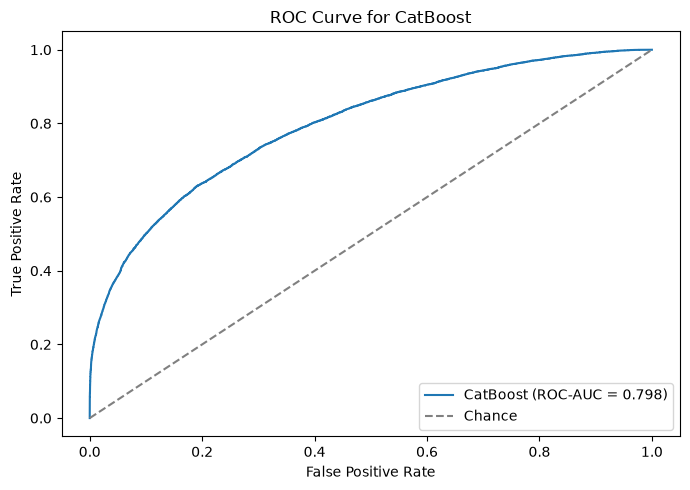

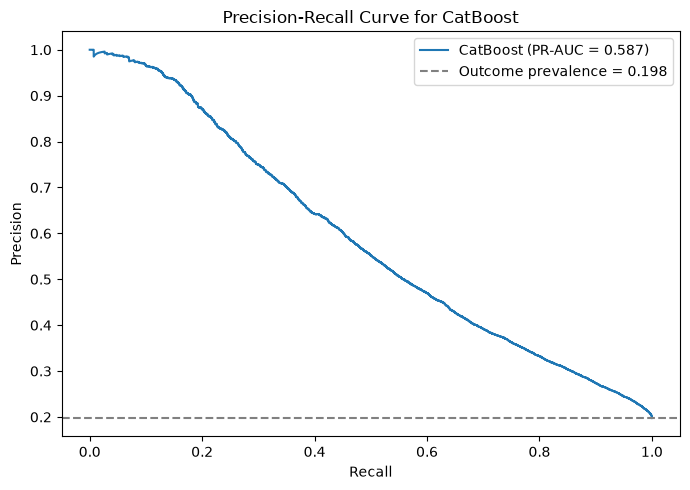

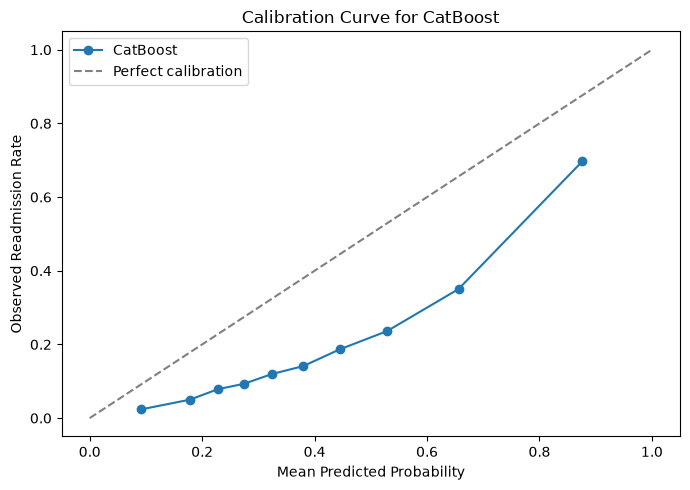

CatBoost performance:
                                               model  \
0                         CatBoost default threshold   
1  CatBoost official balanced precision-recall th...   
2                 CatBoost training Youden threshold   
3       CatBoost balanced precision-recall threshold   
4         CatBoost exploratory held-out F1 threshold   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.7724             0.7193   
1                   official       0.60    0.8181             0.7020   
2         recall sensitivity       0.47    0.7498             0.7178   
3  balanced precision-recall       0.60    0.8181             0.7020   
4                exploratory       0.56    0.8034             0.7095   

   precision  recall_sensitivity  specificity  f1_score  roc_auc  \
0     0.4462              0.6315       0.8071    0.5229   0.7977   
1     0.5421              0.5100       0.8939    0.5256   0.7977   
2   

In [16]:
#evaluate catboost and save model outputs if available, only evaluate catboost if training produced test probabilities
if catboost_available and catboost_test_probability is not None:
#select operating thresholds from training predictions
    catboost_threshold_table, catboost_best_f1_threshold, catboost_best_youden_threshold = find_best_threshold(
        y_train, catboost_train_probability)
    catboost_balanced_pr_threshold = select_balanced_precision_recall_threshold(catboost_threshold_table, min_recall=0.10)
    catboost_threshold_table.to_csv(catboost_output_path / "t3_4_catboost_threshold_search_training.csv", index=False)
#prepare reported threshold sensitivity points
    catboost_test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        catboost_best_youden_threshold, catboost_balanced_pr_threshold, catboost_best_f1_threshold, 0.50]
    catboost_test_threshold_comparison_df = make_test_threshold_comparison(
        y_test, catboost_test_probability, catboost_test_threshold_values)
    catboost_test_threshold_comparison_df.to_csv(catboost_output_path / "t3_4_catboost_test_threshold_comparison.csv", index=False)
    catboost_heldout_f1_threshold = catboost_test_threshold_comparison_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]

    catboost_official_threshold = catboost_balanced_pr_threshold
    catboost_official_threshold_name = "training balanced precision-recall threshold"

    catboost_timing_kwargs = {"training_time_seconds": catboost_training_time_seconds,
        "train_inference_time_seconds": catboost_train_inference_time_seconds,
        "test_inference_time_seconds": catboost_test_inference_time_seconds,
        "number_of_test_admissions": len(y_test)}

#evaluate held-out test performance at each threshold
    catboost_performance_rows = [
        add_timing_metrics(evaluate_binary_predictions("CatBoost default threshold", y_test, catboost_test_probability, 0.50), **catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("CatBoost official balanced precision-recall threshold", y_test, catboost_test_probability, catboost_official_threshold), **catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("CatBoost training Youden threshold", y_test, catboost_test_probability, catboost_best_youden_threshold), **catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("CatBoost balanced precision-recall threshold", y_test, catboost_test_probability, catboost_balanced_pr_threshold), **catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("CatBoost exploratory held-out F1 threshold", y_test, catboost_test_probability, catboost_heldout_f1_threshold), **catboost_timing_kwargs)]
    catboost_performance_df = pd.DataFrame(catboost_performance_rows)
    catboost_performance_df.insert(1, "threshold_role", ["default", "official", "recall sensitivity", "balanced precision-recall", "exploratory"])
    catboost_performance_df = catboost_performance_df.round(4)
    catboost_performance_df.to_csv(catboost_output_path / "t3_4_catboost_performance.csv", index=False)

#save probabilities and binary predictions for later notebooks
    catboost_predictions = save_prediction_file(catboost_output_path, "t3_4_catboost_test_predictions.csv",
        test_ids, catboost_test_probability, catboost_official_threshold)
    catboost_model.save_model(str(catboost_output_path / "t3_4_catboost_model.cbm"))
    joblib.dump(catboost_model, catboost_output_path / "t3_4_catboost_model.joblib")

#save confusion matrices for threshold comparison
    catboost_confusion_rows = []
    for threshold_name, threshold, threshold_role in [("CatBoost default threshold", 0.50, "default"),
        ("CatBoost official balanced precision-recall threshold", catboost_official_threshold, "official"),
        ("CatBoost training Youden threshold", catboost_best_youden_threshold, "recall sensitivity"),
        ("CatBoost balanced precision-recall threshold", catboost_balanced_pr_threshold, "balanced precision-recall"),
        ("CatBoost exploratory held-out F1 threshold", catboost_heldout_f1_threshold, "exploratory")]:
        y_pred = (catboost_test_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        catboost_confusion_rows.append({"model": threshold_name, "threshold_role": threshold_role, "threshold": threshold,
            "true_negatives": tn, "false_positives": fp,
            "false_negatives": fn, "true_positives": tp})
    catboost_confusion_df = pd.DataFrame(catboost_confusion_rows)
    catboost_confusion_df.to_csv(catboost_output_path / "t3_4_catboost_confusion_matrices.csv", index=False)

#save roc, pr, and calibration plots
    catboost_calibration_df = plot_model_curves("CatBoost", y_test, catboost_test_probability,
        catboost_output_path, "t3_4_catboost")

    catboost_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
        "feature_importance": catboost_model.get_feature_importance()}).sort_values("feature_importance", ascending=False)
    catboost_importance_df.to_csv(catboost_output_path / "t3_4_catboost_feature_importance.csv", index=False)

    catboost_workbook = catboost_output_path / "t3_4_catboost_tables.xlsx"
    with pd.ExcelWriter(catboost_workbook) as writer:
        catboost_performance_df.to_excel(writer, sheet_name="performance", index=False)
        catboost_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
        catboost_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
        catboost_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
        #catboost_screening_df.to_excel(writer, sheet_name="hyperparameter_screen", index=false)
        catboost_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
        catboost_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    print("CatBoost performance:")
    print(catboost_performance_df)
    print("\nTop 30 CatBoost features:")
    print(catboost_importance_df.head(30))
else:
    print("CatBoost evaluation outputs were skipped because no CatBoost model was trained.")

**LightGBM hyperparameter screening**

LightGBM is added as a fast gradient boosting comparator. Candidate configurations are ranked by validation PR-AUC, with an optional train-validation PR-AUC gap guard available for sensitivity runs.


In [ ]:
#screen lightgbm hyperparameters if the library is available
#initialise lightgbm screening outputs
lightgbm_screening_df = pd.DataFrame()
lightgbm_model = None
lightgbm_train_probability = None
lightgbm_test_probability = None
best_lightgbm_config = {"subsample": 0.95, "reg_lambda": 35, "reg_alpha": 1,
    "num_leaves": 127, "n_estimators": 500, "min_child_samples": 75,
    "max_depth": -1, "learning_rate": 0.025, "colsample_bytree": 0.6}

#allow the notebook to use a fallback config if screening is disabled
if not run_hyperparameter_screening:
    print("LightGBM screening skipped; using fallback configuration.")
    print(best_lightgbm_config)
    pd.DataFrame([best_lightgbm_config]).to_csv(
        lightgbm_output_path / "t3_4_lightgbm_fallback_config.csv", index=False)
elif lightgbm_available:
    #broaden lightgbm to include higher-leaf and stronger-regularisation regions
    lightgbm_parameter_space = {"n_estimators": [300, 360, 500, 700, 850],
        "learning_rate": [0.02, 0.025, 0.03, 0.04, 0.05],
        "max_depth": [5, 6, 8, 10, -1],
        "num_leaves": [31, 63, 95, 127, 159],
        "min_child_samples": [50, 75, 100, 125],
        "subsample": [0.75, 0.85, 0.95],
        "colsample_bytree": [0.60, 0.75, 0.90],
        "reg_alpha": [0.25, 0.5, 1, 1.5],
        "reg_lambda": [10, 20, 35, 45, 60]}

    #force in known useful lightgbm regions before random sampling
    lightgbm_anchor_configs = [best_lightgbm_config.copy(),
        {"subsample": 0.75, "reg_lambda": 45, "reg_alpha": 0.5,
            "num_leaves": 127, "n_estimators": 360, "min_child_samples": 75,
            "max_depth": -1, "learning_rate": 0.03, "colsample_bytree": 0.75},
        {"subsample": 0.85, "reg_lambda": 35, "reg_alpha": 0.25,
            "num_leaves": 127, "n_estimators": 500, "min_child_samples": 100,
            "max_depth": -1, "learning_rate": 0.025, "colsample_bytree": 0.6}]

    #sample more first-stage candidates because the search space is deliberately wider
    sampled_lightgbm_configs = list(ParameterSampler(lightgbm_parameter_space, n_iter=75, random_state=42))
    lightgbm_candidate_configs = []
    seen_lightgbm_configs = set()
    for config in lightgbm_anchor_configs + sampled_lightgbm_configs:
        config_key = tuple(sorted(config.items()))
        if config_key not in seen_lightgbm_configs:
            lightgbm_candidate_configs.append(config.copy())
            seen_lightgbm_configs.add(config_key)

    #screen lightgbm broadly because tree complexity and regularisation interact strongly
    lightgbm_rows = []
    #time the whole screening loop in seconds
    search_start = time.perf_counter()

    #fit and score each sampled candidate
    for config_number, config in enumerate(lightgbm_candidate_configs, start=1):
        print("Training LightGBM tuning configuration", config_number, "of", len(lightgbm_candidate_configs))
        print(config)
        config_start = time.perf_counter()
        screening_model = LGBMClassifier(**config, objective="binary",
            class_weight={0: 1.0, 1: scale_pos_weight}, random_state=42,
            n_jobs=-1, verbosity=-1, force_col_wise=True)
        screening_model.fit(X_screen_train, y_screen_train)
        #validation scores here guide config choice; final held-out scores are reported later
        train_probability = screening_model.predict_proba(X_screen_train)[:, 1]
        val_probability = screening_model.predict_proba(X_screen_val)[:, 1]
        elapsed_seconds = time.perf_counter() - config_start
        lightgbm_rows.append({"config_number": config_number, **config,
            "training_roc_auc": roc_auc_score(y_screen_train, train_probability),
            "validation_roc_auc": roc_auc_score(y_screen_val, val_probability),
            "training_pr_auc_average_precision": average_precision_score(y_screen_train, train_probability),
            "validation_pr_auc_average_precision": average_precision_score(y_screen_val, val_probability),
            "validation_brier_score": brier_score_loss(y_screen_val, val_probability),
            "elapsed_seconds": elapsed_seconds})
        print("Validation ROC-AUC:", round(lightgbm_rows[-1]["validation_roc_auc"], 4))
        print("Validation PR-AUC:", round(lightgbm_rows[-1]["validation_pr_auc_average_precision"], 4))
        print("Elapsed seconds:", round(elapsed_seconds, 2))
        print()

    lightgbm_screening_df = pd.DataFrame(lightgbm_rows).sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    #save the full first-stage screen so the selected config can be audited later
    lightgbm_screening_df.to_csv(lightgbm_output_path / "t3_4_lightgbm_hyperparameter_screening.csv", index=False)
    #select the best eligible config after the optional gap rule
    best_lightgbm_config_number, best_lightgbm_config, lightgbm_selection_audit_df = select_best_config_with_pr_auc_gap_filter(
        lightgbm_screening_df, lightgbm_candidate_configs, "LightGBM", lightgbm_output_path,
        "t3_4_lightgbm_gap_filtered_selection_audit.csv", max_allowed_pr_auc_gap=max_allowed_pr_auc_gap, use_gap_filter=use_pr_auc_gap_filter)

    print("Total LightGBM tuning time in seconds:", round(time.perf_counter() - search_start, 2))
    print()
    print("Top LightGBM tuning results:")
    print(lightgbm_screening_df.head(10).round(4))
    print()
    print("Best LightGBM configuration:")
    print(best_lightgbm_config)
else:
    print("LightGBM tuning was skipped because LightGBM is unavailable.")

Training LightGBM tuning configuration 1 of 78
{'subsample': 0.95, 'reg_lambda': 35, 'reg_alpha': 1, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 75, 'max_depth': -1, 'learning_rate': 0.025, 'colsample_bytree': 0.6}
Validation ROC-AUC: 0.7924
Validation PR-AUC: 0.5919
Elapsed seconds: 21.92

Training LightGBM tuning configuration 2 of 78
{'subsample': 0.75, 'reg_lambda': 45, 'reg_alpha': 0.5, 'num_leaves': 127, 'n_estimators': 360, 'min_child_samples': 75, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 0.75}
Validation ROC-AUC: 0.7934
Validation PR-AUC: 0.5917
Elapsed seconds: 17.18

Training LightGBM tuning configuration 3 of 78
{'subsample': 0.85, 'reg_lambda': 35, 'reg_alpha': 0.25, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 100, 'max_depth': -1, 'learning_rate': 0.025, 'colsample_bytree': 0.6}
Validation ROC-AUC: 0.7925
Validation PR-AUC: 0.5913
Elapsed seconds: 21.1

Training LightGBM tuning configuration 4 of 78
{'subsample': 0.95, '

**Train final LightGBM model**

The selected LightGBM configuration is refitted on the full training set. Learning-curve information is recorded where available for the later diagnostic plots.


In [18]:
#train the final lightgbm model on the full training set
if lightgbm_available:
    #copy the selected lightgbm config for the final full-training fit
    final_lightgbm_config = best_lightgbm_config.copy()
    lightgbm_model = LGBMClassifier(**final_lightgbm_config, objective="binary",
        class_weight={0: 1.0, 1: scale_pos_weight}, random_state=42,
        n_jobs=-1, verbosity=-1, force_col_wise=True)

    print("Training final LightGBM model on full training data...")
    #time the final model training step
    lightgbm_training_start = time.perf_counter()
    if training_curve_eval_set_available:
        lightgbm_model.fit(X_train, y_train, eval_set=lightgbm_curve_eval_set,
            eval_metric=["binary_logloss", "auc", "average_precision"],
            callbacks=[log_evaluation(period=0)])
    else:
        lightgbm_model.fit(X_train, y_train)
    lightgbm_training_time_seconds = time.perf_counter() - lightgbm_training_start
    store_training_curve_result("LightGBM", lightgbm_model, final_lightgbm_config)
    print("LightGBM training complete.")

    #measure training-set inference time and probabilities
    lightgbm_train_prediction_start = time.perf_counter()
    lightgbm_train_probability = lightgbm_model.predict_proba(X_train)[:, 1]
    lightgbm_train_inference_time_seconds = time.perf_counter() - lightgbm_train_prediction_start

    #measure held-out test inference time and probabilities
    lightgbm_test_prediction_start = time.perf_counter()
    lightgbm_test_probability = lightgbm_model.predict_proba(X_test)[:, 1]
    lightgbm_test_inference_time_seconds = time.perf_counter() - lightgbm_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, lightgbm_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, lightgbm_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, lightgbm_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, lightgbm_test_probability), 4))
    print("Training time in seconds:", round(lightgbm_training_time_seconds, 2))
else:
    print("Final LightGBM model was skipped.")

Training final LightGBM model on full training data...
LightGBM training complete.
Training ROC-AUC: 0.9044
Test ROC-AUC: 0.7997
Training PR-AUC: 0.724
Test PR-AUC: 0.592
Training time in seconds: 54.99


**Evaluate and save LightGBM outputs**

This section saves LightGBM metrics, threshold comparisons, predictions, curves, feature importance, and model files using the same structure as the other gradient boosting models.


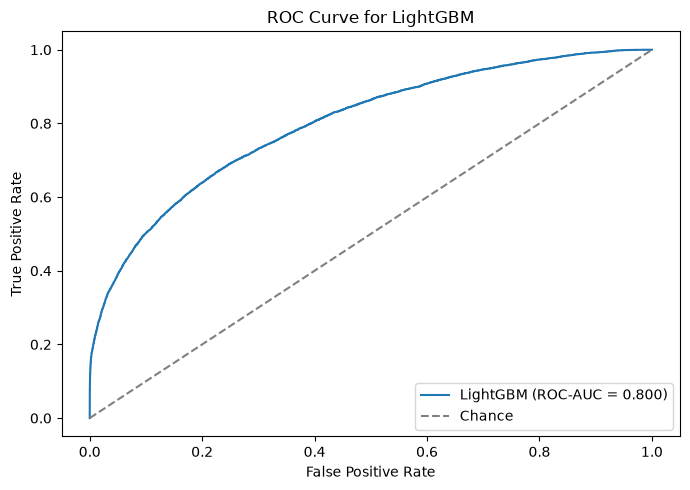

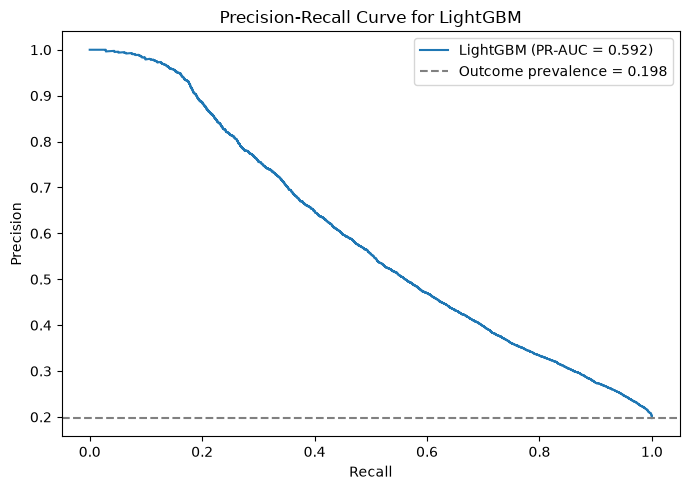

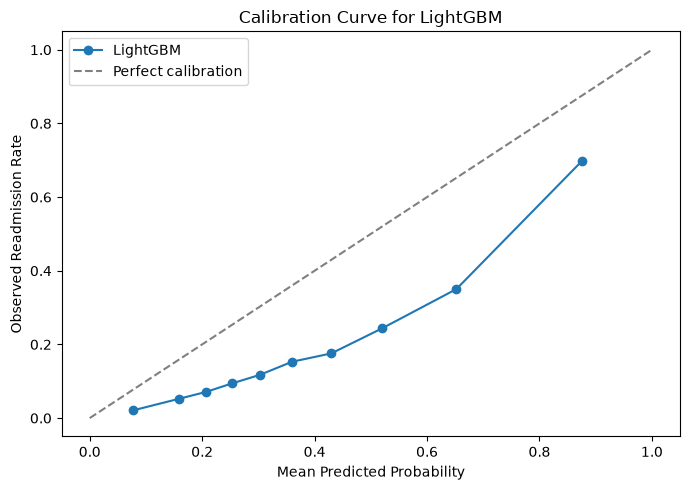

LightGBM performance:
                                               model  \
0                         LightGBM default threshold   
1  LightGBM official balanced precision-recall th...   
2                 LightGBM training Youden threshold   
3       LightGBM balanced precision-recall threshold   
4         LightGBM exploratory held-out F1 threshold   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.7784             0.7185   
1                   official       0.60    0.8204             0.7017   
2         recall sensitivity       0.45    0.7466             0.7207   
3  balanced precision-recall       0.60    0.8204             0.7017   
4                exploratory       0.55    0.8025             0.7113   

   precision  recall_sensitivity  specificity  f1_score  roc_auc  \
0     0.4552              0.6196       0.8174    0.5248   0.7997   
1     0.5495              0.5054       0.8980    0.5266   0.7997   
2   

In [19]:
#evaluate lightgbm and save model outputs if available, only evaluate lightgbm if training produced test probabilities
if lightgbm_available and lightgbm_test_probability is not None:
#select operating thresholds from training predictions
    lightgbm_threshold_table, lightgbm_best_f1_threshold, lightgbm_best_youden_threshold = find_best_threshold(
        y_train, lightgbm_train_probability)
    lightgbm_balanced_pr_threshold = select_balanced_precision_recall_threshold(lightgbm_threshold_table, min_recall=0.10)
    lightgbm_threshold_table.to_csv(lightgbm_output_path / "t3_4_lightgbm_threshold_search_training.csv", index=False)

#prepare reported threshold sensitivity points
    lightgbm_test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        lightgbm_best_youden_threshold, lightgbm_balanced_pr_threshold, lightgbm_best_f1_threshold, 0.50, 0.55, 0.60]
    lightgbm_test_threshold_comparison_df = make_test_threshold_comparison(
        y_test, lightgbm_test_probability, lightgbm_test_threshold_values)
    lightgbm_test_threshold_comparison_df.to_csv(
        lightgbm_output_path / "t3_4_lightgbm_test_threshold_comparison.csv", index=False)
    lightgbm_heldout_f1_threshold = lightgbm_test_threshold_comparison_df.sort_values(
        "f1_score", ascending=False).iloc[0]["threshold"]

    lightgbm_official_threshold = lightgbm_balanced_pr_threshold
    lightgbm_official_threshold_name = "training balanced precision-recall threshold"

    lightgbm_timing_kwargs = {"training_time_seconds": lightgbm_training_time_seconds,
        "train_inference_time_seconds": lightgbm_train_inference_time_seconds,
        "test_inference_time_seconds": lightgbm_test_inference_time_seconds,
        "number_of_test_admissions": len(y_test)}

#evaluate held-out test performance at each threshold
    lightgbm_performance_rows = [
        add_timing_metrics(evaluate_binary_predictions("LightGBM default threshold", y_test, lightgbm_test_probability, 0.50), **lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("LightGBM official balanced precision-recall threshold", y_test, lightgbm_test_probability, lightgbm_official_threshold), **lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("LightGBM training Youden threshold", y_test, lightgbm_test_probability, lightgbm_best_youden_threshold), **lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("LightGBM balanced precision-recall threshold", y_test, lightgbm_test_probability, lightgbm_balanced_pr_threshold), **lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("LightGBM exploratory held-out F1 threshold", y_test, lightgbm_test_probability, lightgbm_heldout_f1_threshold), **lightgbm_timing_kwargs)]
    lightgbm_performance_df = pd.DataFrame(lightgbm_performance_rows)
    lightgbm_performance_df.insert(1, "threshold_role", ["default", "official", "recall sensitivity", "balanced precision-recall", "exploratory"])
    lightgbm_performance_df = lightgbm_performance_df.round(4)
    lightgbm_performance_df.to_csv(lightgbm_output_path / "t3_4_lightgbm_performance.csv", index=False)

#save probabilities and binary predictions for later notebooks
    lightgbm_predictions = save_prediction_file(lightgbm_output_path, "t3_4_lightgbm_test_predictions.csv",
        test_ids, lightgbm_test_probability, lightgbm_official_threshold)
    joblib.dump(lightgbm_model, lightgbm_output_path / "t3_4_lightgbm_model.joblib")

#save confusion matrices for threshold comparison
    lightgbm_confusion_rows = []
    for threshold_name, threshold, threshold_role in [("LightGBM default threshold", 0.50, "default"),
        ("LightGBM official balanced precision-recall threshold", lightgbm_official_threshold, "official"),
        ("LightGBM training Youden threshold", lightgbm_best_youden_threshold, "recall sensitivity"),
        ("LightGBM balanced precision-recall threshold", lightgbm_balanced_pr_threshold, "balanced precision-recall"),
        ("LightGBM exploratory held-out F1 threshold", lightgbm_heldout_f1_threshold, "exploratory")]:
        y_pred = (lightgbm_test_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        lightgbm_confusion_rows.append({"model": threshold_name, "threshold_role": threshold_role, "threshold": threshold,
            "true_negatives": tn, "false_positives": fp,
            "false_negatives": fn, "true_positives": tp})
    lightgbm_confusion_df = pd.DataFrame(lightgbm_confusion_rows)
    lightgbm_confusion_df.to_csv(lightgbm_output_path / "t3_4_lightgbm_confusion_matrices.csv", index=False)

#save roc, pr, and calibration plots
    lightgbm_calibration_df = plot_model_curves("LightGBM", y_test, lightgbm_test_probability,
        lightgbm_output_path, "t3_4_lightgbm")

    lightgbm_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
        "feature_importance": lightgbm_model.feature_importances_}).sort_values("feature_importance", ascending=False)
    lightgbm_importance_df.to_csv(lightgbm_output_path / "t3_4_lightgbm_feature_importance.csv", index=False)

    with pd.ExcelWriter(lightgbm_output_path / "t3_4_lightgbm_tables.xlsx") as writer:
        lightgbm_performance_df.to_excel(writer, sheet_name="performance", index=False)
        lightgbm_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
        lightgbm_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
        lightgbm_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
        lightgbm_screening_df.to_excel(writer, sheet_name="hyperparameter_screen", index=False)
        lightgbm_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
        lightgbm_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    print("LightGBM performance:")
    print(lightgbm_performance_df)
    print("\nTop 30 LightGBM features:")
    print(lightgbm_importance_df.head(30))
else:
    print("LightGBM evaluation outputs were skipped because no LightGBM model was trained.")

**Create targeted gradient boosting output folders**

The first-pass XGBoost, CatBoost, and LightGBM results are retained. The following targeted sections build smaller parameter spaces around the selected first-pass configurations, then vary class-weight strength and regularisation more deliberately.


In [20]:
#create separate folders for targeted gradient boosting sensitivity experiments
xgboost_targeted_output_path = wp3_4_output_path / "xgboost_targeted"
catboost_targeted_output_path = wp3_4_output_path / "catboost_targeted"
lightgbm_targeted_output_path = wp3_4_output_path / "lightgbm_targeted"
xgboost_targeted_output_path.mkdir(parents=True, exist_ok=True)
catboost_targeted_output_path.mkdir(parents=True, exist_ok=True)
lightgbm_targeted_output_path.mkdir(parents=True, exist_ok=True)

print("Targeted XGBoost output folder:")
print(xgboost_targeted_output_path)
print("Targeted CatBoost output folder:")
print(catboost_targeted_output_path)
print("Targeted LightGBM output folder:")
print(lightgbm_targeted_output_path)

Targeted XGBoost output folder:
/scratch/DissProject/outputs/WP3_4/xgboost_targeted
Targeted CatBoost output folder:
/scratch/DissProject/outputs/WP3_4/catboost_targeted
Targeted LightGBM output folder:
/scratch/DissProject/outputs/WP3_4/lightgbm_targeted


In [21]:
#generate targeted hyperparameter spaces from the best first-stage screening config
#this keeps the second-stage search reproducible and avoids hand-editing targeted ranges after each run.
#clean generated parameter values
def unique_sorted_values(values):
    cleaned_values = []
    for value in values:
        if value is None:
            continue
        if isinstance(value, float) and np.isnan(value):
            continue
        cleaned_values.append(value)
    return sorted(set(cleaned_values))

#keep generated values within safe model bounds
def clip_numeric_values(values, lower_bound, upper_bound):
    return [value for value in values if lower_bound <= value <= upper_bound]

#create nearby candidate values around the first-stage winner
def numeric_neighbourhood(value, offsets=None, multipliers=None, lower_bound=None, upper_bound=None, value_type="float", decimals=5):
    values = [value]
    if offsets is not None:
        values.extend([value + offset for offset in offsets])
    if multipliers is not None:
        values.extend([value * multiplier for multiplier in multipliers])
    if value_type == "int":
        values = [int(round(value)) for value in values]
    else:
        values = [round(float(value), decimals) for value in values]
    if lower_bound is not None and upper_bound is not None:
        values = clip_numeric_values(values, lower_bound, upper_bound)
    return unique_sorted_values(values)

#build targeted xgboost ranges from the selected base config
def make_xgboost_targeted_parameter_space(best_config):
    #search a compact neighbourhood around the best first-stage xgboost settings, then vary class weight separately.
    return {
        "n_estimators": numeric_neighbourhood(best_config.get("n_estimators", 700), offsets=[-150, -75, 0, 75, 150], lower_bound=200, upper_bound=1200, value_type="int"),
        "learning_rate": numeric_neighbourhood(best_config.get("learning_rate", 0.05), multipliers=[0.65, 0.8, 1.0, 1.2], lower_bound=0.015, upper_bound=0.12),
        "max_depth": numeric_neighbourhood(best_config.get("max_depth", 5), offsets=[-1, 0, 1], lower_bound=2, upper_bound=8, value_type="int"),
        "min_child_weight": numeric_neighbourhood(best_config.get("min_child_weight", 5), offsets=[-4, 0, 5, 10], lower_bound=1, upper_bound=35, value_type="int"),
        "subsample": numeric_neighbourhood(best_config.get("subsample", 0.8), offsets=[-0.1, 0, 0.05], lower_bound=0.6, upper_bound=1.0),
        "colsample_bytree": numeric_neighbourhood(best_config.get("colsample_bytree", 0.7), offsets=[-0.1, 0, 0.1], lower_bound=0.45, upper_bound=1.0),
        "reg_alpha": numeric_neighbourhood(best_config.get("reg_alpha", 1.0), offsets=[-0.5, 0, 0.5, 1.0], lower_bound=0, upper_bound=10),
        "reg_lambda": numeric_neighbourhood(best_config.get("reg_lambda", 10.0), multipliers=[0.75, 1.0, 1.5, 2.5], lower_bound=0, upper_bound=100),
        "gamma": numeric_neighbourhood(best_config.get("gamma", 0.0), offsets=[0, 0.05, 0.1, 0.2], lower_bound=0, upper_bound=2),
        "scale_pos_weight_multiplier": [0.3, 0.35, 0.4, 0.45, 0.5]}

#build targeted catboost ranges from the selected base config
def make_catboost_targeted_parameter_space(best_config):
    #catboost uses class weights rather than scale_pos_weight, so the targeted space includes a class-weight multiplier.
    return {
        "iterations": numeric_neighbourhood(best_config.get("iterations", 700), offsets=[-150, -75, 0, 75, 150], lower_bound=250, upper_bound=1200, value_type="int"),
        "learning_rate": numeric_neighbourhood(best_config.get("learning_rate", 0.05), multipliers=[0.75, 0.9, 1.0, 1.15], lower_bound=0.015, upper_bound=0.10),
        "depth": numeric_neighbourhood(best_config.get("depth", 6), offsets=[-1, 0, 1], lower_bound=3, upper_bound=8, value_type="int"),
        "l2_leaf_reg": numeric_neighbourhood(best_config.get("l2_leaf_reg", 10.0), multipliers=[0.75, 1.0, 1.5, 2.0], lower_bound=1, upper_bound=60),
        "subsample": numeric_neighbourhood(best_config.get("subsample", 0.9), offsets=[-0.1, 0, 0.05], lower_bound=0.6, upper_bound=1.0),
        "rsm": numeric_neighbourhood(best_config.get("rsm", 0.8), offsets=[-0.1, 0, 0.1], lower_bound=0.45, upper_bound=1.0),
        "class_weight_multiplier": [0.3, 0.35, 0.4, 0.45, 0.5]}

#build targeted lightgbm ranges from the selected base config
def make_lightgbm_targeted_parameter_space(best_config):
    #lightgbm benefits from checking nearby tree count, leaves, regularisation, and class-weight strengths.
    best_max_depth = best_config.get("max_depth", -1)
    if best_max_depth == -1:
        max_depth_values = [-1, 6, 8, 10]
    else:
        max_depth_values = numeric_neighbourhood(best_max_depth, offsets=[-2, 0, 2], lower_bound=3, upper_bound=12, value_type="int") + [-1]
    return {
        "n_estimators": numeric_neighbourhood(best_config.get("n_estimators", 500), offsets=[-150, -75, 0, 75, 150], lower_bound=200, upper_bound=1200, value_type="int"),
        "learning_rate": numeric_neighbourhood(best_config.get("learning_rate", 0.035), multipliers=[0.7, 0.85, 1.0, 1.2], lower_bound=0.01, upper_bound=0.10),
        "num_leaves": numeric_neighbourhood(best_config.get("num_leaves", 63), offsets=[-32, 0, 32, 64], lower_bound=15, upper_bound=255, value_type="int"),
        "min_child_samples": numeric_neighbourhood(best_config.get("min_child_samples", 75), offsets=[-25, 0, 25, 50], lower_bound=10, upper_bound=200, value_type="int"),
        "max_depth": unique_sorted_values(max_depth_values),
        "subsample": numeric_neighbourhood(best_config.get("subsample", 0.85), offsets=[-0.1, 0, 0.1], lower_bound=0.6, upper_bound=1.0),
        "colsample_bytree": numeric_neighbourhood(best_config.get("colsample_bytree", 0.7), offsets=[-0.1, 0, 0.1], lower_bound=0.45, upper_bound=1.0),
        "reg_alpha": numeric_neighbourhood(best_config.get("reg_alpha", 0.5), offsets=[-0.5, 0, 0.5, 1.0], lower_bound=0, upper_bound=10),
        "reg_lambda": numeric_neighbourhood(best_config.get("reg_lambda", 20.0), multipliers=[0.75, 1.0, 1.5, 2.0], lower_bound=0, upper_bound=120),
        "scale_pos_weight_multiplier": [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]}

#save generated targeted ranges for auditability
def save_parameter_space(parameter_space, output_folder, file_name):
    #save each generated option list so the targeted search can be audited after the notebook finishes.
    rows = [{"hyperparameter": key, "candidate_values": str(value)} for key, value in parameter_space.items()]
    pd.DataFrame(rows).to_csv(output_folder / file_name, index=False)

**Targeted XGBoost sensitivity screening**

This focused second-pass sweep searches around the strongest XGBoost results while explicitly varying tree depth, number of estimators, learning rate, class-weight strength, and regularisation. Early stopping is retained so larger estimator values can be tested without forcing every model to use all boosting rounds.




In [22]:
#run targeted xgboost tuning around the best initial configuration if xgboost is available
xgboost_targeted_screening_df = pd.DataFrame()
targeted_xgboost_model = None
targeted_xgboost_train_probability = None
targeted_xgboost_test_probability = None
best_targeted_xgboost_config = {}

#skip targeted screening if the first-stage search is disabled
if not run_hyperparameter_screening:
    print("Targeted XGBoost screening skipped because run_hyperparameter_screening is False.")
elif xgboost_available:
    #build the targeted search space from the best first-stage xgboost configuration.
    xgboost_targeted_parameter_space = make_xgboost_targeted_parameter_space(best_xgboost_config)
    save_parameter_space(xgboost_targeted_parameter_space, xgboost_targeted_output_path,
        "t3_4_xgboost_targeted_generated_parameter_space.csv")
    print("Best first-stage XGBoost configuration used to generate targeted space:")
    print(best_xgboost_config)
    print("Generated targeted XGBoost parameter space:")
    print(xgboost_targeted_parameter_space)

    xgboost_targeted_candidate_configs = list(ParameterSampler(xgboost_targeted_parameter_space, n_iter=24, random_state=84))
    #targeted screening checks nearby configs plus softer positive-class weights.
    xgboost_targeted_rows = []
#time the targeted screening loop in seconds
    search_start = time.perf_counter()

#fit each nearby targeted candidate
    for config_number, config in enumerate(xgboost_targeted_candidate_configs, start=1):
        #separate the class-weight multiplier from model hyperparameters
        config = config.copy()
        class_weight_multiplier = config.pop("scale_pos_weight_multiplier")
        adjusted_scale_pos_weight = scale_pos_weight * class_weight_multiplier

        print("Training targeted XGBoost configuration", config_number, "of", len(xgboost_targeted_candidate_configs))
        print({**config, "scale_pos_weight_multiplier": class_weight_multiplier})
        config_start = time.perf_counter()

        screening_model = XGBClassifier(**config, objective="binary:logistic", eval_metric="aucpr",
            scale_pos_weight=adjusted_scale_pos_weight, early_stopping_rounds=50, random_state=42,
            n_jobs=-1, tree_method="hist")
        screening_model.fit(X_screen_train, y_screen_train,
        #early stopping finds the useful tree count inside each targeted candidate.
            eval_set=[(X_screen_val, y_screen_val)], verbose=False)

#score train and validation probabilities for gap filtering
        train_probability = screening_model.predict_proba(X_screen_train)[:, 1]
        val_probability = screening_model.predict_proba(X_screen_val)[:, 1]
        elapsed_seconds = time.perf_counter() - config_start
        best_iteration = getattr(screening_model, "best_iteration", np.nan)

        xgboost_targeted_rows.append({"config_number": config_number, **config,
            "scale_pos_weight_multiplier": class_weight_multiplier,
            "effective_scale_pos_weight": adjusted_scale_pos_weight,
            "best_iteration": best_iteration,
            "training_roc_auc": roc_auc_score(y_screen_train, train_probability),
            "validation_roc_auc": roc_auc_score(y_screen_val, val_probability),
            "training_pr_auc_average_precision": average_precision_score(y_screen_train, train_probability),
            "validation_pr_auc_average_precision": average_precision_score(y_screen_val, val_probability),
            "validation_brier_score": brier_score_loss(y_screen_val, val_probability),
            "elapsed_seconds": elapsed_seconds})
        print("Validation ROC-AUC:", round(xgboost_targeted_rows[-1]["validation_roc_auc"], 4))
        print("Validation PR-AUC:", round(xgboost_targeted_rows[-1]["validation_pr_auc_average_precision"], 4))
        print("Best iteration:", best_iteration)
        print("Elapsed seconds:", round(elapsed_seconds, 2))
        print()

    xgboost_targeted_screening_df = pd.DataFrame(xgboost_targeted_rows).sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    xgboost_targeted_screening_df.to_csv(
        xgboost_targeted_output_path / "t3_4_xgboost_targeted_hyperparameter_screening.csv",
        index=False)
    
#select the best eligible targeted candidate
    best_targeted_xgboost_config_number, best_targeted_xgboost_config, xgboost_targeted_selection_audit_df = select_best_config_with_pr_auc_gap_filter(
        xgboost_targeted_screening_df, xgboost_targeted_candidate_configs, "Targeted XGBoost",
        xgboost_targeted_output_path, "t3_4_xgboost_targeted_gap_filtered_selection_audit.csv",
        max_allowed_pr_auc_gap=max_allowed_pr_auc_gap, use_gap_filter=use_pr_auc_gap_filter)

    print("Total targeted XGBoost tuning time in seconds:", round(time.perf_counter() - search_start, 2))
    print()
    print("Top targeted XGBoost tuning results:")
    print(xgboost_targeted_screening_df.head(10).round(4))
    print()
    print("Best targeted XGBoost configuration:")
    print(best_targeted_xgboost_config)
else:
    print("Targeted XGBoost tuning was skipped because XGBoost is unavailable.")

Best first-stage XGBoost configuration used to generate targeted space:
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.025, 'gamma': 0.1, 'colsample_bytree': 0.6}
Generated targeted XGBoost parameter space:
{'n_estimators': [225, 300, 375, 450], 'learning_rate': [0.01625, 0.02, 0.025, 0.03], 'max_depth': [7, 8], 'min_child_weight': [1, 6, 11], 'subsample': [0.8, 0.9, 0.95], 'colsample_bytree': [0.5, 0.6, 0.7], 'reg_alpha': [0.0, 0.5, 1.0, 1.5], 'reg_lambda': [7.5, 10.0, 15.0, 25.0], 'gamma': [0.1, 0.15, 0.2, 0.3], 'scale_pos_weight_multiplier': [0.3, 0.35, 0.4, 0.45, 0.5]}
Training targeted XGBoost configuration 1 of 24
{'subsample': 0.8, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 375, 'min_child_weight': 6, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.5, 'scale_pos_weight_multiplier': 0.35}
Validation ROC-AUC: 0.7963
Validation PR-AUC: 0.594
Best iteration: 3

**Train final targeted XGBoost model**

The selected targeted XGBoost configuration is refitted on the full training set. If early stopping selected a smaller best iteration during screening, the final model uses that iteration count rather than the full candidate tree count.


In [23]:
#train the final targeted xgboost model on the full training set, only fit final targeted xgboost if targeted screening selected a config
if xgboost_available and best_targeted_xgboost_config:
#copy the selected targeted xgboost config before removing helper-only fields
    final_targeted_xgboost_config = best_targeted_xgboost_config.copy()
    targeted_xgboost_class_weight_multiplier = final_targeted_xgboost_config.pop("scale_pos_weight_multiplier")
    targeted_xgboost_scale_pos_weight = scale_pos_weight * targeted_xgboost_class_weight_multiplier

    #carry forward the best iteration found during targeted screening
    targeted_xgboost_best_iteration = xgboost_targeted_screening_df.iloc[0]["best_iteration"]
    if pd.notna(targeted_xgboost_best_iteration):
        final_targeted_xgboost_config["n_estimators"] = max(1, int(targeted_xgboost_best_iteration) + 1)
        
    targeted_xgboost_model = XGBClassifier(**final_targeted_xgboost_config, objective="binary:logistic",
        eval_metric=["logloss", "aucpr", "auc"], scale_pos_weight=targeted_xgboost_scale_pos_weight,
        random_state=42, n_jobs=-1, tree_method="hist")

    print("Training final targeted XGBoost model on full training data...")
#time the final targeted full-training fit
    targeted_xgboost_training_start = time.perf_counter()
    if training_curve_eval_set_available:
        targeted_xgboost_model.fit(X_train, y_train, eval_set=xgboost_curve_eval_set, verbose=False)
    else:
        targeted_xgboost_model.fit(X_train, y_train)
    targeted_xgboost_training_time_seconds = time.perf_counter() - targeted_xgboost_training_start
    targeted_xgboost_curve_config = final_targeted_xgboost_config.copy()
    targeted_xgboost_curve_config["scale_pos_weight_multiplier"] = targeted_xgboost_class_weight_multiplier
    store_training_curve_result("Targeted XGBoost", targeted_xgboost_model, targeted_xgboost_curve_config)
    print("Targeted XGBoost training complete.")

#measure training-set inference and probabilities
    targeted_xgboost_train_prediction_start = time.perf_counter()
    targeted_xgboost_train_probability = targeted_xgboost_model.predict_proba(X_train)[:, 1]
    targeted_xgboost_train_inference_time_seconds = time.perf_counter() - targeted_xgboost_train_prediction_start

#measure held-out test inference and probabilities
    targeted_xgboost_test_prediction_start = time.perf_counter()
    targeted_xgboost_test_probability = targeted_xgboost_model.predict_proba(X_test)[:, 1]
    targeted_xgboost_test_inference_time_seconds = time.perf_counter() - targeted_xgboost_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, targeted_xgboost_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, targeted_xgboost_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, targeted_xgboost_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, targeted_xgboost_test_probability), 4))
    print("Screening best iteration used for final refit:", targeted_xgboost_best_iteration)
    print("Final n_estimators:", final_targeted_xgboost_config["n_estimators"])
    print("Training time in seconds:", round(targeted_xgboost_training_time_seconds, 2))
else:
    print("Final targeted XGBoost model was skipped.")

Training final targeted XGBoost model on full training data...
Targeted XGBoost training complete.
Training ROC-AUC: 0.8534
Test ROC-AUC: 0.7988
Training PR-AUC: 0.6784
Test PR-AUC: 0.5933
Screening best iteration used for final refit: 265.0
Final n_estimators: 266
Training time in seconds: 253.02


**Evaluate and save targeted XGBoost outputs**

This section evaluates the targeted XGBoost model using the same metrics and threshold logic as the first-pass model. The outputs make it possible to see whether targeted class weighting improved recall, precision, PR-AUC, or calibration.


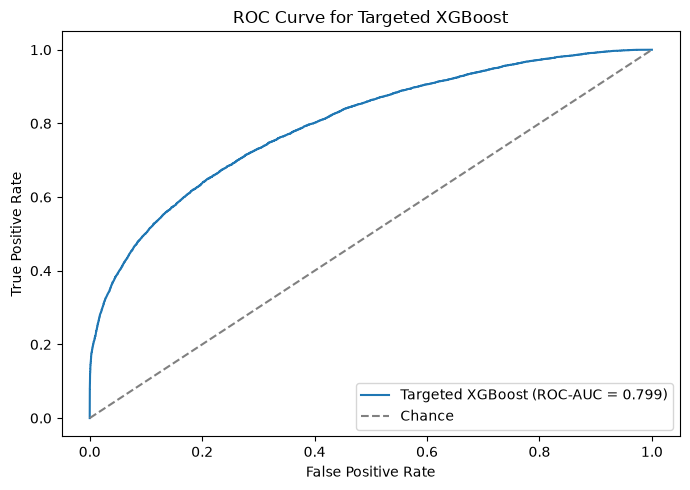

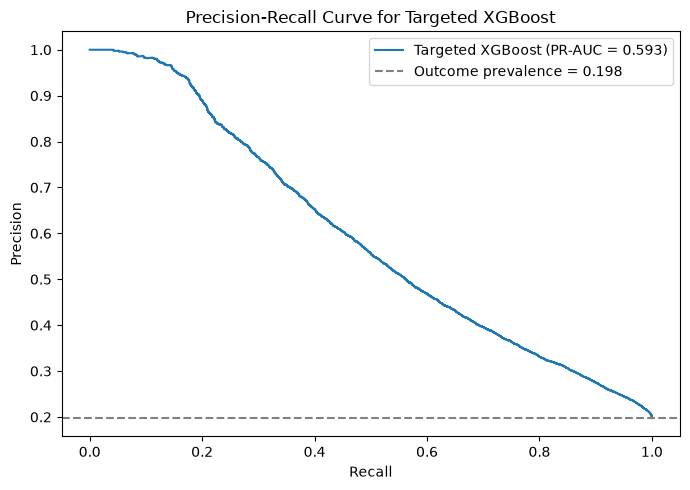

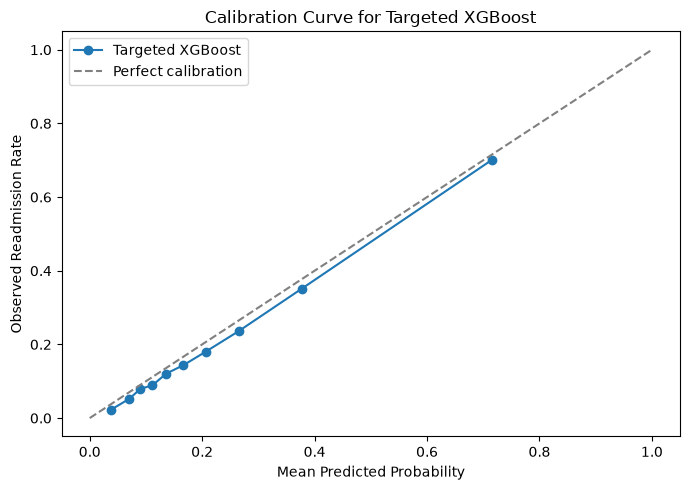

Targeted XGBoost official threshold: 0.31 ( training balanced precision-recall threshold )
Targeted XGBoost performance:
                                               model  \
0                 Targeted XGBoost default threshold   
1  Targeted XGBoost official balanced precision-r...   
2         Targeted XGBoost training Youden threshold   
3  Targeted XGBoost balanced precision-recall thr...   
4  Targeted XGBoost exploratory held-out F1 thres...   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.8432             0.6531   
1                   official       0.31    0.8148             0.7068   
2         recall sensitivity       0.23    0.7590             0.7193   
3  balanced precision-recall       0.31    0.8148             0.7068   
4                exploratory       0.31    0.8148             0.7068   

   precision  recall_sensitivity  specificity  f1_score  roc_auc  \
0     0.7187              0.3389       0.

In [24]:
#evaluate targeted xgboost and save outputs, only evaluate targeted xgboost if final probabilities exist
if xgboost_available and targeted_xgboost_test_probability is not None:
#select targeted-model thresholds from training predictions
    targeted_xgboost_threshold_table, targeted_xgboost_best_f1_threshold, targeted_xgboost_best_youden_threshold = find_best_threshold(
        y_train, targeted_xgboost_train_probability)
    targeted_xgboost_balanced_pr_threshold = select_balanced_precision_recall_threshold(targeted_xgboost_threshold_table, min_recall=0.10)
    targeted_xgboost_threshold_table.to_csv(
        xgboost_targeted_output_path / "t3_4_xgboost_targeted_threshold_search_training.csv", index=False)

    #official operating threshold is selected using training predictions only; held-out sweeps are reported as sensitivity checks
    targeted_xgboost_official_threshold = targeted_xgboost_balanced_pr_threshold
    targeted_xgboost_official_threshold_name = "training balanced precision-recall threshold"
#prepare threshold sensitivity points for reporting
    targeted_xgboost_test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        targeted_xgboost_best_youden_threshold, targeted_xgboost_balanced_pr_threshold, targeted_xgboost_best_f1_threshold, 0.50, 0.55, 0.60]
    targeted_xgboost_test_threshold_comparison_df = make_test_threshold_comparison(
        y_test, targeted_xgboost_test_probability, targeted_xgboost_test_threshold_values)
    targeted_xgboost_test_threshold_comparison_df.to_csv(
        xgboost_targeted_output_path / "t3_4_xgboost_targeted_test_threshold_comparison.csv",
        index=False)
    targeted_xgboost_heldout_f1_threshold = targeted_xgboost_test_threshold_comparison_df.sort_values(
        "f1_score", ascending=False).iloc[0]["threshold"]

#record threshold roles and their selection source
    targeted_xgboost_threshold_summary_df = pd.DataFrame([{"model": "Targeted XGBoost", "threshold_role": "default", "threshold": 0.50,
            "selection_data": "standard probability cut-off", "used_for_saved_predictions": False},
        {"model": "Targeted XGBoost", "threshold_role": "official", "threshold": targeted_xgboost_official_threshold,
            "selection_data": targeted_xgboost_official_threshold_name, "used_for_saved_predictions": True},
        {"model": "Targeted XGBoost", "threshold_role": "recall sensitivity", "threshold": targeted_xgboost_best_youden_threshold,
            "selection_data": "training Youden index", "used_for_saved_predictions": False},
        {"model": "Targeted XGBoost", "threshold_role": "balanced precision-recall", "threshold": targeted_xgboost_balanced_pr_threshold,
            "selection_data": "training threshold balancing precision and recall", "used_for_saved_predictions": True},
        {"model": "Targeted XGBoost", "threshold_role": "exploratory", "threshold": targeted_xgboost_heldout_f1_threshold,
            "selection_data": "held-out F1 sweep", "used_for_saved_predictions": False}]).round(4)
    targeted_xgboost_threshold_summary_df.to_csv(
        xgboost_targeted_output_path / "t3_4_xgboost_targeted_threshold_summary.csv", index=False)

    targeted_xgboost_timing_kwargs = {"training_time_seconds": targeted_xgboost_training_time_seconds,
        "train_inference_time_seconds": targeted_xgboost_train_inference_time_seconds,
        "test_inference_time_seconds": targeted_xgboost_test_inference_time_seconds,
        "number_of_test_admissions": len(y_test)}

#evaluate held-out test performance at each threshold
    targeted_xgboost_performance_rows = [
        add_timing_metrics(evaluate_binary_predictions("Targeted XGBoost default threshold", y_test, targeted_xgboost_test_probability, 0.50), **targeted_xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted XGBoost official balanced precision-recall threshold", y_test, targeted_xgboost_test_probability, targeted_xgboost_official_threshold), **targeted_xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted XGBoost training Youden threshold", y_test, targeted_xgboost_test_probability, targeted_xgboost_best_youden_threshold), **targeted_xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted XGBoost balanced precision-recall threshold", y_test, targeted_xgboost_test_probability, targeted_xgboost_balanced_pr_threshold), **targeted_xgboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted XGBoost exploratory held-out F1 threshold", y_test, targeted_xgboost_test_probability, targeted_xgboost_heldout_f1_threshold), **targeted_xgboost_timing_kwargs)]

    targeted_xgboost_performance_df = pd.DataFrame(targeted_xgboost_performance_rows)
    targeted_xgboost_performance_df.insert(1, "threshold_role", ["default", "official", "recall sensitivity", "balanced precision-recall", "exploratory"])
    targeted_xgboost_performance_df = targeted_xgboost_performance_df.round(4)
    targeted_xgboost_performance_df.to_csv(
        xgboost_targeted_output_path / "t3_4_xgboost_targeted_performance.csv", index=False)

#save test predictions for wp3.6 and wp4
    targeted_xgboost_predictions = save_prediction_file(xgboost_targeted_output_path,
        "t3_4_xgboost_targeted_test_predictions.csv", test_ids,
        targeted_xgboost_test_probability, targeted_xgboost_official_threshold)
    joblib.dump(targeted_xgboost_model, xgboost_targeted_output_path / "t3_4_xgboost_targeted_model.joblib")

#save threshold-specific confusion matrices
    targeted_xgboost_confusion_rows = []
    for threshold_name, threshold, threshold_role in [("Targeted XGBoost default threshold", 0.50, "default"),
        ("Targeted XGBoost official balanced precision-recall threshold", targeted_xgboost_official_threshold, "official"),
        ("Targeted XGBoost training Youden threshold", targeted_xgboost_best_youden_threshold, "recall sensitivity"),
        ("Targeted XGBoost balanced precision-recall threshold", targeted_xgboost_balanced_pr_threshold, "balanced precision-recall"),
        ("Targeted XGBoost exploratory held-out F1 threshold", targeted_xgboost_heldout_f1_threshold, "exploratory")]:
        y_pred = (targeted_xgboost_test_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        targeted_xgboost_confusion_rows.append({"model": threshold_name, "threshold_role": threshold_role, "threshold": threshold,
            "true_negatives": tn, "false_positives": fp,
            "false_negatives": fn, "true_positives": tp})
    targeted_xgboost_confusion_df = pd.DataFrame(targeted_xgboost_confusion_rows)
    targeted_xgboost_confusion_df.to_csv(
        xgboost_targeted_output_path / "t3_4_xgboost_targeted_confusion_matrices.csv", index=False)

#save roc, pr, and calibration plots
    targeted_xgboost_calibration_df = plot_model_curves("Targeted XGBoost", y_test, targeted_xgboost_test_probability,
        xgboost_targeted_output_path, "t3_4_xgboost_targeted")

    targeted_xgboost_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
        "feature_importance": targeted_xgboost_model.feature_importances_}).sort_values("feature_importance", ascending=False)
    targeted_xgboost_importance_df.to_csv(
        xgboost_targeted_output_path / "t3_4_xgboost_targeted_feature_importance.csv",
        index=False)

    with pd.ExcelWriter(xgboost_targeted_output_path / "t3_4_xgboost_targeted_tables.xlsx") as writer:
        targeted_xgboost_performance_df.to_excel(writer, sheet_name="performance", index=False)
        targeted_xgboost_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
        targeted_xgboost_threshold_summary_df.to_excel(writer, sheet_name="threshold_summary", index=False)
        targeted_xgboost_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
        targeted_xgboost_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
        xgboost_targeted_screening_df.to_excel(writer, sheet_name="hyperparameter_screen", index=False)
        targeted_xgboost_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
        targeted_xgboost_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    print("Targeted XGBoost official threshold:", round(targeted_xgboost_official_threshold, 2), "(", targeted_xgboost_official_threshold_name, ")")
    print("Targeted XGBoost performance:")
    print(targeted_xgboost_performance_df)
    print("\nTop 30 targeted XGBoost features:")
    print(targeted_xgboost_importance_df.head(30))
else:
    print("Targeted XGBoost evaluation outputs were skipped.")

**Targeted CatBoost sensitivity screening**

This focused second-pass sweep searches around the strongest CatBoost results while explicitly varying tree depth, iterations, learning rate, class-weight strength, and regularisation. Early stopping is retained so longer runs can stop when validation performance no longer improves.




In [25]:
#run targeted catboost tuning around the best initial configuration if catboost is available
catboost_targeted_screening_df = pd.DataFrame()
targeted_catboost_model = None
targeted_catboost_train_probability = None
targeted_catboost_test_probability = None
best_targeted_catboost_config = {}

#skip targeted screening if the first-stage search is disabled
if not run_hyperparameter_screening:
    print("Targeted CatBoost screening skipped because run_hyperparameter_screening is False.")
elif catboost_available:
    #build the targeted search space from the best first-stage catboost configuration.
    catboost_targeted_parameter_space = make_catboost_targeted_parameter_space(best_catboost_config)
    save_parameter_space(catboost_targeted_parameter_space, catboost_targeted_output_path,
        "t3_4_catboost_targeted_generated_parameter_space.csv")
    print("Best first-stage CatBoost configuration used to generate targeted space:")
    print(best_catboost_config)
    print("Generated targeted CatBoost parameter space:")
    print(catboost_targeted_parameter_space)

    catboost_targeted_candidate_configs = list(
    #targeted catboost varies nearby depth, regularisation, sampling, and class weight.
        ParameterSampler(catboost_targeted_parameter_space, n_iter=50, random_state=84))
    catboost_targeted_rows = []
#time the targeted screening loop in seconds
    search_start = time.perf_counter()

#fit each nearby targeted candidate
    for config_number, config in enumerate(catboost_targeted_candidate_configs, start=1):
        #separate the class-weight multiplier from catboost hyperparameters
        config = config.copy()
        class_weight_multiplier = config.pop("class_weight_multiplier")
        adjusted_positive_class_weight = scale_pos_weight * class_weight_multiplier
        print("Training targeted CatBoost configuration", config_number, "of", len(catboost_targeted_candidate_configs))
        print({**config, "class_weight_multiplier": class_weight_multiplier})
        config_start = time.perf_counter()
        screening_model = CatBoostClassifier(**config, loss_function="Logloss", eval_metric="PRAUC",
            bootstrap_type="Bernoulli", class_weights=[1.0, adjusted_positive_class_weight],
            random_seed=42, verbose=False, allow_writing_files=False, thread_count=-1)
        
        screening_model.fit(X_screen_train, y_screen_train, eval_set=(X_screen_val, y_screen_val),
        #use_best_model keeps the best validation iteration from each candidate.
            use_best_model=True, early_stopping_rounds=50, verbose=False)
        
#score train and validation probabilities for gap filtering
        train_probability = screening_model.predict_proba(X_screen_train)[:, 1]
        val_probability = screening_model.predict_proba(X_screen_val)[:, 1]
        elapsed_seconds = time.perf_counter() - config_start
        best_iteration = screening_model.get_best_iteration()

        catboost_targeted_rows.append({"config_number": config_number, **config,
            "class_weight_multiplier": class_weight_multiplier,
            "effective_positive_class_weight": adjusted_positive_class_weight,
            "best_iteration": best_iteration,
            "training_roc_auc": roc_auc_score(y_screen_train, train_probability),
            "validation_roc_auc": roc_auc_score(y_screen_val, val_probability),
            "training_pr_auc_average_precision": average_precision_score(y_screen_train, train_probability),
            "validation_pr_auc_average_precision": average_precision_score(y_screen_val, val_probability),
            "validation_brier_score": brier_score_loss(y_screen_val, val_probability),
            "elapsed_seconds": elapsed_seconds})
        print("Validation ROC-AUC:", round(catboost_targeted_rows[-1]["validation_roc_auc"], 4))
        print("Validation PR-AUC:", round(catboost_targeted_rows[-1]["validation_pr_auc_average_precision"], 4))
        print("Best iteration:", best_iteration)
        print("Elapsed seconds:", round(elapsed_seconds, 2))
        print()

    catboost_targeted_screening_df = pd.DataFrame(catboost_targeted_rows).sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    catboost_targeted_screening_df.to_csv(
        catboost_targeted_output_path / "t3_4_catboost_targeted_hyperparameter_screening.csv", index=False)
    
#select the best eligible targeted candidate
    best_targeted_catboost_config_number, best_targeted_catboost_config, catboost_targeted_selection_audit_df = select_best_config_with_pr_auc_gap_filter(
        catboost_targeted_screening_df, catboost_targeted_candidate_configs, "Targeted CatBoost",
        catboost_targeted_output_path, "t3_4_catboost_targeted_gap_filtered_selection_audit.csv",
        max_allowed_pr_auc_gap=max_allowed_pr_auc_gap, use_gap_filter=use_pr_auc_gap_filter)

    print("Total targeted CatBoost tuning time in seconds:", round(time.perf_counter() - search_start, 2))
    print()
    print("Top targeted CatBoost tuning results:")
    print(catboost_targeted_screening_df.head(10).round(4))
    print()
    print("Best targeted CatBoost configuration:")
    print(best_targeted_catboost_config)
else:
    print("Targeted CatBoost tuning was skipped because CatBoost is unavailable.")

Best first-stage CatBoost configuration used to generate targeted space:
{'subsample': 0.9, 'rsm': 0.75, 'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 1000, 'depth': 7}
Generated targeted CatBoost parameter space:
{'iterations': [850, 925, 1000, 1075, 1150], 'learning_rate': [0.0375, 0.045, 0.05, 0.0575], 'depth': [6, 7, 8], 'l2_leaf_reg': [7.5, 10.0, 15.0, 20.0], 'subsample': [0.8, 0.9, 0.95], 'rsm': [0.65, 0.75, 0.85], 'class_weight_multiplier': [0.3, 0.35, 0.4, 0.45, 0.5]}
Training targeted CatBoost configuration 1 of 50
{'subsample': 0.9, 'rsm': 0.65, 'learning_rate': 0.045, 'l2_leaf_reg': 7.5, 'iterations': 1000, 'depth': 8, 'class_weight_multiplier': 0.4}
Validation ROC-AUC: 0.7928
Validation PR-AUC: 0.5899
Best iteration: 516
Elapsed seconds: 24.7

Training targeted CatBoost configuration 2 of 50
{'subsample': 0.8, 'rsm': 0.65, 'learning_rate': 0.0375, 'l2_leaf_reg': 15.0, 'iterations': 1075, 'depth': 7, 'class_weight_multiplier': 0.35}
Validation ROC-AUC: 0.7941
Valid

**Train final targeted CatBoost model**

The selected targeted CatBoost configuration is refitted on the full training set. If screening identified a best iteration, the final CatBoost model uses that shorter iteration count for the full-data fit.


In [26]:
#train the final targeted catboost model on the full training set
#only fit final targeted catboost if targeted screening selected a config
if catboost_available and best_targeted_catboost_config:
#copy the selected targeted catboost config before removing helper-only fields
    final_targeted_catboost_config = best_targeted_catboost_config.copy()
    targeted_catboost_class_weight_multiplier = final_targeted_catboost_config.pop("class_weight_multiplier")
    targeted_catboost_positive_class_weight = scale_pos_weight * targeted_catboost_class_weight_multiplier

    #carry forward the best iteration found during targeted screening
#carry forward the best iteration found during screening
    targeted_catboost_best_iteration = catboost_targeted_screening_df.iloc[0]["best_iteration"]
    if pd.notna(targeted_catboost_best_iteration):
        final_targeted_catboost_config["iterations"] = max(1, int(targeted_catboost_best_iteration) + 1)
        
    targeted_catboost_model = CatBoostClassifier(**final_targeted_catboost_config, loss_function="Logloss",
        eval_metric="PRAUC", custom_metric=["AUC", "Logloss"], bootstrap_type="Bernoulli",
        class_weights=[1.0, targeted_catboost_positive_class_weight],
        random_seed=42, verbose=100, allow_writing_files=False, thread_count=-1)

    print("Training final targeted CatBoost model on full training data...")
#time the final targeted full-training fit
    targeted_catboost_training_start = time.perf_counter()
    if training_curve_eval_set_available:
        targeted_catboost_model.fit(X_train, y_train, eval_set=catboost_curve_eval_set, use_best_model=False, verbose=100)
    else:
        targeted_catboost_model.fit(X_train, y_train, verbose=100)
    targeted_catboost_training_time_seconds = time.perf_counter() - targeted_catboost_training_start
    targeted_catboost_curve_config = final_targeted_catboost_config.copy()
    targeted_catboost_curve_config["class_weight_multiplier"] = targeted_catboost_class_weight_multiplier
    store_training_curve_result("Targeted CatBoost", targeted_catboost_model, targeted_catboost_curve_config)
    print("Targeted CatBoost training complete.")

#measure training-set inference and probabilities
    targeted_catboost_train_prediction_start = time.perf_counter()
    targeted_catboost_train_probability = targeted_catboost_model.predict_proba(X_train)[:, 1]
    targeted_catboost_train_inference_time_seconds = time.perf_counter() - targeted_catboost_train_prediction_start

#measure held-out test inference and probabilities
    targeted_catboost_test_prediction_start = time.perf_counter()
    targeted_catboost_test_probability = targeted_catboost_model.predict_proba(X_test)[:, 1]
    targeted_catboost_test_inference_time_seconds = time.perf_counter() - targeted_catboost_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, targeted_catboost_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, targeted_catboost_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, targeted_catboost_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, targeted_catboost_test_probability), 4))
    print("Screening best iteration used for final refit:", targeted_catboost_best_iteration)
    print("Final iterations:", final_targeted_catboost_config["iterations"])
    print("Training time in seconds:", round(targeted_catboost_training_time_seconds, 2))
else:
    print("Final targeted CatBoost model was skipped.")

Training final targeted CatBoost model on full training data...
0:	learn: 0.5743452	test: 0.5793453	best: 0.5793453 (0)	total: 59.8ms	remaining: 40.4s
100:	learn: 0.6483044	test: 0.6523560	best: 0.6523560 (100)	total: 7.13s	remaining: 40.6s
200:	learn: 0.6638867	test: 0.6681255	best: 0.6681255 (200)	total: 14.2s	remaining: 33.6s
300:	learn: 0.6772339	test: 0.6814021	best: 0.6814021 (300)	total: 21.3s	remaining: 26.5s
400:	learn: 0.6913603	test: 0.6947918	best: 0.6947918 (400)	total: 28.4s	remaining: 19.4s
500:	learn: 0.7037972	test: 0.7066762	best: 0.7066762 (500)	total: 35.4s	remaining: 12.4s
600:	learn: 0.7158922	test: 0.7186644	best: 0.7186644 (600)	total: 42.6s	remaining: 5.31s
675:	learn: 0.7241966	test: 0.7270359	best: 0.7270359 (675)	total: 48.1s	remaining: 0us

bestTest = 0.727035883
bestIteration = 675

Targeted CatBoost training complete.
Training ROC-AUC: 0.8477
Test ROC-AUC: 0.7979
Training PR-AUC: 0.6697
Test PR-AUC: 0.5912
Screening best iteration used for final refit: 67

**Evaluate and save targeted CatBoost outputs**

This section evaluates targeted CatBoost using the same metric, threshold, prediction, and feature-importance outputs as the other gradient boosting models.


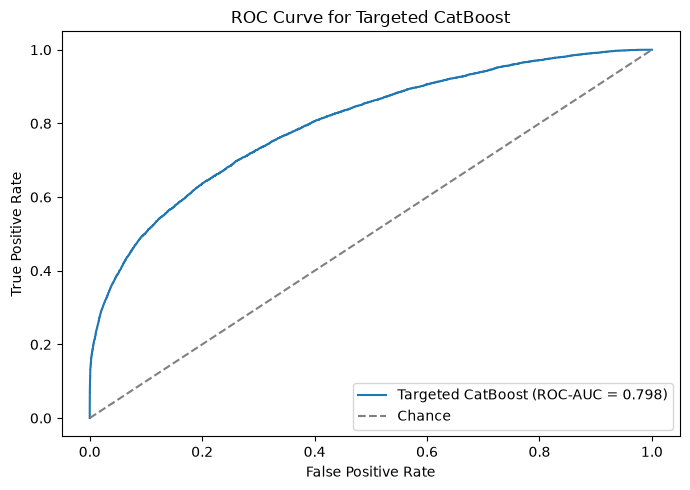

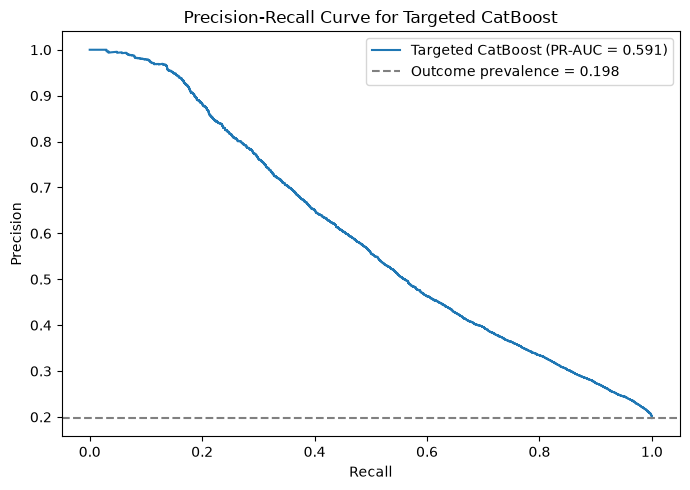

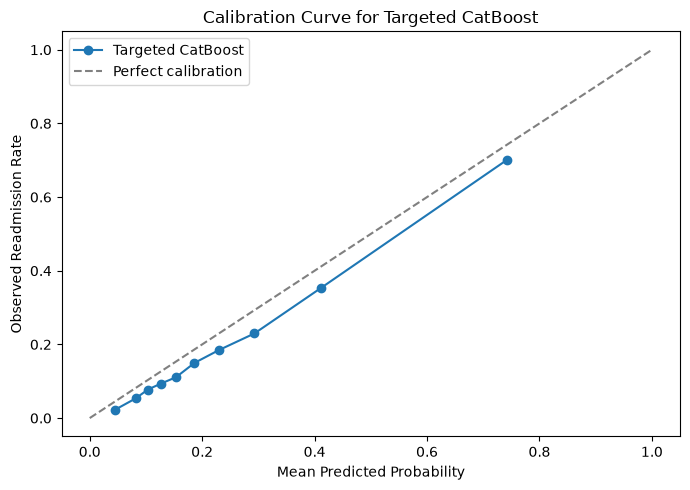

Targeted CatBoost official threshold: 0.35 ( training balanced precision-recall threshold )
Targeted CatBoost performance:
                                               model  \
0                Targeted CatBoost default threshold   
1  Targeted CatBoost official balanced precision-...   
2        Targeted CatBoost training Youden threshold   
3  Targeted CatBoost balanced precision-recall th...   
4  Targeted CatBoost exploratory held-out F1 thre...   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.8417             0.6632   
1                   official       0.35    0.8180             0.7042   
2         recall sensitivity       0.26    0.7633             0.7184   
3  balanced precision-recall       0.35    0.8180             0.7042   
4                exploratory       0.34    0.8139             0.7065   

   precision  recall_sensitivity  specificity  f1_score  roc_auc  \
0     0.6848              0.3682       

In [27]:
#evaluate targeted catboost and save outputs, only evaluate targeted catboost if final probabilities exist
if catboost_available and targeted_catboost_test_probability is not None:
#select targeted-model thresholds from training predictions
    targeted_catboost_threshold_table, targeted_catboost_best_f1_threshold, targeted_catboost_best_youden_threshold = find_best_threshold(
        y_train, targeted_catboost_train_probability)
    targeted_catboost_balanced_pr_threshold = select_balanced_precision_recall_threshold(targeted_catboost_threshold_table, min_recall=0.10)
    targeted_catboost_threshold_table.to_csv(
        catboost_targeted_output_path / "t3_4_catboost_targeted_threshold_search_training.csv", index=False)

    #official operating threshold is selected using training predictions only; held-out sweeps are reported as sensitivity checks
    targeted_catboost_official_threshold = targeted_catboost_balanced_pr_threshold
    targeted_catboost_official_threshold_name = "training balanced precision-recall threshold"
#prepare threshold sensitivity points for reporting
    targeted_catboost_test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        targeted_catboost_best_youden_threshold, targeted_catboost_balanced_pr_threshold, targeted_catboost_best_f1_threshold, 0.50, 0.55, 0.60]
    targeted_catboost_test_threshold_comparison_df = make_test_threshold_comparison(
        y_test, targeted_catboost_test_probability, targeted_catboost_test_threshold_values)
    targeted_catboost_test_threshold_comparison_df.to_csv(
        catboost_targeted_output_path / "t3_4_catboost_targeted_test_threshold_comparison.csv",
        index=False)
    targeted_catboost_heldout_f1_threshold = targeted_catboost_test_threshold_comparison_df.sort_values(
        "f1_score", ascending=False).iloc[0]["threshold"]

#record threshold roles and their selection source
    targeted_catboost_threshold_summary_df = pd.DataFrame([{"model": "Targeted CatBoost", "threshold_role": "default", "threshold": 0.50,
            "selection_data": "standard probability cut-off", "used_for_saved_predictions": False},
        {"model": "Targeted CatBoost", "threshold_role": "official", "threshold": targeted_catboost_official_threshold,
            "selection_data": targeted_catboost_official_threshold_name, "used_for_saved_predictions": True},
        {"model": "Targeted CatBoost", "threshold_role": "recall sensitivity", "threshold": targeted_catboost_best_youden_threshold,
            "selection_data": "training Youden index", "used_for_saved_predictions": False},
        {"model": "Targeted CatBoost", "threshold_role": "balanced precision-recall", "threshold": targeted_catboost_balanced_pr_threshold,
            "selection_data": "training threshold balancing precision and recall", "used_for_saved_predictions": True},
        {"model": "Targeted CatBoost", "threshold_role": "exploratory", "threshold": targeted_catboost_heldout_f1_threshold,
            "selection_data": "held-out F1 sweep", "used_for_saved_predictions": False}]).round(4)
    targeted_catboost_threshold_summary_df.to_csv(
        catboost_targeted_output_path / "t3_4_catboost_targeted_threshold_summary.csv", index=False)

    targeted_catboost_timing_kwargs = {"training_time_seconds": targeted_catboost_training_time_seconds,
        "train_inference_time_seconds": targeted_catboost_train_inference_time_seconds,
        "test_inference_time_seconds": targeted_catboost_test_inference_time_seconds,
        "number_of_test_admissions": len(y_test)}

#evaluate held-out test performance at each threshold
    targeted_catboost_performance_rows = [
        add_timing_metrics(evaluate_binary_predictions("Targeted CatBoost default threshold", y_test, targeted_catboost_test_probability, 0.50), **targeted_catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted CatBoost official balanced precision-recall threshold", y_test, targeted_catboost_test_probability, targeted_catboost_official_threshold), **targeted_catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted CatBoost training Youden threshold", y_test, targeted_catboost_test_probability, targeted_catboost_best_youden_threshold), **targeted_catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted CatBoost balanced precision-recall threshold", y_test, targeted_catboost_test_probability, targeted_catboost_balanced_pr_threshold), **targeted_catboost_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted CatBoost exploratory held-out F1 threshold", y_test, targeted_catboost_test_probability, targeted_catboost_heldout_f1_threshold), **targeted_catboost_timing_kwargs)]
    
    targeted_catboost_performance_df = pd.DataFrame(targeted_catboost_performance_rows)
    targeted_catboost_performance_df.insert(1, "threshold_role", ["default", "official", "recall sensitivity", "balanced precision-recall", "exploratory"])
    targeted_catboost_performance_df = targeted_catboost_performance_df.round(4)
    targeted_catboost_performance_df.to_csv(
        catboost_targeted_output_path / "t3_4_catboost_targeted_performance.csv", index=False)

#save test predictions for wp3.6 and wp4
    targeted_catboost_predictions = save_prediction_file(catboost_targeted_output_path,
        "t3_4_catboost_targeted_test_predictions.csv", test_ids,
        targeted_catboost_test_probability, targeted_catboost_official_threshold)
    targeted_catboost_model.save_model(str(catboost_targeted_output_path / "t3_4_catboost_targeted_model.cbm"))
    joblib.dump(targeted_catboost_model, catboost_targeted_output_path / "t3_4_catboost_targeted_model.joblib")

#save threshold-specific confusion matrices
    targeted_catboost_confusion_rows = []
    for threshold_name, threshold, threshold_role in [("Targeted CatBoost default threshold", 0.50, "default"),
        ("Targeted CatBoost official balanced precision-recall threshold", targeted_catboost_official_threshold, "official"),
        ("Targeted CatBoost training Youden threshold", targeted_catboost_best_youden_threshold, "recall sensitivity"),
        ("Targeted CatBoost balanced precision-recall threshold", targeted_catboost_balanced_pr_threshold, "balanced precision-recall"),
        ("Targeted CatBoost exploratory held-out F1 threshold", targeted_catboost_heldout_f1_threshold, "exploratory")]:
        y_pred = (targeted_catboost_test_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        targeted_catboost_confusion_rows.append({"model": threshold_name, "threshold_role": threshold_role, "threshold": threshold,
            "true_negatives": tn, "false_positives": fp,
            "false_negatives": fn, "true_positives": tp})
    targeted_catboost_confusion_df = pd.DataFrame(targeted_catboost_confusion_rows)
    targeted_catboost_confusion_df.to_csv(
        catboost_targeted_output_path / "t3_4_catboost_targeted_confusion_matrices.csv", index=False)

#save roc, pr, and calibration plots
    targeted_catboost_calibration_df = plot_model_curves("Targeted CatBoost", y_test, targeted_catboost_test_probability,
        catboost_targeted_output_path, "t3_4_catboost_targeted")

    targeted_catboost_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
        "feature_importance": targeted_catboost_model.get_feature_importance()}).sort_values("feature_importance", ascending=False)
    targeted_catboost_importance_df.to_csv(catboost_targeted_output_path / "t3_4_catboost_targeted_feature_importance.csv",
        index=False)

    with pd.ExcelWriter(catboost_targeted_output_path / "t3_4_catboost_targeted_tables.xlsx") as writer:
        targeted_catboost_performance_df.to_excel(writer, sheet_name="performance", index=False)
        targeted_catboost_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
        targeted_catboost_threshold_summary_df.to_excel(writer, sheet_name="threshold_summary", index=False)
        targeted_catboost_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
        targeted_catboost_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
        catboost_targeted_screening_df.to_excel(writer, sheet_name="hyperparameter_screen", index=False)
        targeted_catboost_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
        targeted_catboost_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    print("Targeted CatBoost official threshold:", round(targeted_catboost_official_threshold, 2), "(", targeted_catboost_official_threshold_name, ")")
    print("Targeted CatBoost performance:")
    print(targeted_catboost_performance_df)
    print("\nTop 30 targeted CatBoost features:")
    print(targeted_catboost_importance_df.head(30))
else:
    print("Targeted CatBoost evaluation outputs were skipped.")

**Targeted LightGBM sensitivity screening**

This focused second-pass sweep searches around stronger LightGBM settings while varying class weighting, tree complexity, and regularisation.

In [28]:
#run targeted lightgbm tuning around the best initial configuration if lightgbm is available
lightgbm_targeted_screening_df = pd.DataFrame()
targeted_lightgbm_model = None
targeted_lightgbm_train_probability = None
targeted_lightgbm_test_probability = None
best_targeted_lightgbm_config = {}

#skip targeted screening if the first-stage search is disabled
if not run_hyperparameter_screening:
    print("Targeted LightGBM screening skipped because run_hyperparameter_screening is False.")
elif lightgbm_available:
    #build the targeted search space from the best first-stage lightgbm configuration.
    lightgbm_targeted_parameter_space = make_lightgbm_targeted_parameter_space(best_lightgbm_config)
    save_parameter_space(lightgbm_targeted_parameter_space, lightgbm_targeted_output_path,
        "t3_4_lightgbm_targeted_generated_parameter_space.csv")
    print("Best first-stage LightGBM configuration used to generate targeted space:")
    print(best_lightgbm_config)
    print("Generated targeted LightGBM parameter space:")
    print(lightgbm_targeted_parameter_space)

    lightgbm_targeted_candidate_configs = list(ParameterSampler(lightgbm_targeted_parameter_space, n_iter=50, random_state=84))
    #targeted lightgbm focuses on nearby leaves, child samples, regularisation, and class weight.
    lightgbm_targeted_rows = []
#time the targeted screening loop in seconds
    search_start = time.perf_counter()

#fit each nearby targeted candidate
    for config_number, config in enumerate(lightgbm_targeted_candidate_configs, start=1):
        config = config.copy()
        class_weight_multiplier = config.pop("scale_pos_weight_multiplier")
        adjusted_scale_pos_weight = scale_pos_weight * class_weight_multiplier
        print("Training targeted LightGBM configuration", config_number, "of", len(lightgbm_targeted_candidate_configs))
        print({**config, "scale_pos_weight_multiplier": class_weight_multiplier})
        config_start = time.perf_counter()
        screening_model = LGBMClassifier(**config, objective="binary",
            class_weight={0: 1.0, 1: adjusted_scale_pos_weight}, random_state=42,
            n_jobs=-1, verbosity=-1, force_col_wise=True)
        screening_model.fit(X_screen_train, y_screen_train, eval_set=[(X_screen_val, y_screen_val)],
        #early stopping limits overtraining within each sampled lightgbm candidate.
            eval_metric="average_precision", callbacks=[early_stopping(50, verbose=False)])

#score train and validation probabilities for gap filtering
        train_probability = screening_model.predict_proba(X_screen_train)[:, 1]
        val_probability = screening_model.predict_proba(X_screen_val)[:, 1]
        elapsed_seconds = time.perf_counter() - config_start
        best_iteration = getattr(screening_model, "best_iteration_", np.nan)
        lightgbm_targeted_rows.append({"config_number": config_number, **config,
            "scale_pos_weight_multiplier": class_weight_multiplier,
            "effective_scale_pos_weight": adjusted_scale_pos_weight,
            "best_iteration": best_iteration,
            "training_roc_auc": roc_auc_score(y_screen_train, train_probability),
            "validation_roc_auc": roc_auc_score(y_screen_val, val_probability),
            "training_pr_auc_average_precision": average_precision_score(y_screen_train, train_probability),
            "validation_pr_auc_average_precision": average_precision_score(y_screen_val, val_probability),
            "validation_brier_score": brier_score_loss(y_screen_val, val_probability),
            "elapsed_seconds": elapsed_seconds})
        print("Validation ROC-AUC:", round(lightgbm_targeted_rows[-1]["validation_roc_auc"], 4))
        print("Validation PR-AUC:", round(lightgbm_targeted_rows[-1]["validation_pr_auc_average_precision"], 4))
        print("Best iteration:", best_iteration)
        print("Elapsed seconds:", round(elapsed_seconds, 2))
        print()

    lightgbm_targeted_screening_df = pd.DataFrame(lightgbm_targeted_rows).sort_values(
        ["validation_pr_auc_average_precision", "validation_roc_auc"], ascending=False).reset_index(drop=True)
    lightgbm_targeted_screening_df.to_csv(
        lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_hyperparameter_screening.csv", index=False)

#select the best eligible targeted candidate
    best_targeted_lightgbm_config_number, best_targeted_lightgbm_config, lightgbm_targeted_selection_audit_df = select_best_config_with_pr_auc_gap_filter(
        lightgbm_targeted_screening_df, lightgbm_targeted_candidate_configs, "Targeted LightGBM",
        lightgbm_targeted_output_path, "t3_4_lightgbm_targeted_gap_filtered_selection_audit.csv",
        max_allowed_pr_auc_gap=max_allowed_pr_auc_gap, use_gap_filter=use_pr_auc_gap_filter)

    print("Total targeted LightGBM tuning time in seconds:", round(time.perf_counter() - search_start, 2))
    print()
    print("Top targeted LightGBM tuning results:")
    print(lightgbm_targeted_screening_df.head(10).round(4))
    print()
    print("Best targeted LightGBM configuration:")
    print(best_targeted_lightgbm_config)
else:
    print("Targeted LightGBM tuning was skipped because LightGBM is unavailable.")

Best first-stage LightGBM configuration used to generate targeted space:
{'subsample': 0.85, 'reg_lambda': 45, 'reg_alpha': 0.5, 'num_leaves': 159, 'n_estimators': 500, 'min_child_samples': 125, 'max_depth': -1, 'learning_rate': 0.02, 'colsample_bytree': 0.9}
Generated targeted LightGBM parameter space:
{'n_estimators': [350, 425, 500, 575, 650], 'learning_rate': [0.014, 0.017, 0.02, 0.024], 'num_leaves': [127, 159, 191, 223], 'min_child_samples': [100, 125, 150, 175], 'max_depth': [-1, 6, 8, 10], 'subsample': [0.75, 0.85, 0.95], 'colsample_bytree': [0.8, 0.9, 1.0], 'reg_alpha': [0.0, 0.5, 1.0, 1.5], 'reg_lambda': [33.75, 45.0, 67.5, 90.0], 'scale_pos_weight_multiplier': [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]}
Training targeted LightGBM configuration 1 of 50
{'subsample': 0.95, 'reg_lambda': 67.5, 'reg_alpha': 1.5, 'num_leaves': 159, 'n_estimators': 425, 'min_child_samples': 150, 'max_depth': 8, 'learning_rate': 0.02, 'colsample_bytree': 0.9, 'scale_pos_weight_multiplier': 0.45}
Validation 

**Train final targeted LightGBM model**

The selected targeted LightGBM configuration is refitted on the full training set. If screening identified a best iteration, the final model uses that iteration count rather than forcing every boosting round.


In [29]:
#train the final targeted lightgbm model on the full training set
#only fit final targeted lightgbm if targeted screening selected a config
if lightgbm_available and best_targeted_lightgbm_config:
#copy the selected targeted lightgbm config before removing helper-only fields
    final_targeted_lightgbm_config = best_targeted_lightgbm_config.copy()
    targeted_lightgbm_class_weight_multiplier = final_targeted_lightgbm_config.pop("scale_pos_weight_multiplier")
    targeted_lightgbm_scale_pos_weight = scale_pos_weight * targeted_lightgbm_class_weight_multiplier

#carry forward the best iteration found during screening
    targeted_lightgbm_best_iteration = lightgbm_targeted_screening_df.iloc[0]["best_iteration"]
    if pd.notna(targeted_lightgbm_best_iteration):
        final_targeted_lightgbm_config["n_estimators"] = max(1, int(targeted_lightgbm_best_iteration)+1)

    targeted_lightgbm_model = LGBMClassifier(**final_targeted_lightgbm_config, objective="binary",
        class_weight={0: 1.0, 1: targeted_lightgbm_scale_pos_weight}, random_state=42,
        n_jobs=-1, verbosity=-1, force_col_wise=True)

    print("Training final targeted LightGBM model on full training data...")
#time the final targeted full-training fit
    targeted_lightgbm_training_start = time.perf_counter()
    if training_curve_eval_set_available:
        targeted_lightgbm_model.fit(X_train, y_train, eval_set=lightgbm_curve_eval_set,
            eval_metric=["binary_logloss", "auc", "average_precision"],
            callbacks=[log_evaluation(period=0)])
    else:
        targeted_lightgbm_model.fit(X_train, y_train)
    targeted_lightgbm_training_time_seconds = time.perf_counter() - targeted_lightgbm_training_start
    targeted_lightgbm_curve_config = final_targeted_lightgbm_config.copy()
    targeted_lightgbm_curve_config["scale_pos_weight_multiplier"] = targeted_lightgbm_class_weight_multiplier
    store_training_curve_result("Targeted LightGBM", targeted_lightgbm_model, targeted_lightgbm_curve_config)
    print("Targeted LightGBM training complete.")

#measure training-set inference and probabilities
    targeted_lightgbm_train_prediction_start = time.perf_counter()
    targeted_lightgbm_train_probability = targeted_lightgbm_model.predict_proba(X_train)[:, 1]
    targeted_lightgbm_train_inference_time_seconds = time.perf_counter() - targeted_lightgbm_train_prediction_start

#measure held-out test inference and probabilities
    targeted_lightgbm_test_prediction_start = time.perf_counter()
    targeted_lightgbm_test_probability = targeted_lightgbm_model.predict_proba(X_test)[:, 1]
    targeted_lightgbm_test_inference_time_seconds = time.perf_counter() - targeted_lightgbm_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, targeted_lightgbm_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, targeted_lightgbm_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, targeted_lightgbm_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, targeted_lightgbm_test_probability), 4))
    print("Screening best iteration used for final refit:", targeted_lightgbm_best_iteration)
    print("Final n_estimators:", final_targeted_lightgbm_config["n_estimators"])
    print("Training time in seconds:", round(targeted_lightgbm_training_time_seconds, 2))
else:
    print("Final targeted LightGBM model was skipped.")

Training final targeted LightGBM model on full training data...
Targeted LightGBM training complete.
Training ROC-AUC: 0.9175
Test ROC-AUC: 0.7999
Training PR-AUC: 0.7695
Test PR-AUC: 0.5945
Screening best iteration used for final refit: 385.0
Final n_estimators: 386
Training time in seconds: 52.87


**Evaluate and save targeted LightGBM outputs**

This section evaluates targeted LightGBM using the same threshold and output structure as the other models. It is usually the key comparator because LightGBM has been the strongest and fastest boosting model in the previous runs.


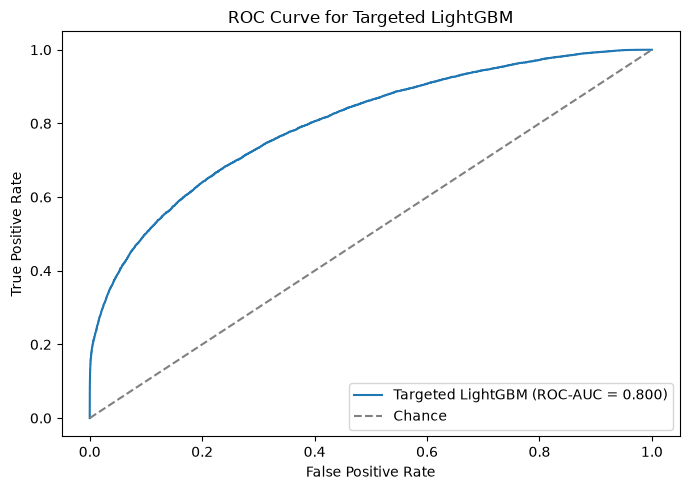

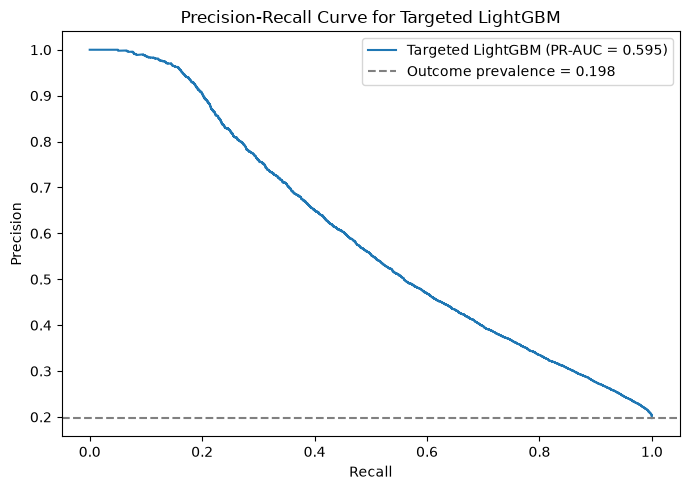

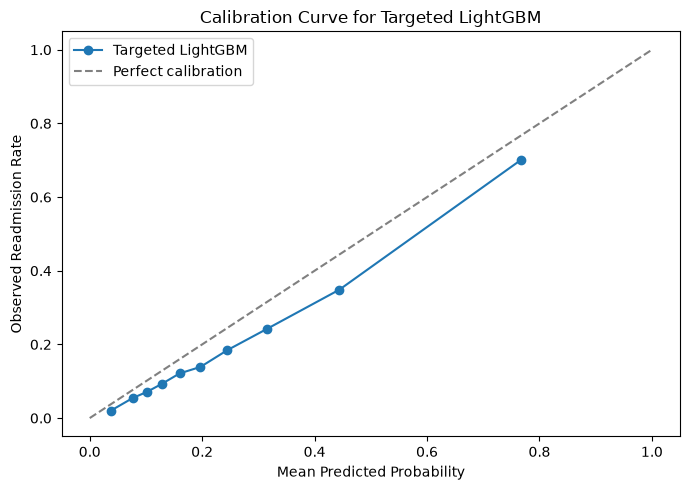

Targeted LightGBM official threshold: 0.39 ( training balanced precision-recall threshold )
Targeted LightGBM performance:
                                               model  \
0                Targeted LightGBM default threshold   
1  Targeted LightGBM official balanced precision-...   
2        Targeted LightGBM training Youden threshold   
3  Targeted LightGBM balanced precision-recall th...   
4  Targeted LightGBM exploratory held-out F1 thre...   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.8394             0.6722   
1                   official       0.39    0.8211             0.7005   
2         recall sensitivity       0.29    0.7727             0.7192   
3  balanced precision-recall       0.39    0.8211             0.7005   
4                exploratory       0.35    0.8069             0.7097   

   precision  recall_sensitivity  specificity  f1_score  roc_auc  \
0     0.6548              0.3958       

In [30]:
#evaluate targeted lightgbm and save outputs
#only evaluate targeted lightgbm if final probabilities exist
if lightgbm_available and targeted_lightgbm_test_probability is not None:
#select targeted-model thresholds from training predictions
    targeted_lightgbm_threshold_table, targeted_lightgbm_best_f1_threshold, targeted_lightgbm_best_youden_threshold = find_best_threshold(
        y_train, targeted_lightgbm_train_probability)
    targeted_lightgbm_balanced_pr_threshold = select_balanced_precision_recall_threshold(targeted_lightgbm_threshold_table, min_recall=0.10)
    targeted_lightgbm_threshold_table.to_csv(
        lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_threshold_search_training.csv", index=False)

    targeted_lightgbm_official_threshold = targeted_lightgbm_balanced_pr_threshold
    targeted_lightgbm_official_threshold_name = "training balanced precision-recall threshold"
#prepare threshold sensitivity points for reporting
    targeted_lightgbm_test_threshold_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
        targeted_lightgbm_best_youden_threshold, targeted_lightgbm_balanced_pr_threshold, targeted_lightgbm_best_f1_threshold, 0.50, 0.55, 0.60]
    targeted_lightgbm_test_threshold_comparison_df = make_test_threshold_comparison(
        y_test, targeted_lightgbm_test_probability, targeted_lightgbm_test_threshold_values)
    targeted_lightgbm_test_threshold_comparison_df.to_csv(
        lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_test_threshold_comparison.csv", index=False)
    targeted_lightgbm_heldout_f1_threshold = targeted_lightgbm_test_threshold_comparison_df.sort_values(
        "f1_score", ascending=False).iloc[0]["threshold"]

#record threshold roles and their selection source
    targeted_lightgbm_threshold_summary_df = pd.DataFrame([{"model": "Targeted LightGBM", "threshold_role": "default", "threshold": 0.50,
            "selection_data": "standard probability cut-off", "used_for_saved_predictions": False},
        {"model": "Targeted LightGBM", "threshold_role": "official", "threshold": targeted_lightgbm_official_threshold,
            "selection_data": targeted_lightgbm_official_threshold_name, "used_for_saved_predictions": True},
        {"model": "Targeted LightGBM", "threshold_role": "recall sensitivity", "threshold": targeted_lightgbm_best_youden_threshold,
            "selection_data": "training Youden index", "used_for_saved_predictions": False},
        {"model": "Targeted LightGBM", "threshold_role": "balanced precision-recall", "threshold": targeted_lightgbm_balanced_pr_threshold,
            "selection_data": "training threshold balancing precision and recall", "used_for_saved_predictions": True},
        {"model": "Targeted LightGBM", "threshold_role": "exploratory", "threshold": targeted_lightgbm_heldout_f1_threshold,
            "selection_data": "held-out F1 sweep", "used_for_saved_predictions": False}]).round(4)
    targeted_lightgbm_threshold_summary_df.to_csv(
        lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_threshold_summary.csv", index=False)

    targeted_lightgbm_timing_kwargs = {"training_time_seconds": targeted_lightgbm_training_time_seconds,
        "train_inference_time_seconds": targeted_lightgbm_train_inference_time_seconds,
        "test_inference_time_seconds": targeted_lightgbm_test_inference_time_seconds,
        "number_of_test_admissions": len(y_test)}

#evaluate held-out test performance at each threshold
    targeted_lightgbm_performance_rows = [
        add_timing_metrics(evaluate_binary_predictions("Targeted LightGBM default threshold", y_test, targeted_lightgbm_test_probability, 0.50), **targeted_lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted LightGBM official balanced precision-recall threshold", y_test, targeted_lightgbm_test_probability, targeted_lightgbm_official_threshold), **targeted_lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted LightGBM training Youden threshold", y_test, targeted_lightgbm_test_probability, targeted_lightgbm_best_youden_threshold), **targeted_lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted LightGBM balanced precision-recall threshold", y_test, targeted_lightgbm_test_probability, targeted_lightgbm_balanced_pr_threshold), **targeted_lightgbm_timing_kwargs),
        add_timing_metrics(evaluate_binary_predictions("Targeted LightGBM exploratory held-out F1 threshold", y_test, targeted_lightgbm_test_probability, targeted_lightgbm_heldout_f1_threshold), **targeted_lightgbm_timing_kwargs)]
    targeted_lightgbm_performance_df = pd.DataFrame(targeted_lightgbm_performance_rows)
    targeted_lightgbm_performance_df.insert(1, "threshold_role", ["default", "official", "recall sensitivity", "balanced precision-recall", "exploratory"])
    targeted_lightgbm_performance_df = targeted_lightgbm_performance_df.round(4)
    targeted_lightgbm_performance_df.to_csv(
        lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_performance.csv", index=False)

#save test predictions for wp3.6 and wp4
    targeted_lightgbm_predictions = save_prediction_file(lightgbm_targeted_output_path,
        "t3_4_lightgbm_targeted_test_predictions.csv", test_ids,
        targeted_lightgbm_test_probability, targeted_lightgbm_official_threshold)
    joblib.dump(targeted_lightgbm_model, lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_model.joblib")

#save threshold-specific confusion matrices
    targeted_lightgbm_confusion_rows = []
    for threshold_name, threshold, threshold_role in [("Targeted LightGBM default threshold", 0.50, "default"),
        ("Targeted LightGBM official balanced precision-recall threshold", targeted_lightgbm_official_threshold, "official"),
        ("Targeted LightGBM training Youden threshold", targeted_lightgbm_best_youden_threshold, "recall sensitivity"),
        ("Targeted LightGBM balanced precision-recall threshold", targeted_lightgbm_balanced_pr_threshold, "balanced precision-recall"),
        ("Targeted LightGBM exploratory held-out F1 threshold", targeted_lightgbm_heldout_f1_threshold, "exploratory")]:
        y_pred = (targeted_lightgbm_test_probability >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        targeted_lightgbm_confusion_rows.append({"model": threshold_name, "threshold_role": threshold_role, "threshold": threshold,
            "true_negatives": tn, "false_positives": fp,
            "false_negatives": fn, "true_positives": tp})
    targeted_lightgbm_confusion_df = pd.DataFrame(targeted_lightgbm_confusion_rows)
    targeted_lightgbm_confusion_df.to_csv(
        lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_confusion_matrices.csv", index=False)

#save roc, pr, and calibration plots
    targeted_lightgbm_calibration_df = plot_model_curves("Targeted LightGBM", y_test, targeted_lightgbm_test_probability,
        lightgbm_targeted_output_path, "t3_4_lightgbm_targeted")

    targeted_lightgbm_importance_df = pd.DataFrame({"processed_feature_name": feature_names,
        "feature_importance": targeted_lightgbm_model.feature_importances_}).sort_values("feature_importance", ascending=False)
    targeted_lightgbm_importance_df.to_csv(
        lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_feature_importance.csv", index=False)

    with pd.ExcelWriter(lightgbm_targeted_output_path / "t3_4_lightgbm_targeted_tables.xlsx") as writer:
        targeted_lightgbm_performance_df.to_excel(writer, sheet_name="performance", index=False)
        targeted_lightgbm_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
        targeted_lightgbm_threshold_summary_df.to_excel(writer, sheet_name="threshold_summary", index=False)
        targeted_lightgbm_test_threshold_comparison_df.to_excel(writer, sheet_name="test_thresholds", index=False)
        targeted_lightgbm_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
        lightgbm_targeted_screening_df.to_excel(writer, sheet_name="hyperparameter_screen", index=False)
        targeted_lightgbm_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
        targeted_lightgbm_importance_df.to_excel(writer, sheet_name="feature_importance", index=False)

    print("Targeted LightGBM official threshold:", round(targeted_lightgbm_official_threshold, 2), "(", targeted_lightgbm_official_threshold_name, ")")
    print("Targeted LightGBM performance:")
    print(targeted_lightgbm_performance_df)
    print("\nTop 30 targeted LightGBM features:")
    print(targeted_lightgbm_importance_df.head(30))
else:
    print("Targeted LightGBM evaluation outputs were skipped.")

**Calibrated targeted boosting models**

These cells fit sigmoid calibration layers for the selected targeted XGBoost, CatBoost, and LightGBM models. The base model is trained on the screening-training split, calibration is learned on the validation split, and the untouched held-out test set is used only for final reporting.


Training base targeted XGBoost model for sigmoid calibration...
Calibrated targeted XGBoost training complete.
Training ROC-AUC: 0.8345
Test ROC-AUC: 0.7932
Training PR-AUC: 0.6485
Test PR-AUC: 0.5844
Training plus calibration time in seconds: 14.94


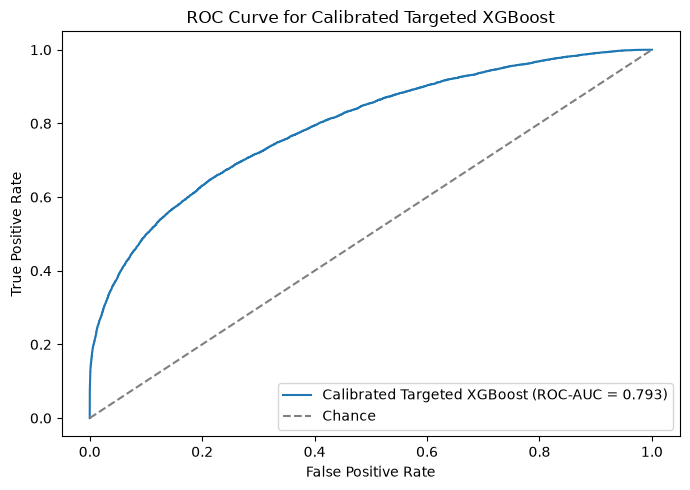

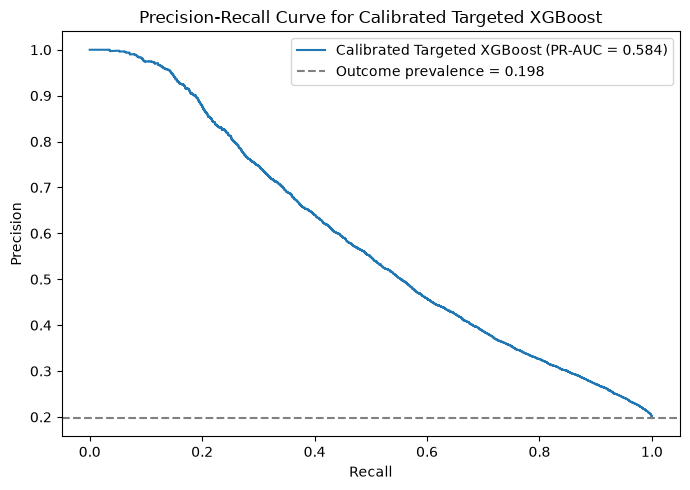

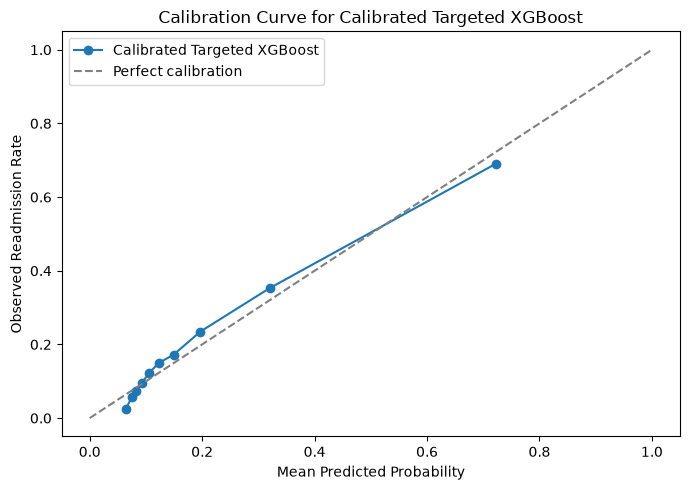

Calibrated Targeted XGBoost official threshold: 0.25 ( validation balanced precision-recall threshold after calibration )
Calibrated Targeted XGBoost performance:
                                               model  \
0      Calibrated Targeted XGBoost default threshold   
1  Calibrated Targeted XGBoost official balanced ...   
2  Calibrated Targeted XGBoost validation Youden ...   
3  Calibrated Targeted XGBoost balanced precision...   
4  Calibrated Targeted XGBoost exploratory held-o...   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.8413             0.6457   
1                   official       0.25    0.8162             0.7011   
2         recall sensitivity       0.16    0.7469             0.7154   
3  balanced precision-recall       0.25    0.8162             0.7011   
4                exploratory       0.24    0.8124             0.7032   

   precision  recall_sensitivity  specificity  f1_score  roc_auc  \

In [31]:
#train and save calibrated targeted xgboost outputs
calibrated_targeted_xgboost_model = None
calibrated_targeted_xgboost_train_probability = None
calibrated_targeted_xgboost_test_probability = None
calibrated_targeted_xgboost_performance_df = pd.DataFrame()

if xgboost_available and "final_targeted_xgboost_config" in globals():
    #copy the targeted xgboost config before calibration
    calibrated_xgboost_base_config = final_targeted_xgboost_config.copy()
    calibrated_xgboost_base_config.pop("config_name", None)

    #fit the base xgboost model on screening train data
    calibrated_xgboost_base_model = XGBClassifier(**calibrated_xgboost_base_config, objective="binary:logistic",
        eval_metric="aucpr", scale_pos_weight=targeted_xgboost_scale_pos_weight,
        random_state=42, n_jobs=-1, tree_method="hist")

    print("Training base targeted XGBoost model for sigmoid calibration...")
    calibrated_xgboost_training_start = time.perf_counter()
    calibrated_xgboost_base_model.fit(X_screen_train, y_screen_train)
    #learn sigmoid calibration on the held-out screening validation set
    calibrated_targeted_xgboost_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(calibrated_xgboost_base_model), method="sigmoid")
    calibrated_targeted_xgboost_model.fit(X_screen_val, y_screen_val)
    calibrated_targeted_xgboost_training_time_seconds = time.perf_counter() - calibrated_xgboost_training_start
    print("Calibrated targeted XGBoost training complete.")

    #create validation probabilities for threshold selection
    calibrated_targeted_xgboost_validation_probability = calibrated_targeted_xgboost_model.predict_proba(X_screen_val)[:, 1]

    #score the full training matrix for comparison metrics
    calibrated_targeted_xgboost_train_prediction_start = time.perf_counter()
    calibrated_targeted_xgboost_train_probability = calibrated_targeted_xgboost_model.predict_proba(X_train)[:, 1]
    calibrated_targeted_xgboost_train_inference_time_seconds = time.perf_counter() - calibrated_targeted_xgboost_train_prediction_start

    #score the held-out test matrix for final reporting
    calibrated_targeted_xgboost_test_prediction_start = time.perf_counter()
    calibrated_targeted_xgboost_test_probability = calibrated_targeted_xgboost_model.predict_proba(X_test)[:, 1]
    calibrated_targeted_xgboost_test_inference_time_seconds = time.perf_counter() - calibrated_targeted_xgboost_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, calibrated_targeted_xgboost_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, calibrated_targeted_xgboost_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, calibrated_targeted_xgboost_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, calibrated_targeted_xgboost_test_probability), 4))
    print("Training plus calibration time in seconds:", round(calibrated_targeted_xgboost_training_time_seconds, 2))

    #save calibrated metrics, thresholds, calibration bins, predictions, and importance
    calibrated_targeted_xgboost_performance_df, calibrated_targeted_xgboost_threshold_summary_df, \
        calibrated_targeted_xgboost_test_threshold_comparison_df, calibrated_targeted_xgboost_calibration_df, \
        calibrated_targeted_xgboost_importance_df, calibrated_targeted_xgboost_predictions = save_calibrated_boosting_outputs(
            "Calibrated Targeted XGBoost", "t3_4_calibrated_targeted_xgboost",
            calibrated_targeted_xgboost_output_path, calibrated_targeted_xgboost_model,
            calibrated_targeted_xgboost_validation_probability, calibrated_targeted_xgboost_train_probability,
            calibrated_targeted_xgboost_test_probability, calibrated_targeted_xgboost_training_time_seconds,
            calibrated_targeted_xgboost_train_inference_time_seconds,
            calibrated_targeted_xgboost_test_inference_time_seconds,
            calibrated_xgboost_base_model.feature_importances_)
else:
    print("Calibrated targeted XGBoost was skipped because the targeted XGBoost model configuration is unavailable.")

Training base targeted CatBoost model for sigmoid calibration...
Calibrated targeted CatBoost training complete.
Training ROC-AUC: 0.8341
Test ROC-AUC: 0.79
Training PR-AUC: 0.6473
Test PR-AUC: 0.5785
Training plus calibration time in seconds: 28.58


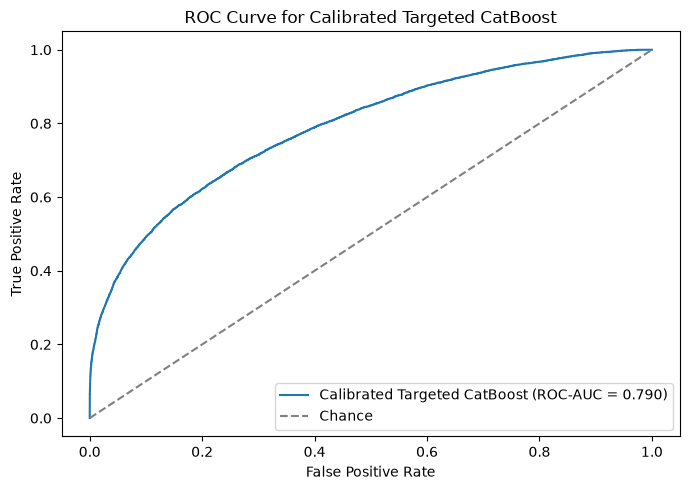

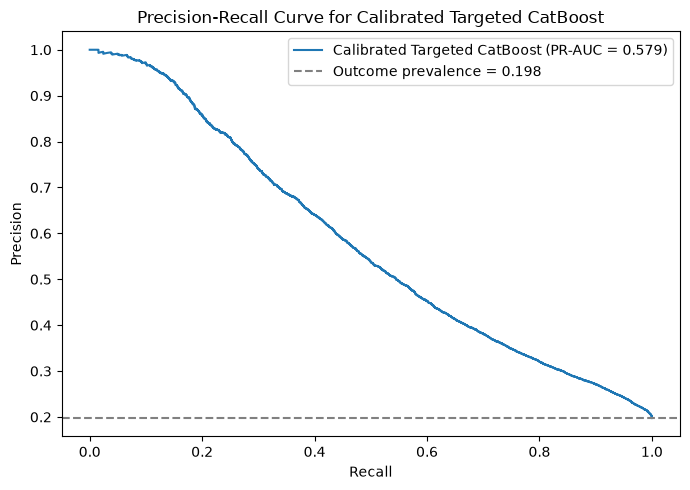

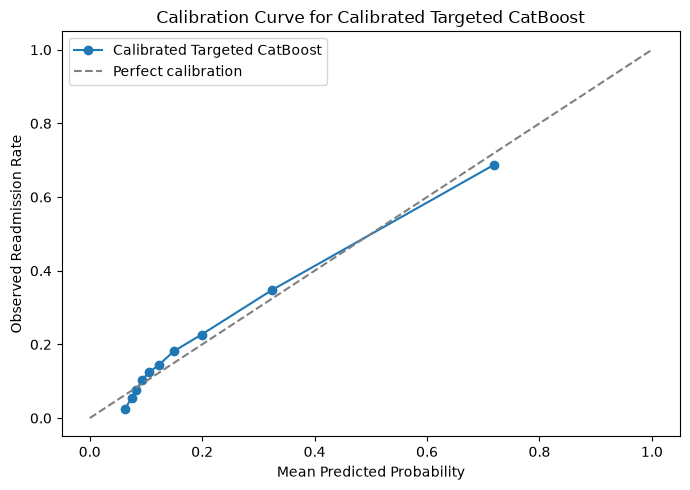

Calibrated Targeted CatBoost official threshold: 0.25 ( validation balanced precision-recall threshold after calibration )
Calibrated Targeted CatBoost performance:
                                               model  \
0     Calibrated Targeted CatBoost default threshold   
1  Calibrated Targeted CatBoost official balanced...   
2  Calibrated Targeted CatBoost validation Youden...   
3  Calibrated Targeted CatBoost balanced precisio...   
4  Calibrated Targeted CatBoost exploratory held-...   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.8405             0.6467   
1                   official       0.25    0.8136             0.6991   
2         recall sensitivity       0.18    0.7685             0.7104   
3  balanced precision-recall       0.25    0.8136             0.6991   
4                exploratory       0.25    0.8136             0.6991   

   precision  recall_sensitivity  specificity  f1_score  roc_auc 

In [32]:
#train and save calibrated targeted catboost outputs
calibrated_targeted_catboost_model = None
calibrated_targeted_catboost_train_probability = None
calibrated_targeted_catboost_test_probability = None
calibrated_targeted_catboost_performance_df = pd.DataFrame()

if catboost_available and "final_targeted_catboost_config" in globals():
    #copy the targeted catboost config before calibration
    calibrated_catboost_base_config = final_targeted_catboost_config.copy()
    calibrated_catboost_base_config.pop("config_name", None)

    #fit the base catboost model on screening train data
    calibrated_catboost_base_model = CatBoostClassifier(**calibrated_catboost_base_config,
        loss_function="Logloss", eval_metric="PRAUC", bootstrap_type="Bernoulli",
        class_weights=[1.0, targeted_catboost_positive_class_weight],
        random_seed=42, verbose=False, allow_writing_files=False, thread_count=-1)

    print("Training base targeted CatBoost model for sigmoid calibration...")
    calibrated_catboost_training_start = time.perf_counter()
    calibrated_catboost_base_model.fit(X_screen_train, y_screen_train, verbose=False)

    #learn sigmoid calibration on the held-out screening validation set
    calibrated_targeted_catboost_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(calibrated_catboost_base_model), method="sigmoid")
    calibrated_targeted_catboost_model.fit(X_screen_val, y_screen_val)

    calibrated_targeted_catboost_training_time_seconds = time.perf_counter() - calibrated_catboost_training_start
    print("Calibrated targeted CatBoost training complete.")

    #create validation probabilities for threshold selection
    calibrated_targeted_catboost_validation_probability = calibrated_targeted_catboost_model.predict_proba(X_screen_val)[:, 1]

    #score the full training matrix for comparison metrics
    calibrated_targeted_catboost_train_prediction_start = time.perf_counter()
    calibrated_targeted_catboost_train_probability = calibrated_targeted_catboost_model.predict_proba(X_train)[:, 1]
    calibrated_targeted_catboost_train_inference_time_seconds = time.perf_counter() - calibrated_targeted_catboost_train_prediction_start

    #score the held-out test matrix for final reporting
    calibrated_targeted_catboost_test_prediction_start = time.perf_counter()
    calibrated_targeted_catboost_test_probability = calibrated_targeted_catboost_model.predict_proba(X_test)[:, 1]
    calibrated_targeted_catboost_test_inference_time_seconds = time.perf_counter() - calibrated_targeted_catboost_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, calibrated_targeted_catboost_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, calibrated_targeted_catboost_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, calibrated_targeted_catboost_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, calibrated_targeted_catboost_test_probability), 4))
    print("Training plus calibration time in seconds:", round(calibrated_targeted_catboost_training_time_seconds, 2))

    #save calibrated metrics, thresholds, calibration bins, predictions, and importance
    calibrated_targeted_catboost_performance_df, calibrated_targeted_catboost_threshold_summary_df, \
        calibrated_targeted_catboost_test_threshold_comparison_df, calibrated_targeted_catboost_calibration_df, \
        calibrated_targeted_catboost_importance_df, calibrated_targeted_catboost_predictions = save_calibrated_boosting_outputs(
            "Calibrated Targeted CatBoost", "t3_4_calibrated_targeted_catboost",
            calibrated_targeted_catboost_output_path, calibrated_targeted_catboost_model,
            calibrated_targeted_catboost_validation_probability, calibrated_targeted_catboost_train_probability,
            calibrated_targeted_catboost_test_probability, calibrated_targeted_catboost_training_time_seconds,
            calibrated_targeted_catboost_train_inference_time_seconds,
            calibrated_targeted_catboost_test_inference_time_seconds,
            calibrated_catboost_base_model.get_feature_importance())
else:
    print("Calibrated targeted CatBoost was skipped because the targeted CatBoost model configuration is unavailable.")

Training base targeted LightGBM model for sigmoid calibration...
Calibrated targeted LightGBM training complete.
Training ROC-AUC: 0.8646
Test ROC-AUC: 0.7905
Training PR-AUC: 0.7023
Test PR-AUC: 0.5825
Training plus calibration time in seconds: 26.03


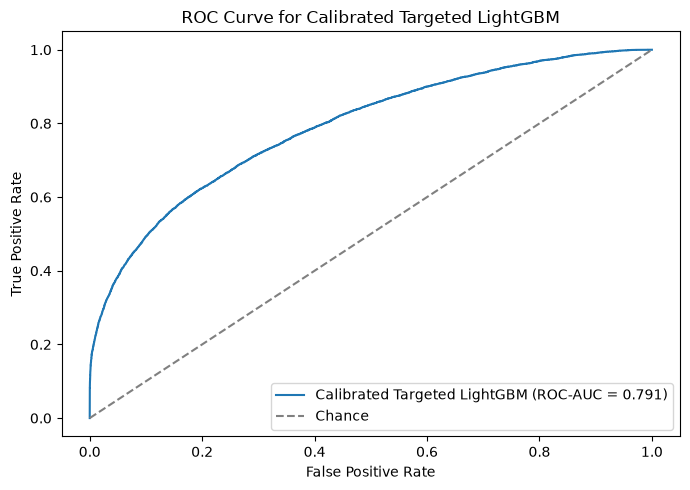

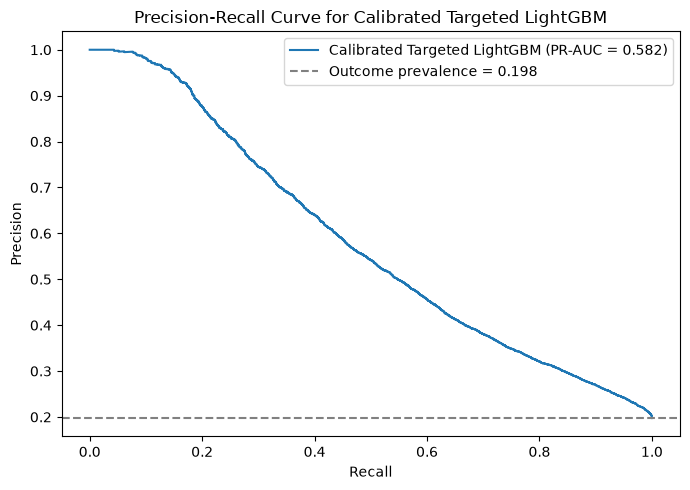

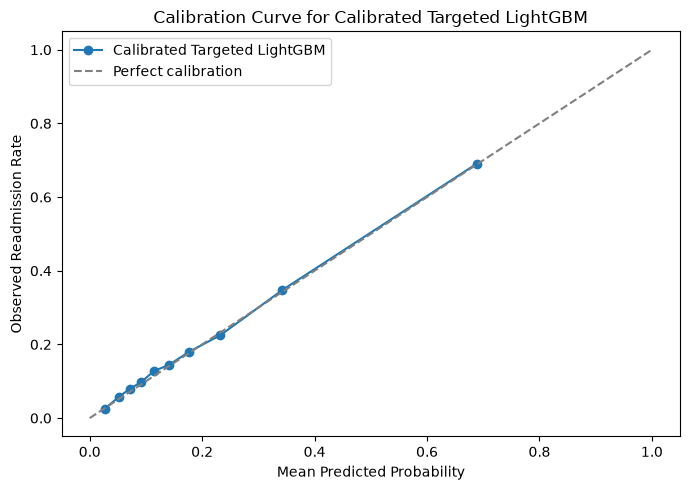

Calibrated Targeted LightGBM official threshold: 0.28 ( validation balanced precision-recall threshold after calibration )
Calibrated Targeted LightGBM performance:
                                               model  \
0     Calibrated Targeted LightGBM default threshold   
1  Calibrated Targeted LightGBM official balanced...   
2  Calibrated Targeted LightGBM validation Youden...   
3  Calibrated Targeted LightGBM balanced precisio...   
4  Calibrated Targeted LightGBM exploratory held-...   

              threshold_role  threshold  accuracy  balanced_accuracy  \
0                    default       0.50    0.8420             0.6414   
1                   official       0.28    0.8135             0.7004   
2         recall sensitivity       0.25    0.7986             0.7089   
3  balanced precision-recall       0.28    0.8135             0.7004   
4                exploratory       0.25    0.7986             0.7089   

   precision  recall_sensitivity  specificity  f1_score  roc_auc 

In [33]:
#train and save calibrated targeted lightgbm outputs
calibrated_targeted_lightgbm_model = None
calibrated_targeted_lightgbm_train_probability = None
calibrated_targeted_lightgbm_test_probability = None
calibrated_targeted_lightgbm_performance_df = pd.DataFrame()

if lightgbm_available and "final_targeted_lightgbm_config" in globals():
    #copy the targeted lightgbm config before calibration
    calibrated_lightgbm_base_config = final_targeted_lightgbm_config.copy()
    calibrated_lightgbm_base_config.pop("config_name", None)

    #fit the base lightgbm model on screening train data
    calibrated_lightgbm_base_model = LGBMClassifier(**calibrated_lightgbm_base_config, objective="binary",
        class_weight={0: 1.0, 1: targeted_lightgbm_scale_pos_weight}, random_state=42,
        n_jobs=-1, verbosity=-1, force_col_wise=True)

    print("Training base targeted LightGBM model for sigmoid calibration...")
    calibrated_lightgbm_training_start = time.perf_counter()
    calibrated_lightgbm_base_model.fit(X_screen_train, y_screen_train)
    #learn sigmoid calibration on the held-out screening validation set
    calibrated_targeted_lightgbm_model = CalibratedClassifierCV(
        estimator=FrozenEstimator(calibrated_lightgbm_base_model), method="sigmoid")
    calibrated_targeted_lightgbm_model.fit(X_screen_val, y_screen_val)
    calibrated_targeted_lightgbm_training_time_seconds = time.perf_counter() - calibrated_lightgbm_training_start
    print("Calibrated targeted LightGBM training complete.")

    #create validation probabilities for threshold selection
    calibrated_targeted_lightgbm_validation_probability = calibrated_targeted_lightgbm_model.predict_proba(X_screen_val)[:, 1]

    #score the full training matrix for comparison metrics
    calibrated_targeted_lightgbm_train_prediction_start = time.perf_counter()
    calibrated_targeted_lightgbm_train_probability = calibrated_targeted_lightgbm_model.predict_proba(X_train)[:, 1]
    calibrated_targeted_lightgbm_train_inference_time_seconds = time.perf_counter() - calibrated_targeted_lightgbm_train_prediction_start

    #score the held-out test matrix for final reporting
    calibrated_targeted_lightgbm_test_prediction_start = time.perf_counter()
    calibrated_targeted_lightgbm_test_probability = calibrated_targeted_lightgbm_model.predict_proba(X_test)[:, 1]
    calibrated_targeted_lightgbm_test_inference_time_seconds = time.perf_counter() - calibrated_targeted_lightgbm_test_prediction_start

    print("Training ROC-AUC:", round(roc_auc_score(y_train, calibrated_targeted_lightgbm_train_probability), 4))
    print("Test ROC-AUC:", round(roc_auc_score(y_test, calibrated_targeted_lightgbm_test_probability), 4))
    print("Training PR-AUC:", round(average_precision_score(y_train, calibrated_targeted_lightgbm_train_probability), 4))
    print("Test PR-AUC:", round(average_precision_score(y_test, calibrated_targeted_lightgbm_test_probability), 4))
    print("Training plus calibration time in seconds:", round(calibrated_targeted_lightgbm_training_time_seconds, 2))

    #save calibrated metrics, thresholds, calibration bins, predictions, and importance
    calibrated_targeted_lightgbm_performance_df, calibrated_targeted_lightgbm_threshold_summary_df, \
        calibrated_targeted_lightgbm_test_threshold_comparison_df, calibrated_targeted_lightgbm_calibration_df, \
        calibrated_targeted_lightgbm_importance_df, calibrated_targeted_lightgbm_predictions = save_calibrated_boosting_outputs(
            "Calibrated Targeted LightGBM", "t3_4_calibrated_targeted_lightgbm",
            calibrated_targeted_lightgbm_output_path, calibrated_targeted_lightgbm_model,
            calibrated_targeted_lightgbm_validation_probability, calibrated_targeted_lightgbm_train_probability,
            calibrated_targeted_lightgbm_test_probability, calibrated_targeted_lightgbm_training_time_seconds,
            calibrated_targeted_lightgbm_train_inference_time_seconds,
            calibrated_targeted_lightgbm_test_inference_time_seconds,
            calibrated_lightgbm_base_model.feature_importances_)
else:
    print("Calibrated targeted LightGBM was skipped because the targeted LightGBM model configuration is unavailable.")

**Combined gradient boosting discrimination curves**

ROC and precision-recall curves are combined into one figure for all available gradient boosting models. The precision-recall plot is especially useful here because the positive class is less common and PR-AUC is the main ranking metric.


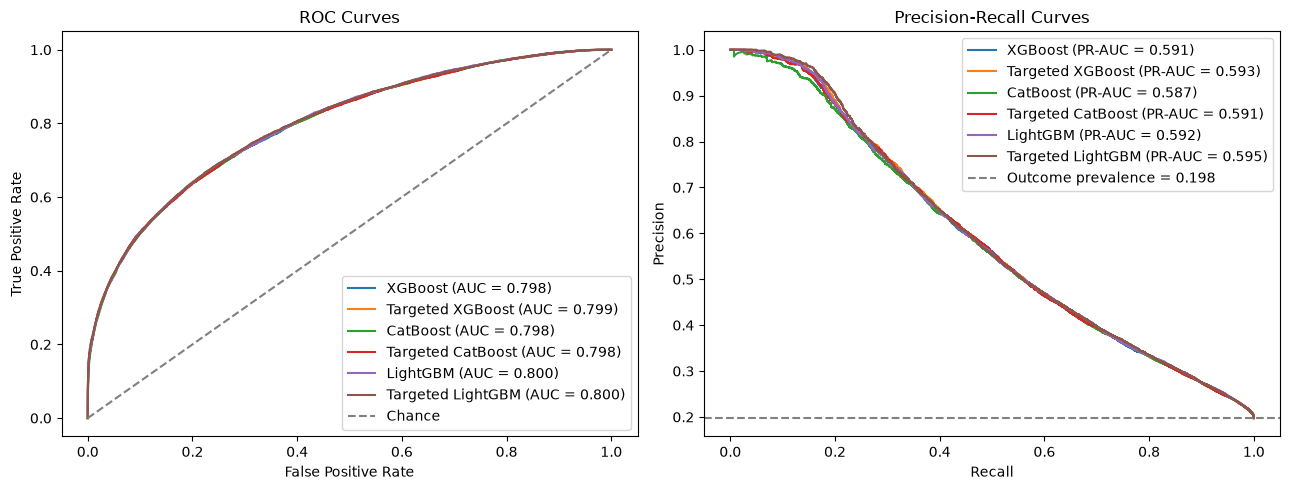

Saved combined gradient boosting discrimination curves to:
/scratch/DissProject/outputs/WP3_4/t3_4_gradient_boosting_combined_discrimination_curves.png


In [34]:
#create combined roc and precision-recall curves for available gradient boosting models, collect every available gradient boosting prediction vector
curve_models = []
if xgboost_available and xgboost_test_probability is not None:
    curve_models.append(("XGBoost", xgboost_test_probability))
if 'targeted_xgboost_test_probability' in globals() and targeted_xgboost_test_probability is not None:
    curve_models.append(("Targeted XGBoost", targeted_xgboost_test_probability))
if catboost_available and catboost_test_probability is not None:
    curve_models.append(("CatBoost", catboost_test_probability))
if 'targeted_catboost_test_probability' in globals() and targeted_catboost_test_probability is not None:
    curve_models.append(("Targeted CatBoost", targeted_catboost_test_probability))
if lightgbm_available and lightgbm_test_probability is not None:
    curve_models.append(("LightGBM", lightgbm_test_probability))
if 'targeted_lightgbm_test_probability' in globals() and targeted_lightgbm_test_probability is not None:
    curve_models.append(("Targeted LightGBM", targeted_lightgbm_test_probability))

#plot only when at least one model has completed
if curve_models:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    #draw roc and precision-recall lines for each available model
    for model_label, y_probability in curve_models:
        fpr, tpr, _ = roc_curve(y_test, y_probability)
        roc_auc = roc_auc_score(y_test, y_probability)
        precision, recall, _ = precision_recall_curve(y_test, y_probability)
        pr_auc = average_precision_score(y_test, y_probability)
        axes[0].plot(fpr, tpr, label=f"{model_label} (AUC = {roc_auc:.3f})")
        axes[1].plot(recall, precision, label=f"{model_label} (PR-AUC = {pr_auc:.3f})")

    #add visual references for chance performance and outcome prevalence
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curves")
    axes[0].legend(loc="lower right")

    axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label=f"Outcome prevalence = {y_test.mean():.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curves")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    #save the combined curve figure for reporting
    combined_gradient_boosting_curve_file = wp3_4_output_path / "t3_4_gradient_boosting_combined_discrimination_curves.png"
    plt.savefig(combined_gradient_boosting_curve_file, dpi=300)
    plt.show()
    print("Saved combined gradient boosting discrimination curves to:")
    print(combined_gradient_boosting_curve_file)
else:
    print("No gradient boosting model predictions were available for combined curves.")

**Gradient boosting model comparison**

Available XGBoost, CatBoost, LightGBM, targeted, and calibrated performance tables are combined into a single comparison table. This gives a compact view of which gradient boosting variant performed best before WP3.6 combines all model families.


In [35]:
#combine available gradient boosting model performance tables, collect performance tables from all wp3.4 model folders
comparison_frames = []
for frame_name, model_family in [("xgboost_performance_df", "XGBoost"),
    ("targeted_xgboost_performance_df", "Targeted XGBoost"),
    ("calibrated_targeted_xgboost_performance_df", "Calibrated Targeted XGBoost"),
    ("catboost_performance_df", "CatBoost"),
    ("targeted_catboost_performance_df", "Targeted CatBoost"),
    ("calibrated_targeted_catboost_performance_df", "Calibrated Targeted CatBoost"),
    ("lightgbm_performance_df", "LightGBM"),
    ("targeted_lightgbm_performance_df", "Targeted LightGBM"),
    ("calibrated_targeted_lightgbm_performance_df", "Calibrated Targeted LightGBM")]:
    if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
        temp = globals()[frame_name].copy()
        if temp.empty or "model" not in temp.columns:
            print("Skipping", frame_name, "because it has no saved model-performance rows.")
            continue
        temp.insert(0, "model_family", model_family)
        if "threshold_role" not in temp.columns:
            temp.insert(2, "threshold_role", np.select([temp["model"].str.contains("held-out", case=False, na=False),
                 temp["model"].str.contains("Youden", case=False, na=False),
                 temp["model"].str.contains("F1", case=False, na=False),
                 temp["model"].str.contains("default", case=False, na=False)],
                ["exploratory", "recall sensitivity", "official", "default"],
                default="other"))
        comparison_frames.append(temp)

#combine available model rows into one wp3.4 comparison table
if comparison_frames:
    gradient_boosting_comparison_df = pd.concat(comparison_frames, ignore_index=True)
    gradient_boosting_comparison_df["official_threshold"] = gradient_boosting_comparison_df["threshold_role"].eq("official")
    gradient_boosting_comparison_df.to_csv(wp3_4_output_path / "t3_4_gradient_boosting_model_comparison.csv", index=False)

    official_gradient_boosting_comparison_df = gradient_boosting_comparison_df[
        gradient_boosting_comparison_df["official_threshold"]].copy()
    official_gradient_boosting_comparison_df.to_csv(
        wp3_4_output_path / "t3_4_gradient_boosting_official_threshold_comparison.csv",
        index=False)

    print("Gradient boosting model comparison:")
    print(gradient_boosting_comparison_df.round(4))
    print("\nOfficial training-selected threshold comparison:")
    print(official_gradient_boosting_comparison_df.round(4))
else:
    gradient_boosting_comparison_df = pd.DataFrame()
    official_gradient_boosting_comparison_df = pd.DataFrame()
    print("No trained gradient boosting models were available for comparison.")

Gradient boosting model comparison:
                    model_family  \
0                        XGBoost   
1                        XGBoost   
2                        XGBoost   
3                        XGBoost   
4                        XGBoost   
5               Targeted XGBoost   
6               Targeted XGBoost   
7               Targeted XGBoost   
8               Targeted XGBoost   
9               Targeted XGBoost   
10   Calibrated Targeted XGBoost   
11   Calibrated Targeted XGBoost   
12   Calibrated Targeted XGBoost   
13   Calibrated Targeted XGBoost   
14   Calibrated Targeted XGBoost   
15                      CatBoost   
16                      CatBoost   
17                      CatBoost   
18                      CatBoost   
19                      CatBoost   
20             Targeted CatBoost   
21             Targeted CatBoost   
22             Targeted CatBoost   
23             Targeted CatBoost   
24             Targeted CatBoost   
25  Calibrated Targeted CatB

**Overall model performance comparison**

The final comparison table combines the reference baseline, logistic regression models, Random Forest models, XGBoost, CatBoost and LightGBM models into one output. This makes it easier to compare threshold choice, confusion matrix counts, discrimination, calibration and runtime across all admission-level models.


In [36]:
#combine all model performance outputs from wp3.2, wp3.3 and wp3.4 into one comparison table
current_path = Path.cwd().resolve()
project_path = None
for candidate_path in [current_path] + list(current_path.parents):
    if (candidate_path / "code").exists():
        project_path = candidate_path
        break
if project_path is None:
    project_path = Path("/Users/ahthini/Desktop/DissProject")
output_path = project_path / "outputs"
wp3_2_comparison_path = output_path / "WP3_2"
wp3_3_comparison_path = output_path / "WP3_3"
wp3_4_comparison_path = wp3_4_output_path

performance_sources = [{"work_package": "WP3.2", "model_family": "Logistic regression", "file_path": wp3_2_comparison_path / "logistic_regression" / "t3_2_logistic_regression_performance.csv"},
    {"work_package": "WP3.2", "model_family": "Tuned logistic regression", "file_path": wp3_2_comparison_path / "tuned_logistic_regression" / "t3_2_tuned_logistic_regression_performance.csv"},
    {"work_package": "WP3.3", "model_family": "Random Forest", "file_path": wp3_3_comparison_path / "random_forest" / "t3_3_random_forest_performance.csv"},
    {"work_package": "WP3.3", "model_family": "Regularised Random Forest", "file_path": wp3_3_comparison_path / "regularised_random_forest" / "t3_3_regularised_random_forest_performance.csv"},
    {"work_package": "WP3.4", "model_family": "XGBoost", "file_path": wp3_4_comparison_path / "xgboost" / "t3_4_xgboost_performance.csv"},
    {"work_package": "WP3.4", "model_family": "Targeted XGBoost", "file_path": wp3_4_comparison_path / "xgboost_targeted" / "t3_4_xgboost_targeted_performance.csv"},
    {"work_package": "WP3.4", "model_family": "Calibrated Targeted XGBoost", "file_path": wp3_4_comparison_path / "calibrated_targeted_xgboost" / "t3_4_calibrated_targeted_xgboost_performance.csv"},
    {"work_package": "WP3.4", "model_family": "CatBoost", "file_path": wp3_4_comparison_path / "catboost" / "t3_4_catboost_performance.csv"},
    {"work_package": "WP3.4", "model_family": "Targeted CatBoost", "file_path": wp3_4_comparison_path / "catboost_targeted" / "t3_4_catboost_targeted_performance.csv"},
    {"work_package": "WP3.4", "model_family": "Calibrated Targeted CatBoost", "file_path": wp3_4_comparison_path / "calibrated_targeted_catboost" / "t3_4_calibrated_targeted_catboost_performance.csv"},
    {"work_package": "WP3.4", "model_family": "LightGBM", "file_path": wp3_4_comparison_path / "lightgbm" / "t3_4_lightgbm_performance.csv"},
    {"work_package": "WP3.4", "model_family": "Targeted LightGBM", "file_path": wp3_4_comparison_path / "lightgbm_targeted" / "t3_4_lightgbm_targeted_performance.csv"},
    {"work_package": "WP3.4", "model_family": "Calibrated Targeted LightGBM", "file_path": wp3_4_comparison_path / "calibrated_targeted_lightgbm" / "t3_4_calibrated_targeted_lightgbm_performance.csv"}]

print("All-model comparison input variant:", wp3_input_variant)
print("WP3.2 comparison folder:", wp3_2_comparison_path)
print("WP3.3 comparison folder:", wp3_3_comparison_path)
print("WP3.4 comparison folder:", wp3_4_comparison_path)

#define canonical model family
def canonical_model_family(source_family, model_name):
    model_text = str(model_name).lower()
    if "reference" in model_text:
        return "Reference baseline"
    return source_family

#infer threshold role
def infer_threshold_role(row, model_family):
    if "threshold_role" in row.index and pd.notna(row.get("threshold_role")):
        role = str(row.get("threshold_role")).strip()
        if "balanced precision" in role.lower() or "precision-recall" in role.lower() or "precision recall" in role.lower():
            return "balanced precision-recall"
        if role:
            return role

    model_text = str(row.get("model", "")).lower()
    threshold = row.get("threshold", np.nan)
    threshold = round(float(threshold), 2) if pd.notna(threshold) else np.nan

    if "reference" in model_text:
        return "reference"
    if "held-out" in model_text or "exploratory" in model_text:
        return "exploratory"
    if "recall-oriented" in model_text:
        return "recall-oriented"
    if "youden" in model_text:
        return "training Youden"
    if "training f1" in model_text:
        return "training F1"
    if "default" in model_text or np.isclose(threshold, 0.50):
        return "default"

    #older wp3.2 and wp3.3 outputs did not always store threshold role, so infer from the known saved thresholds
    if model_family == "Logistic regression":
        if np.isclose(threshold, 0.53):
            return "training F1"
        if np.isclose(threshold, 0.51):
            return "training Youden"
    if model_family == "Tuned logistic regression":
        if np.isclose(threshold, 0.52):
            return "training F1"
        if np.isclose(threshold, 0.51):
            return "training Youden"
    if model_family == "Random Forest":
        if np.isclose(threshold, 0.49):
            return "training F1"
        if np.isclose(threshold, 0.46):
            return "training Youden"
        if np.isclose(threshold, 0.30):
            return "recall-oriented"
        if np.isclose(threshold, 0.29):
            return "exploratory held-out F1"
    if model_family == "Regularised Random Forest":
        if np.isclose(threshold, 0.49):
            return "training F1"
        if np.isclose(threshold, 0.42):
            return "training Youden"
        if np.isclose(threshold, 0.30):
            return "recall-oriented"
        if np.isclose(threshold, 0.40):
            return "exploratory held-out F1"

    return "selected"

model_performance_tables = []
missing_performance_files = []

for source in performance_sources:
    file_path = source["file_path"]
    if not file_path.exists():
        missing_performance_files.append(file_path)
        continue

    model_df = pd.read_csv(file_path)
    model_df["work_package"] = source["work_package"]
    model_df["source_file"] = file_path.name
    model_df["model_family"] = [canonical_model_family(source["model_family"], value) for value in model_df["model"]]
    model_df["threshold_role"] = model_df.apply(lambda row: infer_threshold_role(row, row["model_family"]), axis=1)
    model_performance_tables.append(model_df)

if model_performance_tables:
    all_model_performance_comparison_df = pd.concat(model_performance_tables, ignore_index=True)
else:
    all_model_performance_comparison_df = pd.DataFrame()
    print("No model performance files were available for the all-model comparison yet.")

comparison_columns = ["work_package", "model_family", "model", "threshold_role", "threshold",
    "true_positives", "false_negatives", "true_negatives", "false_positives", "accuracy",
    "balanced_accuracy", "precision", "recall_sensitivity", "specificity", "f1_score", "roc_auc",
    "pr_auc_average_precision", "brier_score", "training_time_seconds", "train_inference_time_seconds",
    "test_inference_time_seconds", "test_inference_time_per_admission_ms", "source_file"]
comparison_columns = [column for column in comparison_columns if column in all_model_performance_comparison_df.columns]
all_model_performance_comparison_df = all_model_performance_comparison_df[comparison_columns].copy()

numeric_columns = all_model_performance_comparison_df.select_dtypes(include=["number"]).columns
all_model_performance_comparison_df[numeric_columns] = all_model_performance_comparison_df[numeric_columns].round(4)

#recommended rows exclude explicitly held-out threshold sweeps, then choose the strongest f1 row per model family
recommended_candidates = all_model_performance_comparison_df[
    ~all_model_performance_comparison_df["threshold_role"].str.lower().str.contains("held-out|exploratory", na=False)].copy()
recommended_model_performance_comparison_df = (recommended_candidates
    .sort_values(["model_family", "f1_score", "balanced_accuracy", "pr_auc_average_precision", "roc_auc"], 
    ascending=[True, False, False, False, False])
    .drop_duplicates(subset=["model_family"], keep="first")
    .sort_values(["pr_auc_average_precision", "roc_auc", "f1_score"], ascending=False)
    .reset_index(drop=True))

#default rows are useful for direct comparison at the conventional 0.50 threshold
reference_or_default_model_comparison_df = all_model_performance_comparison_df[
    all_model_performance_comparison_df["threshold_role"].isin(["reference", "default"])
].copy().reset_index(drop=True)

source_file_df = pd.DataFrame(performance_sources)
source_file_df["file_path"] = source_file_df["file_path"].astype(str)
source_file_df["file_found"] = source_file_df["file_path"].apply(lambda value: Path(value).exists())

all_model_csv = wp3_4_output_path / "t3_4_all_model_performance_comparison.csv"
recommended_model_csv = wp3_4_output_path / "t3_4_recommended_model_performance_comparison.csv"
model_workbook = wp3_4_output_path / "t3_4_all_model_performance_comparison.xlsx"

all_model_performance_comparison_df.to_csv(all_model_csv, index=False)
recommended_model_performance_comparison_df.to_csv(recommended_model_csv, index=False)

#write selected comparison tables into one workbook
with pd.ExcelWriter(model_workbook) as writer:
    recommended_model_performance_comparison_df.to_excel(writer, sheet_name="recommended_rows", index=False)
    all_model_performance_comparison_df.to_excel(writer, sheet_name="all_thresholds", index=False)
    reference_or_default_model_comparison_df.to_excel(writer, sheet_name="reference_or_default", index=False)
    source_file_df.to_excel(writer, sheet_name="data_sources", index=False)

print("Recommended model performance comparison:")
print(recommended_model_performance_comparison_df)
print()
print("Saved all-model comparison files to:")
print(all_model_csv)
print(recommended_model_csv)
print(model_workbook)

if missing_performance_files:
    print()
    print("Missing performance files:")
    for file_path in missing_performance_files:
        print(file_path)

All-model comparison input variant: shap_guided_reduced_feature_set
WP3.2 comparison folder: /scratch/DissProject/outputs/WP3_2
WP3.3 comparison folder: /scratch/DissProject/outputs/WP3_3
WP3.4 comparison folder: /scratch/DissProject/outputs/WP3_4
Recommended model performance comparison:
   work_package                  model_family  \
0         WP3.4             Targeted LightGBM   
1         WP3.4              Targeted XGBoost   
2         WP3.4                      LightGBM   
3         WP3.4                       XGBoost   
4         WP3.4             Targeted CatBoost   
5         WP3.4                      CatBoost   
6         WP3.4   Calibrated Targeted XGBoost   
7         WP3.4  Calibrated Targeted LightGBM   
8         WP3.3                 Random Forest   
9         WP3.3     Regularised Random Forest   
10        WP3.4  Calibrated Targeted CatBoost   
11        WP3.2     Tuned logistic regression   
12        WP3.2           Logistic regression   
13        WP3.2         

**Training curve diagnostics**

The final gradient boosting training cells above record learning-curve metrics while the models train. This section only saves and plots those recorded curves, so it does not refit any models or add extra runtime beyond plotting.


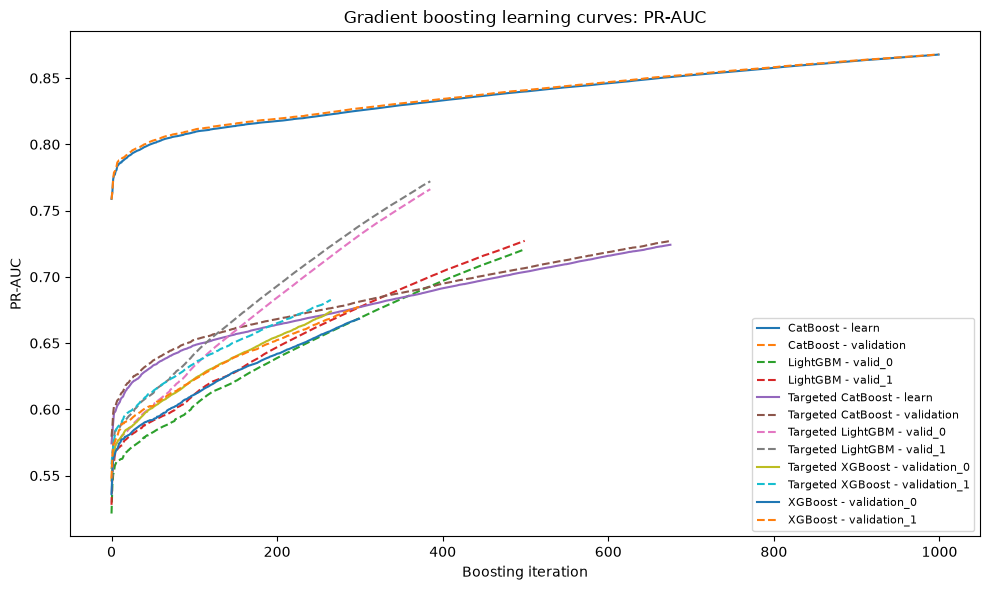

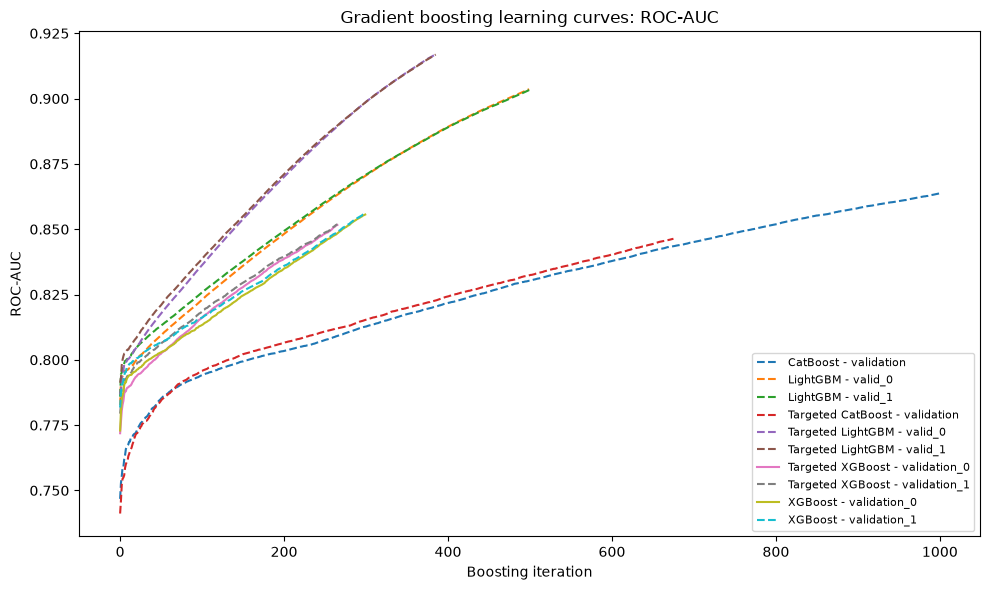

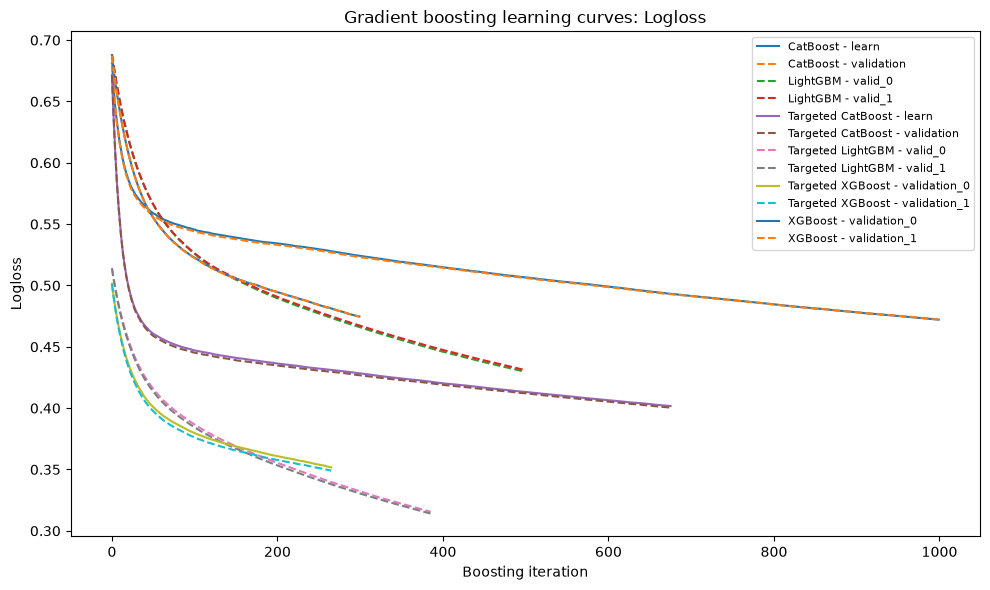

Saved recorded training curves to:
/scratch/DissProject/outputs/WP3_4/training_curve_diagnostics
Training curve rows: 23796


In [37]:
#save learning curves captured during the actual final gradient boosting fits
#create a folder for learning-curve diagnostics
training_curve_output_path = wp3_4_output_path / "training_curve_diagnostics"
training_curve_output_path.mkdir(parents=True, exist_ok=True)

#flatten each library eval history into rows
training_curve_rows = []

#define append training curve rows
def append_training_curve_rows(model_family, evals_result):
    for dataset_name, metric_dict in evals_result.items():
        for metric_name, metric_values in metric_dict.items():
            for iteration, metric_value in enumerate(metric_values):
                training_curve_rows.append({"model_family": model_family,
                    "dataset": dataset_name,
                    "metric": metric_name,
                    "iteration": iteration,
                    "metric_value": metric_value})

#pull curve histories captured during final model fitting
recorded_curve_sources = globals().get("wp3_4_training_curve_sources", {})
for model_family, evals_result in recorded_curve_sources.items():
    append_training_curve_rows(model_family, evals_result)

#save plots only if final model cells recorded histories
if training_curve_rows:
    training_curve_df = pd.DataFrame(training_curve_rows)
    training_curve_df.to_csv(training_curve_output_path / "t3_4_gradient_boosting_training_curves.csv", index=False)

    training_curve_summary_df = pd.DataFrame(globals().get("wp3_4_training_curve_model_summaries", []))
    training_curve_summary_df.to_csv(training_curve_output_path / "t3_4_gradient_boosting_training_curve_model_configs.csv", index=False)

    #standardise metric names across xgboost, catboost, and lightgbm
    metric_label_map = {"logloss": "Logloss", "Logloss": "Logloss", "binary_logloss": "Logloss",
        "aucpr": "PR-AUC", "PRAUC": "PR-AUC", "average_precision": "PR-AUC",
        "auc": "ROC-AUC", "AUC": "ROC-AUC"}
    training_curve_df["metric_label"] = training_curve_df["metric"].map(metric_label_map).fillna(training_curve_df["metric"])

    #plot each available learning metric separately
    for metric_label in ["PR-AUC", "ROC-AUC", "Logloss"]:
        metric_df = training_curve_df.loc[training_curve_df["metric_label"] == metric_label].copy()
        if metric_df.empty:
            continue
        plt.figure(figsize=(10, 6))
        for (model_family, dataset_name), group_df in metric_df.groupby(["model_family", "dataset"]):
            line_style = "-" if str(dataset_name).lower() in ["validation_0", "learn", "training"] else "--"
            plt.plot(group_df["iteration"], group_df["metric_value"], linestyle=line_style,
                label=f"{model_family} - {dataset_name}")
        plt.xlabel("Boosting iteration")
        plt.ylabel(metric_label)
        plt.title(f"Gradient boosting learning curves: {metric_label}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        filename_metric = metric_label.lower().replace("-", "_").replace(" ", "_")
        plt.savefig(training_curve_output_path / f"t3_4_gradient_boosting_training_curve_{filename_metric}.png", dpi=300)
        plt.show()

    print("Saved recorded training curves to:")
    print(training_curve_output_path)
    print("Training curve rows:", len(training_curve_df))
else:
    print("No recorded training curves are available. Run the final gradient boosting training cells above first.")


**Final WP3.4 output summary**

This final check confirms the files created for the gradient boosting models.




In [38]:
#list all wp3.4 files created by this notebook
#scan the wp3.4 output folder after the run
created_files = sorted(wp3_4_output_path.glob("**/t3_4_*"))
summary_df = pd.DataFrame({"output_folder": [path.parent.name for path in created_files],
    "output_file": [path.name for path in created_files],
    "file_size_mb": [round(path.stat().st_size / (1024 ** 2), 3) for path in created_files]})
summary_df.to_csv(wp3_4_output_path / "t3_4_output_file_summary.csv", index=False)

print("WP3.4 output files:")
print(summary_df)
print("\nWP3.4 complete. Outputs saved to:")
print(wp3_4_output_path)

WP3.4 output files:
                    output_folder  \
0    calibrated_targeted_catboost   
1    calibrated_targeted_catboost   
2    calibrated_targeted_catboost   
3    calibrated_targeted_catboost   
4    calibrated_targeted_catboost   
..                            ...   
138              xgboost_targeted   
139              xgboost_targeted   
140              xgboost_targeted   
141              xgboost_targeted   
142              xgboost_targeted   

                                           output_file  file_size_mb  
0    t3_4_calibrated_targeted_catboost_calibration_...         0.147  
1    t3_4_calibrated_targeted_catboost_calibration_...         0.000  
2    t3_4_calibrated_targeted_catboost_confusion_ma...         0.000  
3    t3_4_calibrated_targeted_catboost_feature_impo...         0.050  
4       t3_4_calibrated_targeted_catboost_model.joblib         2.784  
..                                                 ...           ...  
138                  t3_4_xgboost_targ

**CSV Table Workbook**

This cell keeps the individual CSV files and also creates one Excel workbook where each CSV table is available as a separate sheet. The workbook is for easier review and sharing; the CSV files remain the primary machine-readable outputs.


In [39]:
#compile csv tables into one workbook while preserving the original csv files
#find available output folders to archive
possible_output_roots = []
for output_name in ['wp3_4_output_path']:
    if output_name in globals():
        output_root = globals()[output_name]
        if isinstance(output_root, Path) and output_root.exists() and output_root not in possible_output_roots:
            possible_output_roots.append(output_root)

#skip workbook creation if the notebook has not produced outputs
if not possible_output_roots:
    print("no wp3 output roots were available for workbook compilation")
else:
    primary_output_root = possible_output_roots[0]
    workbook_path = primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook.xlsx"
    #collect csv tables from the output folder tree
    csv_paths = []
    for output_root in possible_output_roots:
        csv_paths.extend(sorted(path for path in output_root.rglob("*.csv") if path.is_file()))
    csv_paths = sorted(dict.fromkeys(csv_paths))

    #make excel-safe sheet names from csv paths
    def make_sheet_name(csv_path, used_names):
        relative_name = csv_path.relative_to(primary_output_root.parent).with_suffix("").as_posix()
        relative_name = re.sub(r"[^0-9a-zA-Z]+", "_", relative_name).strip("_").lower()
        parts = [part for part in relative_name.split("_") if part not in ["outputs", primary_output_root.name.lower(), "csv", "tables"]]
        base_name = "_".join(parts[-4:]) if parts else csv_path.stem.lower()
        base_name = base_name[:31] or "table"
        sheet_name = base_name
        counter = 1
        while sheet_name in used_names:
            suffix = f"_{counter}"
            sheet_name = base_name[:31 - len(suffix)] + suffix
            counter += 1
        used_names.add(sheet_name)
        return sheet_name

    workbook_index_rows = []
    used_sheet_names = set()
    max_excel_rows = 200000
    #copy csv tables into a single workbook for easier browsing
    with pd.ExcelWriter(workbook_path) as writer:
        for csv_path in csv_paths:
            try:
                table_df = pd.read_csv(csv_path)
            except Exception as error:
                workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": "", "rows": np.nan,
                    "columns": np.nan, "rows_written": 0, "note": f"read_failed: {error}"})
                continue
            sheet_name = make_sheet_name(csv_path, used_sheet_names)
            #cap rows per sheet to avoid oversized excel files
            rows_written = min(len(table_df), max_excel_rows)
            table_df.head(max_excel_rows).to_excel(writer, sheet_name=sheet_name, index=False)
            workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": sheet_name, "rows": len(table_df),
                "columns": table_df.shape[1], "rows_written": rows_written,
                "note": "truncated_for_excel" if len(table_df) > max_excel_rows else "complete"})
        workbook_index_df = pd.DataFrame(workbook_index_rows)
        workbook_index_df.to_excel(writer, sheet_name="workbook_index", index=False)
    #save an index showing where each csv was written
    workbook_index_df.to_csv(primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook_index.csv", index=False)
    print("csv table workbook saved to:")
    print(workbook_path)
    display(workbook_index_df)

csv table workbook saved to:
/scratch/DissProject/outputs/WP3_4/wp3_4_csv_table_workbook.xlsx


,csv_path,sheet_name,rows,columns,rows_written,note
0,/scratch/DissProject/outputs/WP3_4/calibrated_...,targeted_catboost_calibration_t,10,2,10,complete
1,/scratch/DissProject/outputs/WP3_4/calibrated_...,targeted_catboost_confusion_mat,4,7,4,complete
2,/scratch/DissProject/outputs/WP3_4/calibrated_...,targeted_catboost_feature_impor,973,2,973,complete
3,/scratch/DissProject/outputs/WP3_4/calibrated_...,calibrated_targeted_catboost_pe,5,20,5,complete
4,/scratch/DissProject/outputs/WP3_4/calibrated_...,targeted_catboost_test_predicti,47171,15,47171,complete
...,...,...,...,...,...,...
87,/scratch/DissProject/outputs/WP3_4/xgboost_tar...,4_xgboost_targeted_performance,5,20,5,complete
88,/scratch/DissProject/outputs/WP3_4/xgboost_tar...,xgboost_targeted_test_predictio,47171,15,47171,complete
89,/scratch/DissProject/outputs/WP3_4/xgboost_tar...,targeted_test_threshold_compa_2,13,10,13,complete
90,/scratch/DissProject/outputs/WP3_4/xgboost_tar...,targeted_threshold_search_tra_2,99,8,99,complete
